In [4]:
import re
import pandas as pd

FILE = "Calculations Check_final - Copy.xlsx"  # update path if needed

# --------- helpers ---------
def _normalize_headers_inplace(df: pd.DataFrame) -> None:
    df.columns = (
        df.columns.astype(str)
        .str.replace("\n", " ", regex=False)
        .str.strip()
        .str.replace(r"\s+", " ", regex=True)
    )

def _find_header_row(raw: pd.DataFrame, max_scan: int = 250) -> int:
    """Guess the header row by scanning for likely tokens."""
    tokensets = [
        ("vehicle", "type"), ("ev", "range"), ("scenario",),
        ("charge", "freq"), ("co2", "saved"), ("vmt",),
        ("installed", "battery"), ("capex",)
    ]
    n = min(max_scan, len(raw))
    for i in range(n):
        row = " ".join(map(str, raw.iloc[i].fillna("").tolist())).lower()
        if any(all(t in row for t in toks) for toks in tokensets):
            return i
    return 0

def _read_sheet_flex(path: str, sheet: str) -> pd.DataFrame:
    """Read a sheet with unknown header row and potential transposition."""
    raw = pd.read_excel(path, sheet_name=sheet, header=None)
    hdr = _find_header_row(raw)
    df = pd.read_excel(path, sheet_name=sheet, header=hdr)
    _normalize_headers_inplace(df)

    # If headers still look useless, try transposed orientation.
    header_text = " ".join(df.columns.astype(str)).lower()
    if not any(k in header_text for k in ["vehicle", "scenario", "charge", "installed", "capex", "co2", "vmt"]):
        raw_T = raw.T
        hdr_T = _find_header_row(raw_T)
        tmp = raw_T.copy()
        tmp.columns = tmp.iloc[hdr_T].astype(str)
        df = tmp.iloc[hdr_T + 1:].reset_index(drop=True)
        _normalize_headers_inplace(df)

    return df

# --------- main loader ---------
def load_all_sheets(path: str) -> dict[str, pd.DataFrame]:
    xls = pd.ExcelFile(path)
    sheets = {}
    for name in xls.sheet_names:
        try:
            df = _read_sheet_flex(path, name)
        except Exception:
            # last-ditch: read with default header=0
            df = pd.read_excel(path, sheet_name=name)
            _normalize_headers_inplace(df)
        sheets[name] = df
    return sheets

# --------- usage ---------
dfs = load_all_sheets(FILE)

# Quick sanity print
for k, v in dfs.items():
    print(f"{k!r}: shape={v.shape}")
    print(v.head(3))
    print("-" * 60)


'Calcs by Scenario': shape=(100, 32)
  Scenario            Vehicle Type     VMT  Gas VMT (B) MPG Gallons (B)  \
0    Worst                     ICE  3262.8       3262.8  36   90.633333   
1    Worst  LDV (25-mile EV range)  3262.8  1326.050742  36   36.834743   
2    Worst  LDV (50-mile EV range)  3262.8    871.73127  36   24.214758   

  Carbon Intensity (kg CO2 / gallon)  Gas Emissions (M tons CO2)  \
0                              8.888                  805.549067   
1                              8.888                  327.387194   
2                              8.888                  215.220765   

   Electric VMT (B)  % Electric  ...  $ CAPEX / kg CO2  $ CAPEX / EV Mile  \
0          0.000000    0.000000  ...               NaN                NaN   
1       1936.749258    0.593585  ...         25.232731           0.017209   
2       2391.068730    0.732827  ...         40.876677           0.027878   

   $ / gallon  $ B OC Gas  $ / kWh   $B OC ELC  $B OC Total  $B ELC Savings  \
0

# FIGURE 1

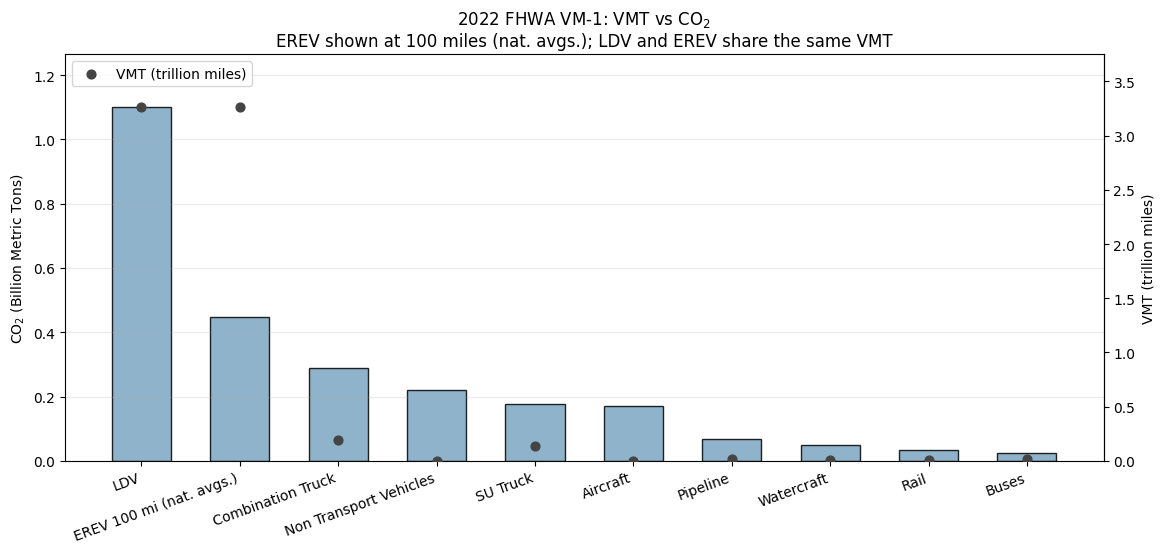

In [5]:
# ============================================================
# FIGURE 1 — 2022 FHWA VM-1: VMT vs CO2 (updated per spec)
# LDV & EREV dots set to Total VMT = 3,262.8 B miles (3.2628 T)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, FormatStrFormatter

plt.close('all')

# ---- FHWA VM-1 2022 VMT (millions of vehicle-miles) ----
FHWA_VMT_MILLION = {
    "All Light-Duty Vehicles": 2_822_664.0,     # original FHWA VM-1 LDV figure
    "Combination Trucks":        195_049.0,
    "Single-Unit Trucks":        136_224.0,
    "Bus":                         18_490.0,
    # placeholders (update if you have official values)
    "Rail":                        10_000.0,
    "All Watercraft":               5_000.0,
    "All Aircraft":                 3_000.0,
    "Non Transport Vehicles":       2_000.0,
    "Pipelines":                   20_000.0,
}

# ---- EXACT order & CO2 (Billion metric tons) from screenshot ----
ordered_labels = [
    "LDV",
    "EREV 100 mi (nat. avgs.)",
    "Combination Truck",
    "Non Transport Vehicles",
    "SU Truck",
    "Aircraft",
    "Pipeline",
    "Watercraft",
    "Rail",
    "Buses",
]

co2_B_tons = np.array([1.100, 0.448, 0.288, 0.219, 0.176, 0.170, 0.069, 0.050, 0.033, 0.025], float)

# Map display labels -> FHWA keys to fetch VMT
label_to_fhwa = {
    "LDV":                          "All Light-Duty Vehicles",
    "EREV 100 mi (nat. avgs.)":     "All Light-Duty Vehicles",  # same VMT as LDV
    "Combination Truck":            "Combination Trucks",
    "Non Transport Vehicles":       "Non Transport Vehicles",
    "SU Truck":                     "Single-Unit Trucks",
    "Aircraft":                     "All Aircraft",
    "Pipeline":                     "Pipelines",
    "Watercraft":                   "All Watercraft",
    "Rail":                         "Rail",
    "Buses":                        "Bus",
}

# Build VMT (trillion miles) array in the same order
vmt_trillion = []
for lab in ordered_labels:
    fhwa_key = label_to_fhwa[lab]
    vmt_trillion.append(FHWA_VMT_MILLION[fhwa_key] / 1_000_000.0)  # M -> T
vmt_trillion = np.asarray(vmt_trillion, float)

# ---- FIX: Force LDV & EREV dots to Total VMT = 3,262.8 B mi (3.2628 T) ----
TOTAL_VMT_B_MILES = 3_262.8
TOTAL_VMT_TRILLION = TOTAL_VMT_B_MILES / 1000.0  # 3.2628
for lab in ["LDV", "EREV 100 mi (nat. avgs.)"]:
    idx = ordered_labels.index(lab)
    vmt_trillion[idx] = TOTAL_VMT_TRILLION

# ---------------- Plot ----------------
x = np.arange(len(ordered_labels))
fig, ax1 = plt.subplots(figsize=(12.5, 6.0))

# Bars: CO2 in Billion metric tons
ax1.bar(x, co2_B_tons, width=0.6, color="#7aa6c2", alpha=0.85, edgecolor="black", linewidth=1.0)
ax1.set_ylabel("CO$_2$ (Billion Metric Tons)")
ax1.set_ylim(0, float(co2_B_tons.max()) * 1.15)
ax1.grid(True, axis="y", alpha=0.25)
ax1.ticklabel_format(axis='y', style='plain', useOffset=False)

# Right axis: VMT (trillion miles) dots (scaled to left)
vmaxT = float(vmt_trillion.max())
tmaxB = float(co2_B_tons.max())
scale = (tmaxB / vmaxT) if vmaxT > 0 else 1.0

vmt_pts = ax1.scatter(x, vmt_trillion * scale, s=40, color="#444", label="VMT (trillion miles)", zorder=3)

secax = ax1.secondary_yaxis('right', functions=(lambda y: y/scale, lambda y: y*scale))
secax.set_ylabel("VMT (trillion miles)")
secax.set_ylim(0, vmaxT * 1.15)                 # shows LDV/EREV ~3.26 T clearly above 3.0
secax.yaxis.set_major_locator(MultipleLocator(0.5))
secax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))

# X labels & title
ax1.set_xticks(x)
ax1.set_xticklabels(ordered_labels, rotation=20, ha="right")
ax1.legend(handles=[vmt_pts], loc="upper left")

ax1.set_title(
    "2022 FHWA VM-1: VMT vs CO$_2$\n"
    "EREV shown at 100 miles (nat. avgs.); LDV and EREV share the same VMT"
)

plt.tight_layout(rect=[0.03, 0.03, 0.97, 0.97])
plt.show()


# FIGURE 2

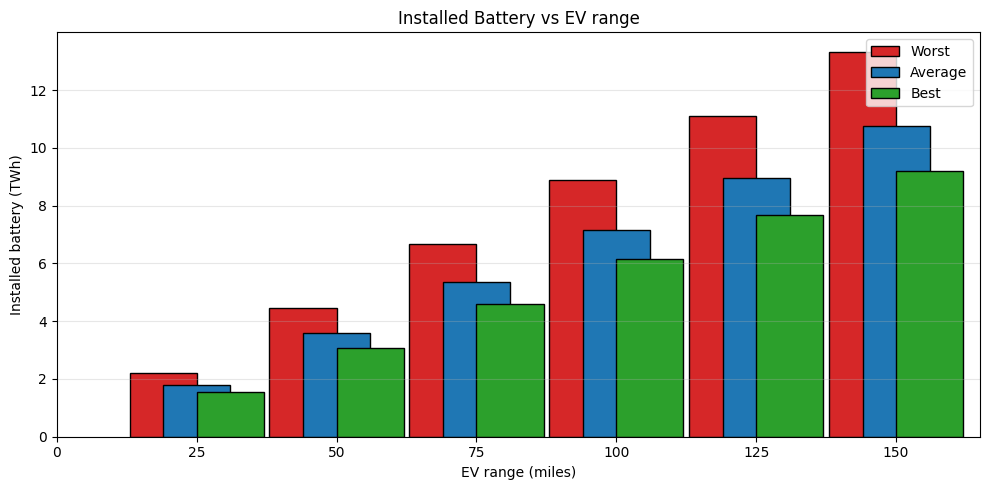

In [6]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------------------------------
# 1. Load Excel and locate the Scenario table
# ----------------------------------------------------
excel_path = "Calculations Check_final.xlsx"   # <- make sure this is correct

# First read to find the row where "Scenario" appears
raw = pd.read_excel(excel_path, sheet_name="Calcs by Scenario", header=None)
scenario_header_row = raw.index[raw.eq("Scenario").any(axis=1)][0]

# Read again using that row as header
scenario_df = pd.read_excel(
    excel_path,
    sheet_name="Calcs by Scenario",
    header=scenario_header_row
)
scenario_df.columns = [str(c).strip() for c in scenario_df.columns]

# ----------------------------------------------------
# 2. Get Installed Battery (TWh) for each scenario
# ----------------------------------------------------
ranges = [25, 50, 75, 100, 125, 150]

def get_installed_battery_twh(scenario_name):
    vals = []
    for r in ranges:
        mask = (
            (scenario_df["Scenario"] == scenario_name) &
            (scenario_df["Vehicle Type"].astype(str)
             .str.contains(f"{r}-mile", case=False))
        )
        row = scenario_df.loc[mask, "Installed Battery (TWh)"]
        vals.append(float(row.iloc[0]))
    return np.array(vals, dtype=float)

worst_vals   = get_installed_battery_twh("Worst")
average_vals = get_installed_battery_twh("Average")
best_vals    = get_installed_battery_twh("Best")

# ----------------------------------------------------
# 3. Plot – same format as your triptych code
# ----------------------------------------------------
def _xticks_25(ax, xmax):
    """Match the helper you use in the main script: 0,25,50,..."""
    ax.set_xticks(np.arange(0, xmax + 1, 25))

plt.close("all")
fig, ax = plt.subplots(figsize=(10, 5))

# Use actual ranges on x-axis (in miles)
x = np.asarray(ranges, float)
bw = 6.0      # half offset in miles
bar_width = 12.0  # bar width in miles

colors = {
    "Worst":   "#d62728",  # red
    "Average": "#1f77b4",  # blue
    "Best":    "#2ca02c"   # green
}

# Grouped bars: Worst left, Average middle, Best right
ax.bar(x - bw, worst_vals,
       width=bar_width, color=colors["Worst"],
       edgecolor="black", linewidth=1.0, label="Worst")

ax.bar(x, average_vals,
       width=bar_width, color=colors["Average"],
       edgecolor="black", linewidth=1.0, label="Average")

ax.bar(x + bw, best_vals,
       width=bar_width, color=colors["Best"],
       edgecolor="black", linewidth=1.0, label="Best")

# Axes / labels / grid to match your other figures
ax.set_xlabel("EV range (miles)")
ax.set_ylabel("Installed battery (TWh)")
ax.set_title("Installed Battery vs EV range")

ax.grid(True, axis="y", alpha=0.3)

# X-axis limits and ticks like in your big script
ax.set_xlim(0, max(ranges) + 15)
_xticks_25(ax, max(ranges))

# Legend in upper-right
ax.legend(loc="upper right")

plt.tight_layout()
plt.show()

# FIGURE 3

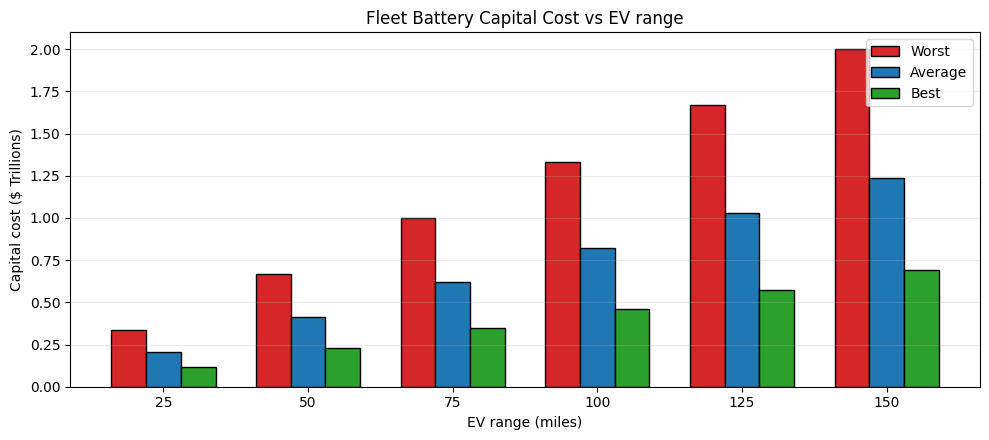

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------------------------------
# 1. Load Excel & get the "Calcs by Scenario" table
# ----------------------------------------------------
excel_path = "Calculations Check_final.xlsx"   # update path if needed

# First read to locate the header row containing "Scenario"
raw = pd.read_excel(excel_path, sheet_name="Calcs by Scenario", header=None)
scenario_header_row = raw.index[raw.eq("Scenario").any(axis=1)][0]

# Read again using that row as header
scenario_df = pd.read_excel(
    excel_path,
    sheet_name="Calcs by Scenario",
    header=scenario_header_row
)
scenario_df.columns = [str(c).strip() for c in scenario_df.columns]

# ----------------------------------------------------
# 2. Extract capital cost $T for each scenario & range
# ----------------------------------------------------
ranges = np.array([25, 50, 75, 100, 125, 150], dtype=float)

def get_capex_trillions(scenario_name):
    """
    Return $T Installed Battery array for a given scenario
    for EV ranges 25, 50, 75, 100, 125, 150 miles.
    """
    vals = []
    for r in ranges:
        mask = (
            (scenario_df["Scenario"] == scenario_name) &
            (scenario_df["Vehicle Type"].astype(str)
             .str.contains(f"{int(r)}-mile", case=False))
        )
        row = scenario_df.loc[mask, "$T Installed Battery"]
        if row.empty:
            raise ValueError(f"No row for {scenario_name}, {r}-mile EV range")
        vals.append(float(row.iloc[0]))
    return np.array(vals, dtype=float)

worst_cap   = get_capex_trillions("Worst")
avg_cap     = get_capex_trillions("Average")
best_cap    = get_capex_trillions("Best")

# ----------------------------------------------------
# 3. Plot – Fleet Battery Capital Cost vs EV range
# ----------------------------------------------------
plt.close("all")
fig, ax = plt.subplots(figsize=(10, 4.5))

x = np.arange(len(ranges))
W = 0.24

colors = {
    "Worst":   "#d62728",  # red
    "Average": "#1f77b4",  # blue
    "Best":    "#2ca02c"   # green
}

# Grouped bars: Worst (left), Average (middle), Best (right)
ax.bar(x - W, worst_cap, width=W,
       color=colors["Worst"], edgecolor="black", label="Worst")
ax.bar(x,      avg_cap,   width=W,
       color=colors["Average"], edgecolor="black", label="Average")
ax.bar(x + W, best_cap,   width=W,
       color=colors["Best"], edgecolor="black", label="Best")

ax.set_xticks(x)
ax.set_xticklabels([str(int(r)) for r in ranges])
ax.set_xlabel("EV range (miles)")
ax.set_ylabel("Capital cost ($ Trillions)")
ax.set_title("Fleet Battery Capital Cost vs EV range")

ax.grid(axis="y", alpha=0.25)
ax.legend(loc="upper right")

plt.tight_layout()
plt.show()


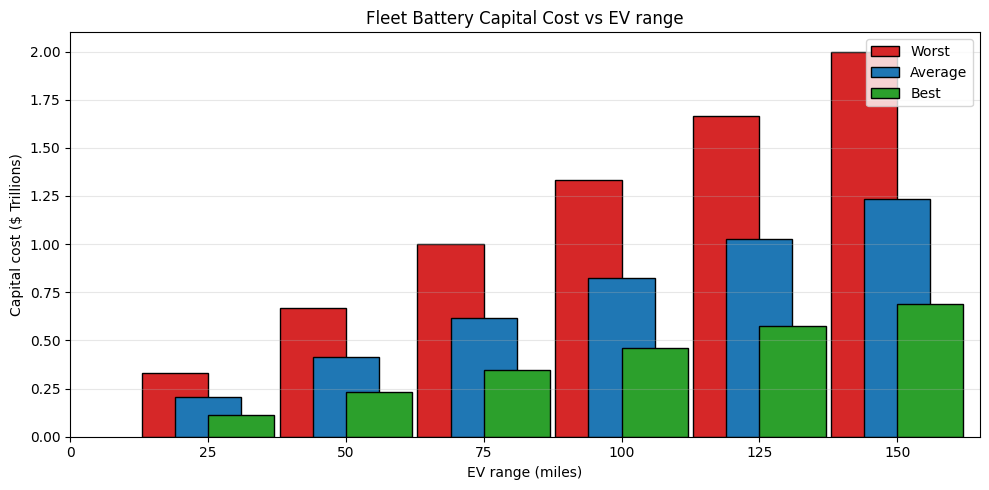

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------------------------------
# 1. Load Excel & get the "Calcs by Scenario" table
# ----------------------------------------------------
excel_path = "Calculations Check_final.xlsx"   # update path if needed

# First read to locate the header row containing "Scenario"
raw = pd.read_excel(excel_path, sheet_name="Calcs by Scenario", header=None)
scenario_header_row = raw.index[raw.eq("Scenario").any(axis=1)][0]

# Read again using that row as header
scenario_df = pd.read_excel(
    excel_path,
    sheet_name="Calcs by Scenario",
    header=scenario_header_row
)
scenario_df.columns = [str(c).strip() for c in scenario_df.columns]

# ----------------------------------------------------
# 2. Extract capital cost $T for each scenario & range
# ----------------------------------------------------
ranges = np.array([25, 50, 75, 100, 125, 150], dtype=float)

def get_capex_trillions(scenario_name):
    """
    Return $T Installed Battery array for a given scenario
    for EV ranges 25, 50, 75, 100, 125, 150 miles.
    """
    vals = []
    for r in ranges:
        mask = (
            (scenario_df["Scenario"] == scenario_name) &
            (scenario_df["Vehicle Type"].astype(str)
             .str.contains(f"{int(r)}-mile", case=False))
        )
        row = scenario_df.loc[mask, "$T Installed Battery"]
        if row.empty:
            raise ValueError(f"No row for {scenario_name}, {r}-mile EV range")
        vals.append(float(row.iloc[0]))
    return np.array(vals, dtype=float)

worst_cap = get_capex_trillions("Worst")
avg_cap   = get_capex_trillions("Average")
best_cap  = get_capex_trillions("Best")

# ----------------------------------------------------
# 3. Plot – Fleet Battery Capital Cost vs EV range
#     (same style as your other triptych figures)
# ----------------------------------------------------
def _xticks_25(ax, xmax):
    ax.set_xticks(np.arange(0, xmax + 1, 25))

plt.close("all")
fig, ax = plt.subplots(figsize=(10, 5))

# Use the actual ranges as x, in miles
x = ranges.astype(float)
bw = 6.0          # bar half-offset (miles)
bar_width = 12.0  # bar width (miles)

colors = {
    "Worst":   "#d62728",  # red
    "Average": "#1f77b4",  # blue
    "Best":    "#2ca02c"   # green
}

# Grouped bars: Worst (left), Average (center), Best (right)
ax.bar(x - bw, worst_cap, width=bar_width,
       color=colors["Worst"], edgecolor="black", linewidth=1.0, label="Worst")
ax.bar(x,       avg_cap,   width=bar_width,
       color=colors["Average"], edgecolor="black", linewidth=1.0, label="Average")
ax.bar(x + bw,  best_cap,  width=bar_width,
       color=colors["Best"], edgecolor="black", linewidth=1.0, label="Best")

ax.set_xlabel("EV range (miles)")
ax.set_ylabel("Capital cost ($ Trillions)")
ax.set_title("Fleet Battery Capital Cost vs EV range")

ax.grid(axis="y", alpha=0.3)

# X-axis limits and ticks to match the reference format
ax.set_xlim(0, ranges.max() + 15)
_xticks_25(ax, ranges.max())

ax.legend(loc="upper right")

plt.tight_layout()
plt.show()

# FIGURE 4

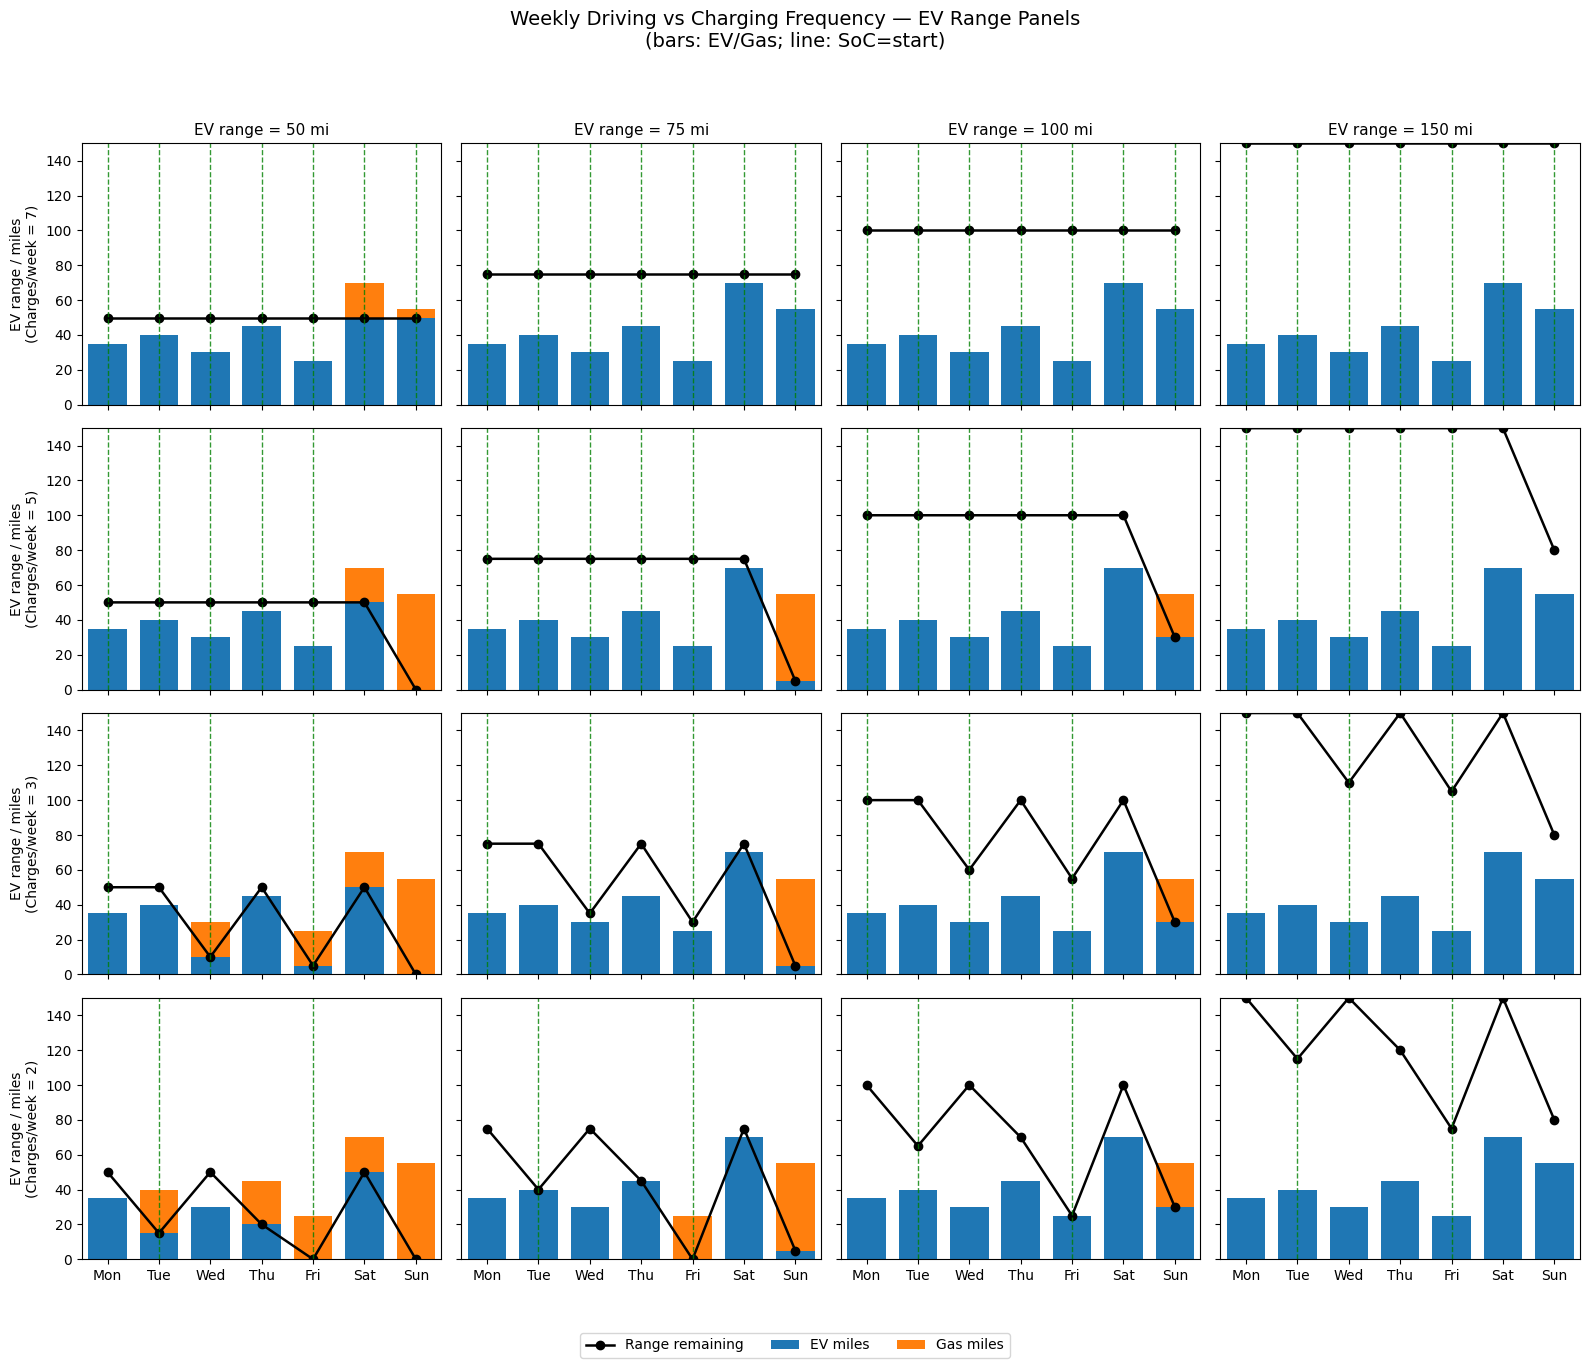

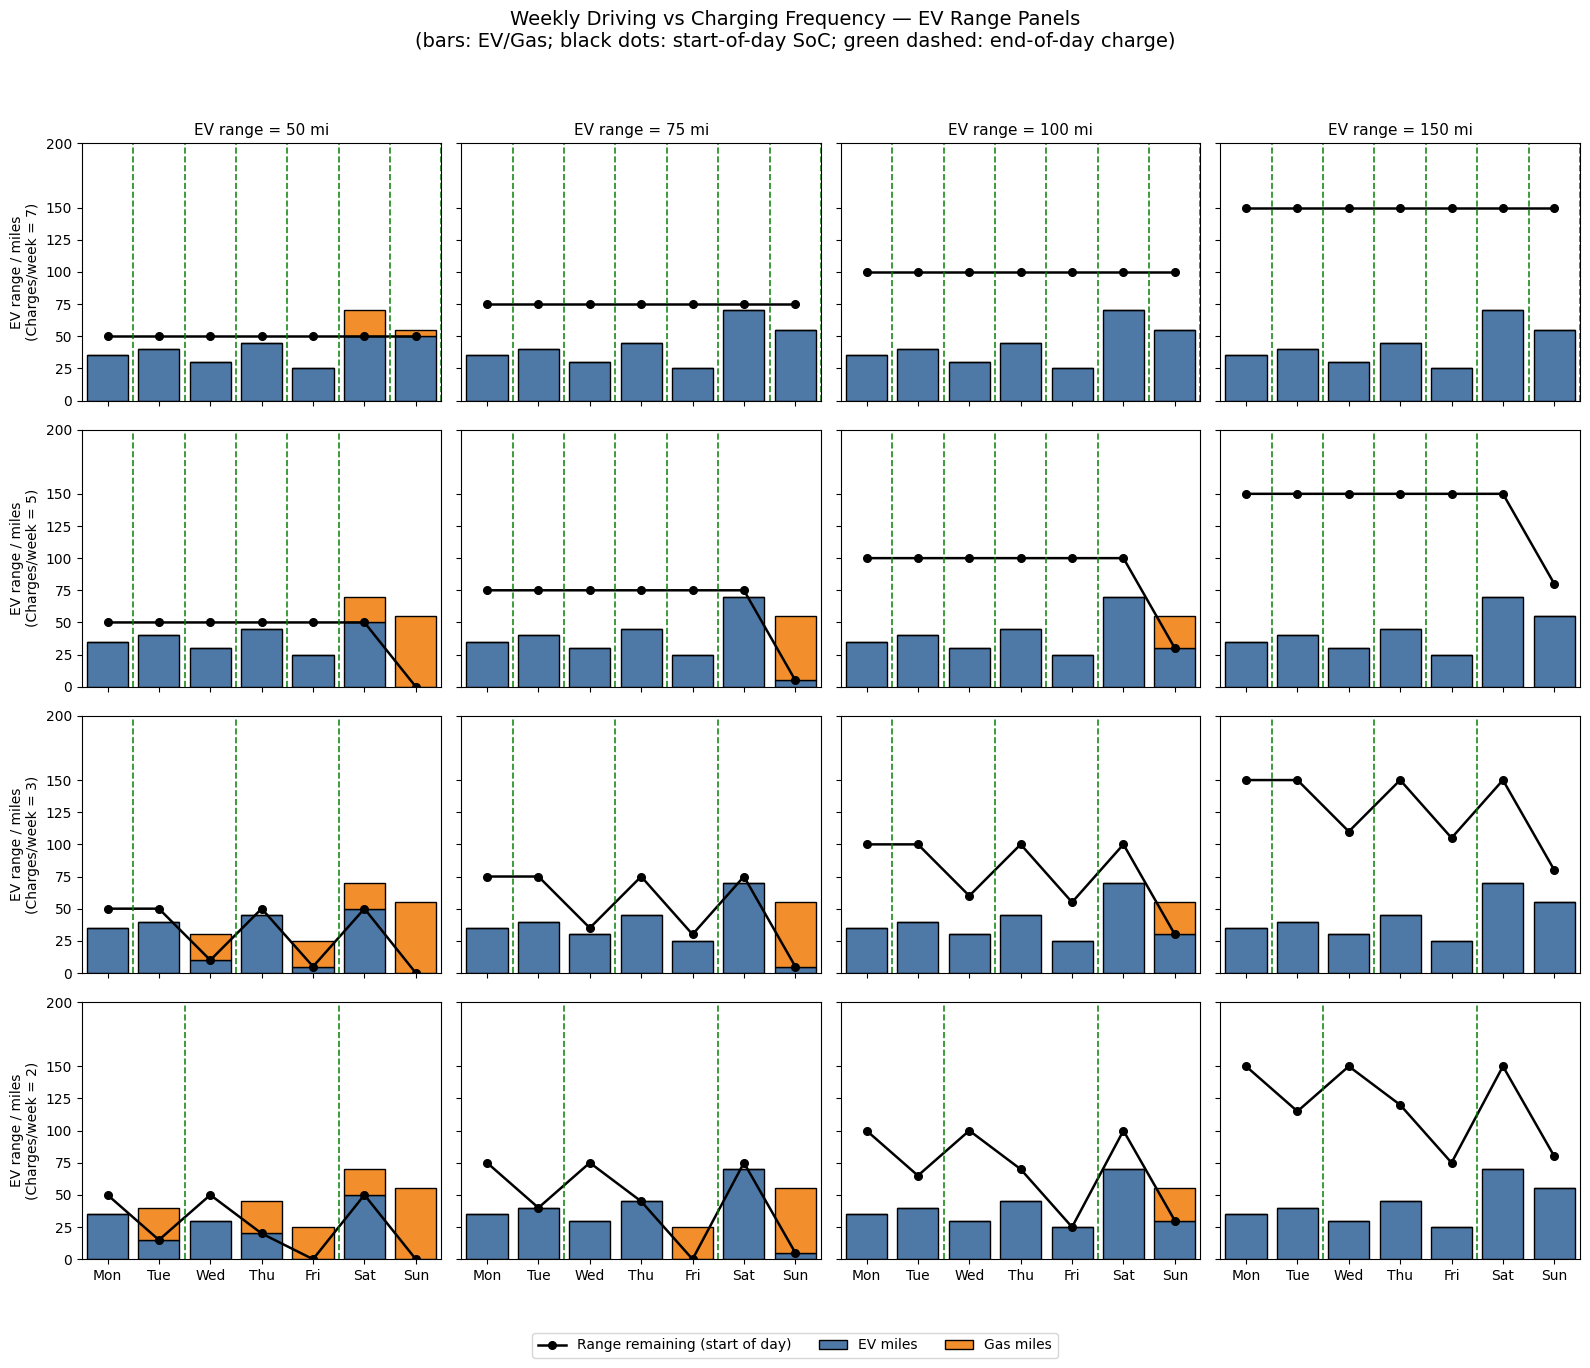

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# --------------------------
# Build weekly driving profile from code-2 output if present; else fallback.
# --------------------------
DOW = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
DOW_WEIGHTS = np.array([0.14,0.14,0.14,0.14,0.14,0.15,0.15], dtype=float)
DOW_WEIGHTS /= DOW_WEIGHTS.sum()

def _lb(lbl: str) -> int:
    if lbl == "0–1": return 0
    import re
    m = re.match(r"(\d+)", lbl)
    return int(m.group(1)) if m else 9999

def _build_daily_miles_from_code2():
    if not all(k in globals() for k in ["WEEKLY_TRIPS_PER_BIN", "bins", "x_opt"]):
        return None
    bins_sorted = sorted(list(WEEKLY_TRIPS_PER_BIN.keys()), key=_lb)
    weekly_trips_per_bin = np.array([float(WEEKLY_TRIPS_PER_BIN[b]) for b in bins_sorted], dtype=float)
    avg_d_map = {b: float(d) for b, d in zip(bins, x_opt)}
    avg_d_mi  = np.array([avg_d_map[b] for b in bins_sorted], dtype=float)
    # household weekly VMT per bin (miles)
    hh_vmt_week_by_bin = weekly_trips_per_bin * avg_d_mi
    # split across days by weights
    day_vmt_by_bin = np.outer(DOW_WEIGHTS, hh_vmt_week_by_bin)
    return day_vmt_by_bin.sum(axis=1)

daily_miles = _build_daily_miles_from_code2()
if daily_miles is None:
    daily_miles = np.array([35, 40, 30, 45, 25, 70, 55], dtype=float)  # Mon..Sun
days = DOW

# --------------------------
# Charge-day patterns (deterministic)
# --------------------------
CHARGE_PATTERN = {
    7: [0,1,2,3,4,5,6],  # daily
    5: [0,1,2,3,4],      # Mon..Fri
    3: [0,2,4],          # Mon/Wed/Fri
    2: [1,4],            # Tue/Fri
}
def schedule_charges_by_day(cpw: int):
    if cpw in CHARGE_PATTERN:
        return CHARGE_PATTERN[cpw][:]
    # Fallback: spread evenly
    idx = np.round(np.linspace(0, 6, num=int(cpw))).astype(int)
    return sorted(np.unique(idx).tolist())

# --------------------------
# Simulation with multiple SoC tracks
# --------------------------
def simulate_week(R, cpw, daily_miles, round_trip=True):
    """
    Returns:
      ev_miles, gas_miles,
      soc_start        : SoC at **start of day** (after any charge)
      soc_after_drive  : SoC at end of driving before charge
      soc_after_charge : SoC at end of day **after** charging (for next day start)
      charge_days      : list of day indices charged
    """
    charge_days = set(schedule_charges_by_day(int(cpw)))

    ev = np.zeros(7)
    gas = np.zeros(7)
    soc_start = np.zeros(7)
    soc_after_drive = np.zeros(7)
    soc_after_charge = np.zeros(7)

    soc = R  # start Monday full
    for d in range(7):
        # if previous day was a charge day, soc is already R
        soc_start[d] = soc

        need = float(daily_miles[d])
        # EV miles limited by SoC and need
        ev_m = min(soc, need) if round_trip else min(soc, need)
        gas_m = max(0.0, need - ev_m)
        ev[d], gas[d] = ev_m, gas_m

        soc = max(0.0, soc - ev_m)
        soc_after_drive[d] = soc

        # Charge at end of day if scheduled
        if d in charge_days:
            soc = R
        soc_after_charge[d] = soc

    return {
        "ev_miles": ev,
        "gas_miles": gas,
        "soc_start": soc_start,
        "soc_after_drive": soc_after_drive,
        "soc_after_charge": soc_after_charge,
        "charge_days": sorted(charge_days),
    }

# --------------------------
# 4×4 grid
# --------------------------
ranges = [50, 75, 100, 150]  # columns
cpw_list = [7, 5, 3, 2]      # rows
LINE_MODE = "start"          # choose: "start" | "after_drive" | "after_charge"

fig, axes = plt.subplots(len(cpw_list), len(ranges),
                         figsize=(16, 14), sharex=True, sharey=True)
fig.suptitle(
    "Weekly Driving vs Charging Frequency — EV Range Panels\n"
    f"(bars: EV/Gas; line: SoC={LINE_MODE.replace('_',' ')})",
    y=0.98, fontsize=14
)

for i, cpw in enumerate(cpw_list):
    for j, R in enumerate(ranges):
        ax = axes[i, j]
        res = simulate_week(R, cpw, daily_miles, round_trip=True)

        ev  = res["ev_miles"]
        gas = res["gas_miles"]

        if LINE_MODE == "after_drive":
            soc_line = res["soc_after_drive"]
        elif LINE_MODE == "after_charge":
            soc_line = res["soc_after_charge"]
        else:  # "start"
            soc_line = res["soc_start"]

        charge_days = res["charge_days"]
        x = np.arange(7)

        # Stacked bars
        ax.bar(x, ev,  label="EV miles",  width=0.75)
        ax.bar(x, gas, bottom=ev, label="Gas miles", width=0.75)

        # SoC line
        ax.plot(x, soc_line, marker="o", linestyle="-", linewidth=1.8, color="black", label="Range remaining")

        # Charge-day markers
        for d in charge_days:
            ax.axvline(d, color="green", linestyle="--", linewidth=1, alpha=0.8)

        ax.set_xticks(x)
        ax.set_xticklabels(days)
        ax.set_xlim(-0.5, 6.5)
        ax.set_ylim(0, 150)  # max EV range on Y axis
        ax.margins(x=0.05)
        if j == 0:
            ax.set_ylabel(f"EV range / miles\n(Charges/week = {cpw})", fontsize=10)
        if i == 0:
            ax.set_title(f"EV range = {R} mi", fontsize=11)

# Shared legend
handles, labels = axes[-1, -1].get_legend_handles_labels()
fig.legend(handles, labels, ncols=3, loc="upper center", bbox_to_anchor=(0.5, 0.04))

plt.tight_layout(rect=[0, 0.06, 1, 0.95])
plt.show()
# fig.savefig("weekly_charging_4x4_panels.png", dpi=300)


import numpy as np
import matplotlib.pyplot as plt

# =========================
# Weekly driving profile
# =========================
DOW = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
DOW_WEIGHTS = np.array([0.14,0.14,0.14,0.14,0.14,0.15,0.15], dtype=float)
DOW_WEIGHTS /= DOW_WEIGHTS.sum()

def _lb(lbl: str) -> int:
    """Numeric sort for bin labels like '0–1','1–3',...,'500+'."""
    if lbl == "0–1": return 0
    import re
    m = re.match(r"(\d+)", lbl)
    return int(m.group(1)) if m else 9999

def _build_daily_miles_from_code2():
    """
    If the upstream notebook has WEEKLY_TRIPS_PER_BIN, bins, and x_opt in globals,
    use them to build the one-household weekly profile by distance-bin,
    then spread across Mon..Sun using DOW_WEIGHTS.
    Returns daily_miles[7] or None if inputs missing.
    """
    if not all(k in globals() for k in ["WEEKLY_TRIPS_PER_BIN", "bins", "x_opt"]):
        return None
    bins_sorted = sorted(list(WEEKLY_TRIPS_PER_BIN.keys()), key=_lb)
    weekly_trips_per_bin = np.array([float(WEEKLY_TRIPS_PER_BIN[b]) for b in bins_sorted], dtype=float)
    avg_d_map = {b: float(d) for b, d in zip(bins, x_opt)}
    avg_d_mi  = np.array([avg_d_map[b] for b in bins_sorted], dtype=float)

    # Weekly household VMT per bin (miles)
    hh_vmt_week_by_bin = weekly_trips_per_bin * avg_d_mi  # (nbins,)
    # Split across days using the weekday/weekend weights
    day_vmt_by_bin = np.outer(DOW_WEIGHTS, hh_vmt_week_by_bin)  # (7, nbins)
    return day_vmt_by_bin.sum(axis=1)  # daily miles Mon..Sun

daily_miles = _build_daily_miles_from_code2()
if daily_miles is None:
    # Fallback daily miles (Mon..Sun) if code-2 inputs aren't present
    daily_miles = np.array([35, 40, 30, 45, 25, 70, 55], dtype=float)

# =========================
# Charge-day patterns
# =========================
# Deterministic patterns (end-of-day charges)
CHARGE_PATTERN = {
    7: [0,1,2,3,4,5,6],  # charge after every day
    5: [0,1,2,3,4],      # Mon..Fri
    3: [0,2,4],          # Mon/Wed/Fri
    2: [1,4],            # Tue/Fri
}

def schedule_charges_by_day(cpw: int):
    """Return sorted list of day indices (0..6) where charging occurs at end of day."""
    cpw = int(cpw)
    if cpw in CHARGE_PATTERN:
        return CHARGE_PATTERN[cpw][:]
    # Fallback: spread evenly if a different cpw is passed
    idx = np.round(np.linspace(0, 6, num=max(cpw, 0))).astype(int)
    return sorted(np.unique(idx).tolist())

# =========================
# Week simulation (SoC bookkeeping)
# =========================
def simulate_week(R, cpw, daily_miles, round_trip=True):
    """
    R:     EV range (miles) at full charge.
    cpw:   charges per week (end-of-day).
    Returns:
      ev_miles[7], gas_miles[7],
      soc_start[7]         : start-of-day SoC (what we plot as black dots)
      soc_after_drive[7]   : SoC after driving (before charge)
      soc_after_charge[7]  : SoC after the end-of-day charge (used as next day's start)
      charge_days          : sorted indices of days charged (0..6)
    """
    charge_days = set(schedule_charges_by_day(cpw))

    ev = np.zeros(7)
    gas = np.zeros(7)
    soc_start = np.zeros(7)
    soc_after_drive = np.zeros(7)
    soc_after_charge = np.zeros(7)

    # Monday begins full
    soc = float(R)

    for d in range(7):
        # Start-of-day SoC (black dot)
        soc_start[d] = soc

        # Drive today's miles
        need = float(daily_miles[d])
        # Simple rule: EV miles limited by SoC & today's need
        ev_m = min(soc, need) if round_trip else min(soc, need)
        gas_m = max(0.0, need - ev_m)
        ev[d], gas[d] = ev_m, gas_m

        # End of driving (before charge)
        soc = max(0.0, soc - ev_m)
        soc_after_drive[d] = soc

        # End-of-day charge (if scheduled)
        if d in charge_days:
            soc = float(R)
        soc_after_charge[d] = soc

    return {
        "ev_miles": ev,
        "gas_miles": gas,
        "soc_start": soc_start,
        "soc_after_drive": soc_after_drive,
        "soc_after_charge": soc_after_charge,
        "charge_days": sorted(charge_days),
    }

# =========================
# Plot: 4×4 grid — ranges × cpw
# =========================
ranges   = [50, 75, 100, 150]   # columns
cpw_list = [7, 5, 3, 2]         # rows
YTICKS   = [0, 25, 50, 75, 100, 125, 150, 200]

fig, axes = plt.subplots(len(cpw_list), len(ranges),
                         figsize=(16, 14), sharex=True, sharey=True)
fig.suptitle(
    "Weekly Driving vs Charging Frequency — EV Range Panels\n"
    "(bars: EV/Gas; black dots: start-of-day SoC; green dashed: end-of-day charge)",
    y=0.98, fontsize=14
)

for i, cpw in enumerate(cpw_list):
    for j, R in enumerate(ranges):
        ax = axes[i, j]
        res = simulate_week(R, cpw, daily_miles, round_trip=True)

        ev  = res["ev_miles"]
        gas = res["gas_miles"]
        soc_start   = res["soc_start"]          # BEGINNING-OF-DAY SoC
        charge_days = res["charge_days"]        # end-of-day charges

        x = np.arange(7)

        # Thicker stacked bars
        ax.bar(x, ev,  width=0.8, color="#4e79a7", edgecolor="black", label="EV miles")
        ax.bar(x, gas, width=0.8, bottom=ev, color="#f28e2b", edgecolor="black", label="Gas miles")

        # Start-of-day SoC (black dots/line)
        ax.plot(x, soc_start, marker="o", markersize=5.5, linestyle="-", linewidth=1.8,
                color="black", label="Range remaining (start of day)")

        # End-of-day charge markers (green dashed at x + 0.5)
        for d in charge_days:
            ax.axvline(d + 0.5, color="green", linestyle="--", linewidth=1.2, alpha=0.9)

        # Axis formatting
        ax.set_xticks(x)
        ax.set_xticklabels(DOW)
        ax.set_xlim(-0.5, 6.5)

        # Fixed Y axis and ticks
        ax.set_ylim(0, 150)
        ax.set_yticks(YTICKS)

        if j == 0:
            ax.set_ylabel(f"EV range / miles\n(Charges/week = {cpw})", fontsize=10)
        if i == 0:
            ax.set_title(f"EV range = {R} mi", fontsize=11)

# Shared legend with unique handles
handles_dict = {}
for ax in axes.flat:
    for h, l in zip(*ax.get_legend_handles_labels()):
        handles_dict[l] = h
fig.legend(list(handles_dict.values()), list(handles_dict.keys()),
           ncols=3, loc="upper center", bbox_to_anchor=(0.5, 0.04))

plt.tight_layout(rect=[0, 0.06, 1, 0.95])
plt.show()
# plt.savefig("weekly_charging_4x4_panels.png", dpi=300, bbox_inches="tight")

# FIGURE 5

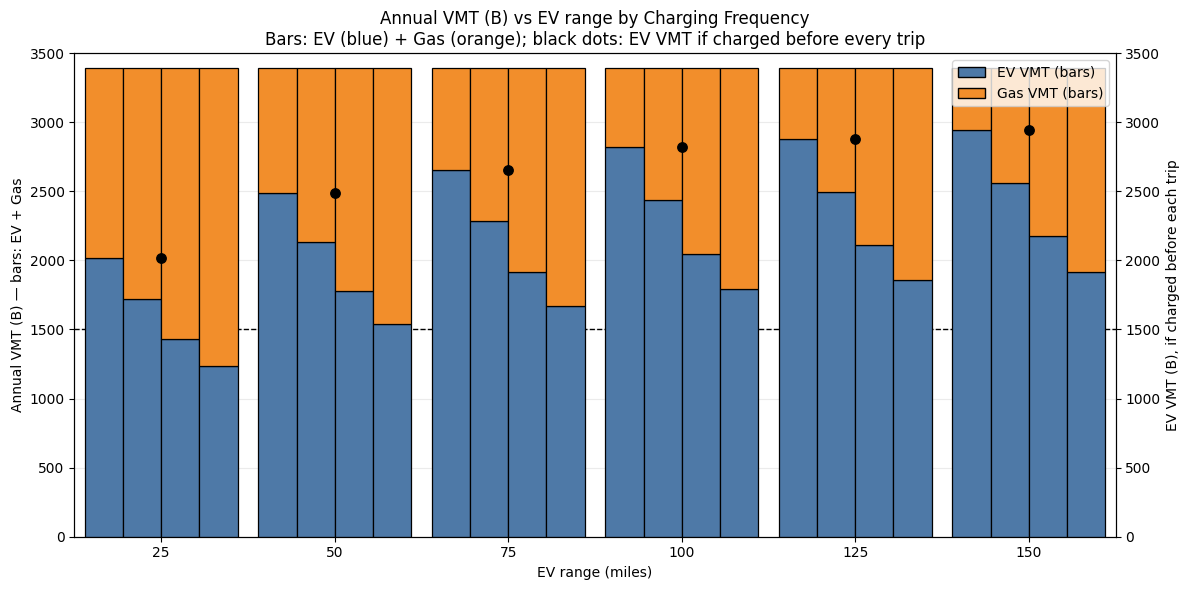

In [10]:
# === Figure 5 — Annual VMT (B) vs EV range by Charging Frequency (exact layout) ===
# Data source: "Calcs by Charge" in Calculations Check_final.xlsx

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

EXCEL_PATH = "/content/Calculations Check_final.xlsx"
SHEET_CPW  = "Calcs by Charge"

RANGES     = [25, 50, 75, 100, 125, 150]
CPW_ORDER  = [7, 5, 3, 2]                       # left → right inside each bar
EV_COLOR   = "#4e79a7"                          # blue
GAS_COLOR  = "#f28e2b"                          # orange

# ---------------- helpers ----------------
def _normalize_headers_inplace(df: pd.DataFrame) -> None:
    df.columns = (df.columns.astype(str)
                  .str.replace("\n", " ", regex=False)
                  .str.strip()
                  .str.replace(r"\s+", " ", regex=True))

def _find_header_row(path: str, sheet: str, max_scan: int = 200) -> int:
    raw = pd.read_excel(path, sheet_name=sheet, header=None, nrows=max_scan)
    keys = [
        ("vehicle", "type"),
        ("charge", "freq"),
        ("gas", "vmt"),
        ("electric", "vmt"),
        ("vmt", "(b)")
    ]
    for i in range(min(max_scan, len(raw))):
        row = " ".join(map(str, raw.iloc[i].fillna("").tolist())).lower()
        if any(all(k in row for k in ks) for ks in keys):
            return i
    return 0

def pick_col(df, *tokens):
    toks = [t.lower() for t in tokens]
    for c in df.columns:
        s = str(c).lower()
        if all(t in s for t in toks):
            return c
    # fallback for generic "VMT" without (B)
    if tokens == ("vmt", "(b)"):
        for c in df.columns:
            if "vmt" in str(c).lower():
                return c
    raise KeyError(f"Missing column with tokens {tokens}; cols={list(df.columns)}")

def parse_range(vtype: str):
    s = str(vtype)
    m = (re.search(r"\((\d+)\s*-\s*mile", s, flags=re.I)
         or re.search(r"(\d+)\s*-\s*mile", s, flags=re.I)
         or re.search(r"(\d+)\s*mi\b", s, flags=re.I))
    if not m:
        return np.nan
    for g in m.groups():
        if g:
            return int(g)
    return np.nan

def read_calcs_by_charge(path: str) -> pd.DataFrame:
    hdr = _find_header_row(path, SHEET_CPW)
    df = pd.read_excel(path, sheet_name=SHEET_CPW, header=hdr)
    _normalize_headers_inplace(df)

    col_charge = (pick_col(df, "charge", "freq")
                  if any("charge" in str(c).lower() for c in df.columns)
                  else pick_col(df, "charges", "week"))
    col_vtype  = pick_col(df, "vehicle", "type")
    col_gasB   = pick_col(df, "gas", "vmt", "(b)")
    col_evB    = pick_col(df, "electric", "vmt", "(b)")
    col_totB   = pick_col(df, "vmt", "(b)")

    s_charge = df[col_charge].astype(str).str.lower()
    is_best  = s_charge.str.contains("before every trip", na=False)

    def parse_cpw(x):
        sx = str(x).lower()
        if "before every trip" in sx:
            return None
        m = re.search(r"\d+", sx)
        return int(m.group(0)) if m else None

    out = pd.DataFrame({
        "cpw":         df[col_charge].map(parse_cpw),
        "is_best":     is_best,
        "vehicle_type": df[col_vtype].astype(str),
        "gas_B":       pd.to_numeric(df[col_gasB], errors="coerce"),
        "ev_B":        pd.to_numeric(df[col_evB],  errors="coerce"),
        "total_B":     pd.to_numeric(df[col_totB], errors="coerce"),
    })

    m_ldv = (
        out["vehicle_type"].str.contains("LDV", case=False, na=False)
        & out["vehicle_type"].str.contains("EV range", case=False, na=False)
    )
    out = out[m_ldv].copy()

    out["range"] = out["vehicle_type"].map(parse_range).astype(float)
    out = out.dropna(subset=["range"]).copy()
    out["range"] = out["range"].astype(int)
    return out

# ---------------- load & shape ----------------
df = read_calcs_by_charge(EXCEL_PATH)

ev_mat  = np.full((len(CPW_ORDER), len(RANGES)), np.nan)
gas_mat = np.full_like(ev_mat, np.nan)

for i, cpw in enumerate(CPW_ORDER):
    for j, r in enumerate(RANGES):
        row = df[(df["cpw"] == cpw) & (df["range"] == r)]
        if len(row):
            ev_mat[i, j]  = float(row["ev_B"].iloc[0])
            gas_mat[i, j] = float(row["gas_B"].iloc[0])

# Best-case EV VMT dots
best_lookup = (
    df[df["is_best"]]
      .sort_values(["range", "ev_B"], ascending=[True, False])
      .drop_duplicates(subset=["range"])
      .set_index("range")["ev_B"]
)
best_vals = np.array([best_lookup.get(r, np.nan) for r in RANGES], float)

# Fallback if the sheet has no explicit “before every trip” rows
if np.isnan(best_vals).all():
    max_by_range = (df.groupby("range", as_index=True)["ev_B"].max())
    best_vals = np.array([max_by_range.get(r, np.nan) for r in RANGES], float)

# ---------------- plot (exact style) ----------------
plt.close("all")
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(RANGES))

# Four abutting sub-bars inside one bar per range (no gaps).
sub_w = 0.22                               # width of each internal partition
offsets = [-1.5*sub_w, -0.5*sub_w, 0.5*sub_w, 1.5*sub_w]  # centers so edges touch

for k, cpw in enumerate(CPW_ORDER):
    pos = x + offsets[k]
    ax.bar(pos, ev_mat[k],  width=sub_w, color=EV_COLOR,
           edgecolor="black", linewidth=0.9, zorder=3)
    ax.bar(pos, gas_mat[k], width=sub_w, bottom=ev_mat[k], color=GAS_COLOR,
           edgecolor="black", linewidth=0.9, zorder=3)

# Secondary axis dots
ax2 = ax.twinx()
ax2.scatter(x, best_vals, s=46, color="black", zorder=5)
ax2.set_ylim(0, 3500)
ax2.set_ylabel("EV VMT (B), if charged before each trip", color="black")
ax2.tick_params(axis="y", colors="black")

# Primary axis formatting
ax.set_xticks(x)
ax.set_xticklabels([str(r) for r in RANGES])
ax.set_xlim(-0.5, len(RANGES)-0.5)
ax.set_ylim(0, 3500)                              # match right axis (3.5T)
ax.axhline(1500, ls="--", lw=1.0, color="k")      # reference line
ax.set_ylabel("Annual VMT (B) — bars: EV + Gas")
ax.set_xlabel("EV range (miles)")
ax.grid(True, axis="y", alpha=0.25)

ax.set_title(
    "Annual VMT (B) vs EV range by Charging Frequency\n"
    "Bars: EV (blue) + Gas (orange); black dots: EV VMT if charged before every trip"
)

# Legend
handles = [
    Patch(facecolor=EV_COLOR,  edgecolor="black", label="EV VMT (bars)"),
    Patch(facecolor=GAS_COLOR, edgecolor="black", label="Gas VMT (bars)")
]
ax.legend(handles=handles, loc="upper right", frameon=True)

plt.tight_layout()
plt.show()


## Updated FIGURE 5

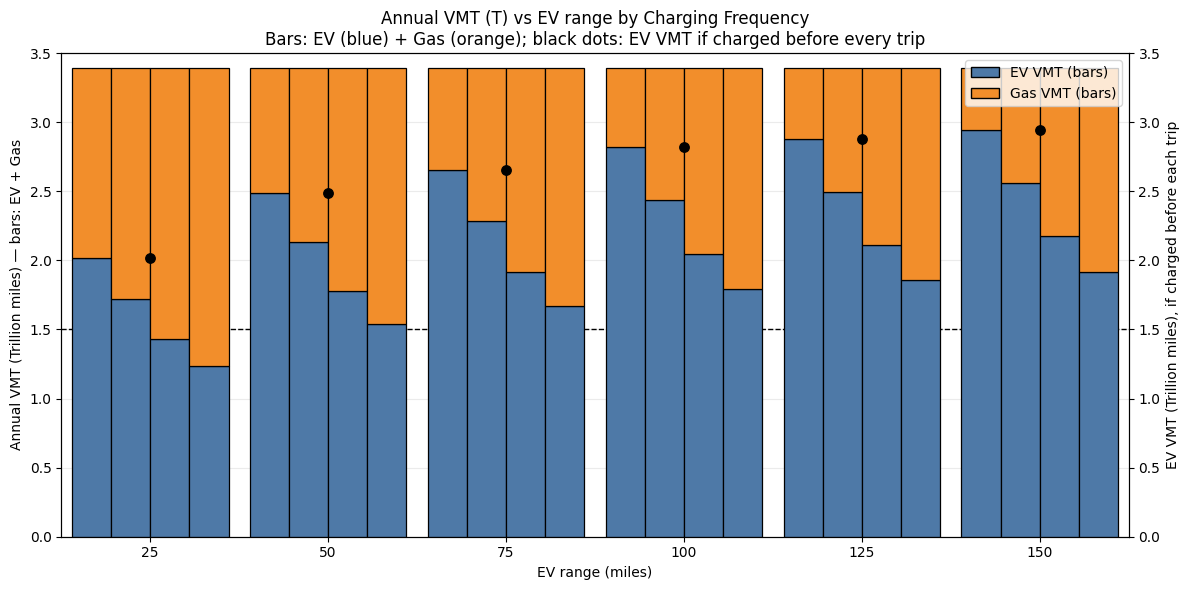

In [11]:
# ===== FIGURE 5 (fixed legend) =====
import re, numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib.patches import Patch

EXCEL_PATH = "Calculations Check_final.xlsx"
SHEET_CPW  = "Calcs by Charge"

RANGES    = [25, 50, 75, 100, 125, 150]
CPW_ORDER = [7, 5, 3, 2]
EV_COLOR  = "#4e79a7"; GAS_COLOR = "#f28e2b"

def _norm_cols(df): df.columns=(df.columns.astype(str).str.replace("\n"," ",regex=False).str.strip().str.replace(r"\s+"," ",regex=True))
def _find_header(path, sheet, n=250):
    raw=pd.read_excel(path, sheet_name=sheet, header=None, nrows=n)
    keys=[("vehicle","type"),("charge","freq"),("gas","vmt"),("electric","vmt")]
    for i in range(min(n,len(raw))):
        s=" ".join(map(str,raw.iloc[i].fillna("").tolist())).lower()
        if any(all(k in s for k in ks) for ks in keys): return i
    return 0
def _pick(df,*tok):
    T=[t.lower() for t in tok]
    for c in df.columns:
        s=str(c).lower()
        if all(t in s for t in T): return c
    raise KeyError(f"Missing {tok}; cols={list(df.columns)}")
def _parse_range(s):
    m=(re.search(r"\((\d+)\s*-\s*mile",str(s),re.I) or re.search(r"(\d+)\s*-\s*mile",str(s),re.I) or re.search(r"(\d+)\s*mi\b",str(s),re.I))
    return int(m.group(1)) if m else np.nan

# --- load cpw sheet robustly
hdr=_find_header(EXCEL_PATH,SHEET_CPW)
df=pd.read_excel(EXCEL_PATH, sheet_name=SHEET_CPW, header=hdr); _norm_cols(df)
c_charge=_pick(df,"charge","freq") if any("charge" in str(c).lower() for c in df.columns) else _pick(df,"charges","week")
c_vtype=_pick(df,"vehicle","type")
c_evB=_pick(df,"electric","vmt")
c_gasB=_pick(df,"gas","vmt")

s_charge=df[c_charge].astype(str).str.lower()
is_best=s_charge.str.contains("before every trip",na=False)

def _cpw(x):
    s=str(x).lower()
    if "before every trip" in s: return None
    m=re.search(r"\d+",s); return int(m.group(0)) if m else None

sub=pd.DataFrame({
    "cpw": df[c_charge].map(_cpw),
    "is_best": is_best,
    "vtype": df[c_vtype].astype(str),
    "EV_B": pd.to_numeric(df[c_evB], errors="coerce"),
    "GAS_B": pd.to_numeric(df[c_gasB], errors="coerce"),
})
m_ldv=sub["vtype"].str.contains("LDV",case=False,na=False) & sub["vtype"].str.contains("EV range",case=False,na=False)
sub=sub[m_ldv].copy()
sub["range"]=sub["vtype"].map(_parse_range).astype(float)
sub=sub.dropna(subset=["range"]).copy()
sub["range"]=sub["range"].astype(int)

# matrices in TRILLIONS (B/1000)
to_T=lambda b: b/1000.0
ev_T=np.full((len(CPW_ORDER),len(RANGES)),np.nan)
gas_T=np.full_like(ev_T,np.nan)
for i,cpw in enumerate(CPW_ORDER):
    for j,R in enumerate(RANGES):
        row=sub[(sub["cpw"]==cpw)&(sub["range"]==R)]
        if len(row):
            ev_T[i,j]=to_T(float(row["EV_B"].iloc[0]))
            gas_T[i,j]=to_T(float(row["GAS_B"].iloc[0]))

best = (sub[sub["is_best"]]
        .sort_values(["range","EV_B"],ascending=[True,False])
        .drop_duplicates(subset=["range"])
        .set_index("range")["EV_B"])
best_T=np.array([to_T(best.get(R,np.nan)) for R in RANGES],float)
if np.isnan(best_T).all():  # fallback if no explicit row
    mx=sub.groupby("range")["EV_B"].max()
    best_T=np.array([to_T(mx.get(R,np.nan)) for R in RANGES],float)

# --- plot
plt.close("all"); fig,ax=plt.subplots(figsize=(12,6))
x=np.arange(len(RANGES))
w=0.22; offs=[-1.5*w,-0.5*w,0.5*w,1.5*w]
for k,cpw in enumerate(CPW_ORDER):
    pos=x+offs[k]
    ax.bar(pos, ev_T[k],  width=w, color=EV_COLOR, edgecolor="black", lw=0.9, zorder=3)
    ax.bar(pos, gas_T[k], width=w, bottom=ev_T[k], color=GAS_COLOR, edgecolor="black", lw=0.9, zorder=3)

ax2=ax.twinx()
ax2.scatter(x, best_T, s=46, color="black", zorder=5)
ax2.set_ylim(0,3.5); ax2.set_ylabel("EV VMT (Trillion miles), if charged before each trip", color="black")
ax2.tick_params(axis="y", colors="black")

ax.set_xticks(x); ax.set_xticklabels([str(r) for r in RANGES])
ax.set_xlim(-0.5,len(RANGES)-0.5)
ax.set_ylim(0,3.5); ax.axhline(1.5, ls="--", lw=1.0, color="k")
ax.set_ylabel("Annual VMT (Trillion miles) — bars: EV + Gas")
ax.set_xlabel("EV range (miles)")
ax.grid(True,axis="y",alpha=0.25)
ax.set_title("Annual VMT (T) vs EV range by Charging Frequency\nBars: EV (blue) + Gas (orange); black dots: EV VMT if charged before every trip")

# FIX: Pass handles= and labels= explicitly
handles=[Patch(facecolor=EV_COLOR, edgecolor="black"),
         Patch(facecolor=GAS_COLOR, edgecolor="black")]
labels=["EV VMT (bars)","Gas VMT (bars)"]
ax.legend(handles=handles, labels=labels, loc="upper right", frameon=True)

plt.tight_layout(); plt.show()


# FIGURE 6

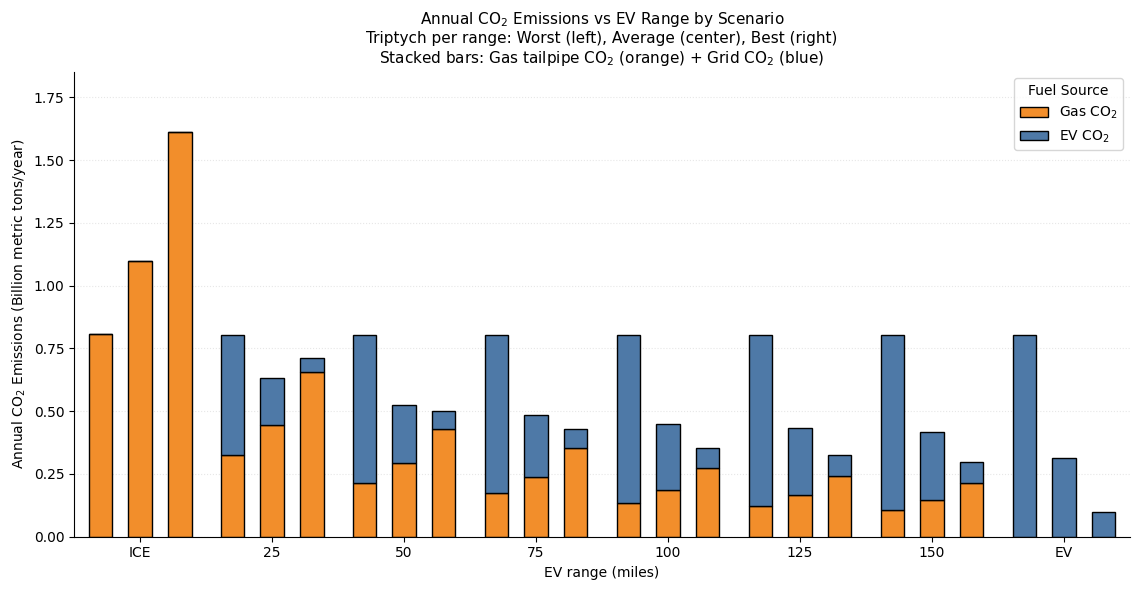

In [12]:
# Annual CO2 emissions vs EV range by Scenario (Worst/Average/Best)
# Stacked bars: Gas tailpipe CO2 (orange) + Grid CO2 for EV miles (blue)

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# =========================
# 0) Inputs
# =========================
FILE_PATH = "Calculations Check_final - Copy.xlsx"   # << use the *Copy* workbook
PREFERRED_SHEET_NAME = "calculations_check_final-copy"  # << prefer this sheet if present

# Desired order on the x-axis (only items present in data will be shown)
DESIRED_RANGE_ORDER = ["ICE", "25", "50", "75", "100", "125", "150", "EV"]
TRIPTYCH = ["Worst", "Average", "Best"]      # scenario order
EV_COLOR  = "#4e79a7"                         # blue
GAS_COLOR = "#f28e2b"                         # orange

# =========================
# 1) Utilities
# =========================
def normalize_headers_inplace(df: pd.DataFrame) -> None:
    df.columns = (
        df.columns.astype(str)
        .str.replace("\n", " ", regex=False)
        .str.strip()
        .str.replace(r"\s+", " ", regex=True)
        .str.replace("co₂", "co2", case=False)
    )

def find_header_row(path: str, sheet: str, max_scan: int = 250) -> int:
    raw = pd.read_excel(path, sheet_name=sheet, header=None, nrows=max_scan)
    token_sets = [
        ("scenario",),
        ("vehicle", "type"),
        ("co2",),
        ("gas",),
        ("ev",)   # or "electric"/"grid"
    ]
    for i in range(min(max_scan, len(raw))):
        row = " ".join(map(str, raw.iloc[i].fillna("").tolist())).lower()
        score = sum(all(t in row for t in ts) for ts in token_sets)
        if score >= 2:
            return i
    return 0

def pick_col(df: pd.DataFrame, *need_tokens, allow_any=False):
    toks = [t.lower() for t in need_tokens]
    for c in df.columns:
        s = str(c).lower()
        ok = all(t in s for t in toks) if not allow_any else any(t in s for t in toks)
        if ok:
            return c
    raise KeyError(f"Need column with tokens {need_tokens}. Available: {list(df.columns)}")

def try_pick(df: pd.DataFrame, *need_tokens, allow_any=False):
    try:
        return pick_col(df, *need_tokens, allow_any=allow_any)
    except KeyError:
        return None

def extract_range_bucket(vtype: str) -> str:
    v = str(vtype).strip()
    up = v.upper()
    if up == "ICE":
        return "ICE"
    if up == "EV":
        return "EV"
    m = re.search(r"(\d+)\s*(?:-| )?\s*mile", v, flags=re.I)
    if m:
        return m.group(1)
    return v

def norm_scenario_name(s: str) -> str:
    s = str(s).strip().title()
    if s.startswith("Wor"):  return "Worst"
    if s.startswith("Aver") or s.startswith("Mid"): return "Average"
    if s.startswith("Bes"):  return "Best"
    return s

def looks_like_emissions(df: pd.DataFrame) -> bool:
    cols = [c.lower() for c in df.columns]
    has_scn = any("scenario" in c for c in cols)
    has_vty = any(("vehicle" in c and "type" in c) for c in cols)
    has_gas = any(("gas" in c and "co2" in c) or ("tailpipe" in c and "co2" in c) for c in cols)
    has_ev  = any(("ev" in c and "co2" in c) or ("electric" in c and "co2" in c) or ("grid" in c and "co2" in c) for c in cols)
    return has_scn and has_vty and has_gas and has_ev

# =========================
# 2) Load preferred sheet (if present) else autodetect
# =========================
xls = pd.ExcelFile(FILE_PATH)
target_sheet = None

# prefer the named sheet if present (case-insensitive match)
name_map = {name.lower(): name for name in xls.sheet_names}
if PREFERRED_SHEET_NAME and PREFERRED_SHEET_NAME.lower() in name_map:
    cand = name_map[PREFERRED_SHEET_NAME.lower()]
    hdr = find_header_row(FILE_PATH, cand)
    df_try = pd.read_excel(FILE_PATH, sheet_name=cand, header=hdr)
    normalize_headers_inplace(df_try)
    if looks_like_emissions(df_try):
        target_sheet = cand
        df_raw = df_try

# otherwise, autodetect a suitable sheet
if target_sheet is None:
    for name in xls.sheet_names:
        hdr = find_header_row(FILE_PATH, name)
        df_try = pd.read_excel(FILE_PATH, sheet_name=name, header=hdr)
        normalize_headers_inplace(df_try)
        if looks_like_emissions(df_try):
            target_sheet = name
            df_raw = df_try
            break

if target_sheet is None:
    raise RuntimeError("Could not find a sheet with Scenario + Vehicle Type + Gas CO2 + EV/Grid CO2.")

# =========================
# 3) Select and standardize columns
# =========================
c_scn = pick_col(df_raw, "scenario")
c_vty = pick_col(df_raw, "vehicle", "type")

# Gas CO2 may appear as "Gas CO2 (Mt)" or "Tailpipe CO2 (Mt)"
c_gas = try_pick(df_raw, "gas", "co2") or try_pick(df_raw, "tailpipe", "co2")
# EV/grid CO2 may appear as "EV CO2 (Mt)", "Electric CO2 (Mt)", or "Grid CO2 (Mt)"
c_ev  = try_pick(df_raw, "ev", "co2") or try_pick(df_raw, "electric", "co2") or try_pick(df_raw, "grid", "co2")

if c_gas is None or c_ev is None:
    raise KeyError(f"Could not find Gas/EV CO2 columns in sheet {target_sheet}. Columns={list(df_raw.columns)}")

df = df_raw[[c_scn, c_vty, c_gas, c_ev]].copy()
df.columns = ["Scenario", "VehicleType", "Gas_CO2", "EV_CO2"]
df = df.dropna(subset=["VehicleType"]).reset_index(drop=True)

# =========================
# 4) Parse range + clean scenario + units
# =========================
df["RangeBucket"]   = df["VehicleType"].apply(extract_range_bucket)
df["ScenarioClean"] = df["Scenario"].apply(norm_scenario_name)
df = df[df["ScenarioClean"].isin(TRIPTYCH)].copy()

df["Gas_CO2"] = pd.to_numeric(df["Gas_CO2"], errors="coerce")
df["EV_CO2"]  = pd.to_numeric(df["EV_CO2"],  errors="coerce")

# Convert Mt → Billion tons (Bt) if appropriate
max_guess = np.nanmax(df[["Gas_CO2", "EV_CO2"]].to_numpy())
if np.isfinite(max_guess) and max_guess > 10:   # likely Mt
    df["Gas_CO2_Bt"] = df["Gas_CO2"] / 1000.0
    df["EV_CO2_Bt"]  = df["EV_CO2"]  / 1000.0
else:
    df["Gas_CO2_Bt"] = df["Gas_CO2"]
    df["EV_CO2_Bt"]  = df["EV_CO2"]

# =========================
# 5) Aggregate (sum across any duplicate rows)
# =========================
grouped = (
    df.groupby(["RangeBucket", "ScenarioClean"], as_index=False)[["Gas_CO2_Bt", "EV_CO2_Bt"]]
      .sum()
)

# =========================
# 6) Build x-axis order and bar offsets
# =========================
present_ranges = grouped["RangeBucket"].unique().tolist()
range_axis = [rb for rb in DESIRED_RANGE_ORDER if rb in present_ranges]
x_vals = np.arange(len(range_axis), dtype=float)

offset_span = 0.60
halfspan = offset_span / 2.0
bar_w = 0.18
offsets = {"Worst": -halfspan, "Average": 0.0, "Best": +halfspan}

def get_pair(rb, scen):
    m = grouped[(grouped["RangeBucket"] == rb) & (grouped["ScenarioClean"] == scen)]
    if len(m) == 0:
        return (0.0, 0.0)
    return float(m["Gas_CO2_Bt"].iloc[0]), float(m["EV_CO2_Bt"].iloc[0])

# =========================
# 7) Plot (stacked bars per scenario at each range)
# =========================
plt.close('all')
fig, ax = plt.subplots(figsize=(11.5, 6))

for scen in TRIPTYCH:
    xs, gas_arr, ev_arr = [], [], []
    for i, rb in enumerate(range_axis):
        g, e = get_pair(rb, scen)
        xs.append(x_vals[i] + offsets[scen]); gas_arr.append(g); ev_arr.append(e)

    xs = np.asarray(xs); gas_arr = np.asarray(gas_arr); ev_arr = np.asarray(ev_arr)
    ax.bar(xs, gas_arr, width=bar_w, color=GAS_COLOR, edgecolor="black", linewidth=1.0)
    ax.bar(xs, ev_arr,  width=bar_w, bottom=gas_arr, color=EV_COLOR, edgecolor="black", linewidth=1.0)

ax.set_xticks(x_vals)
ax.set_xticklabels(range_axis)
ax.set_xlabel("EV range (miles)")
ax.set_ylabel("Annual CO$_2$ Emissions (Billion metric tons/year)")

ax.set_title(
    "Annual CO$_2$ Emissions vs EV Range by Scenario\n"
    "Triptych per range: Worst (left), Average (center), Best (right)\n"
    "Stacked bars: Gas tailpipe CO$_2$ (orange) + Grid CO$_2$ (blue)",
    fontsize=11
)

ax.set_axisbelow(True)
ax.grid(axis="y", alpha=0.3, linestyle=":", linewidth=0.8)
ax.set_xlim(-0.5, len(range_axis) - 0.5)
ax.ticklabel_format(axis='y', style='plain')

ymax = (grouped["Gas_CO2_Bt"] + grouped["EV_CO2_Bt"]).max()
ax.set_ylim(0, (1.15 * ymax) if np.isfinite(ymax) else 1.0)

for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)

gas_patch = Patch(facecolor=GAS_COLOR, edgecolor="black", label="Gas CO$_2$")
ev_patch  = Patch(facecolor=EV_COLOR,  edgecolor="black", label="EV CO$_2$")
ax.legend([gas_patch, ev_patch], ["Gas CO$_2$", "EV CO$_2$"],
          title="Fuel Source", loc="upper right", frameon=True)

plt.tight_layout()
plt.show()


## Updated FIGURE 6

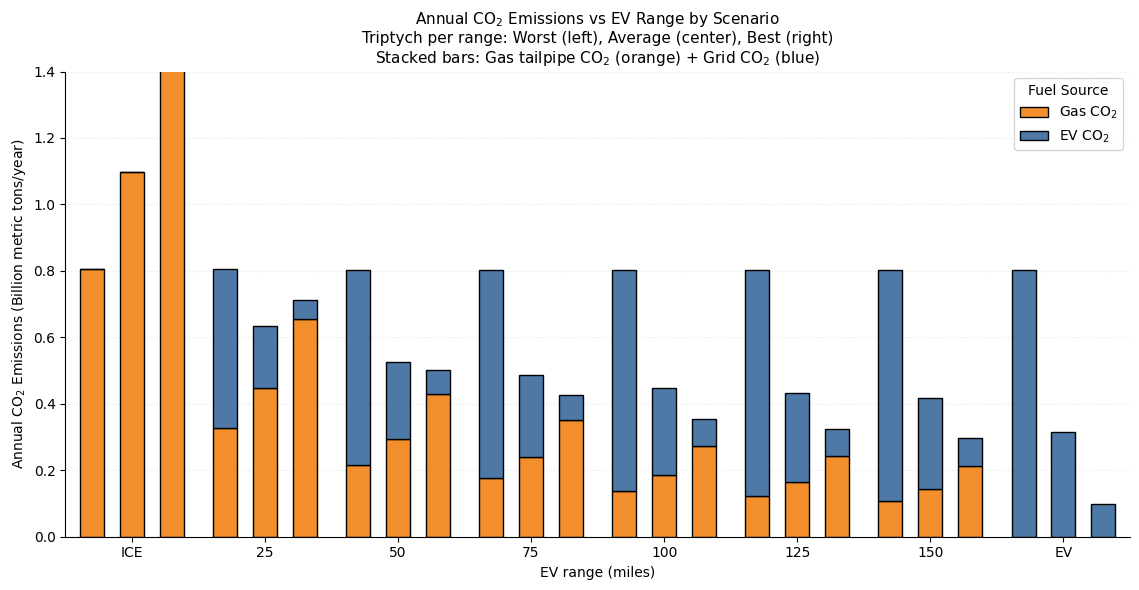

In [13]:
# ---------------- Figure 6 (y-axis fixed to 0..1.4 Mt CO2) ----------------
# Annual CO2 emissions vs EV range by Scenario (Worst/Average/Best)
# Stacked bars: Gas tailpipe CO2 (orange) + Grid CO2 for EV miles (blue)

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# =========================
# 0) Inputs
# =========================
FILE_PATH = "Calculations Check_final - Copy.xlsx"   # << use the *Copy* workbook
PREFERRED_SHEET_NAME = "calculations_check_final-copy"  # << prefer this sheet if present

# Desired order on the x-axis (only items present in data will be shown)
DESIRED_RANGE_ORDER = ["ICE", "25", "50", "75", "100", "125", "150", "EV"]
TRIPTYCH = ["Worst", "Average", "Best"]      # scenario order
EV_COLOR  = "#4e79a7"                         # blue
GAS_COLOR = "#f28e2b"                         # orange

# =========================
# 1) Utilities
# =========================
def normalize_headers_inplace(df: pd.DataFrame) -> None:
    df.columns = (
        df.columns.astype(str)
        .str.replace("\n", " ", regex=False)
        .str.strip()
        .str.replace(r"\s+", " ", regex=True)
        .str.replace("co₂", "co2", case=False)
    )

def find_header_row(path: str, sheet: str, max_scan: int = 250) -> int:
    raw = pd.read_excel(path, sheet_name=sheet, header=None, nrows=max_scan)
    token_sets = [
        ("scenario",),
        ("vehicle", "type"),
        ("co2",),
        ("gas",),
        ("ev",)   # or "electric"/"grid"
    ]
    for i in range(min(max_scan, len(raw))):
        row = " ".join(map(str, raw.iloc[i].fillna("").tolist())).lower()
        score = sum(all(t in row for t in ts) for ts in token_sets)
        if score >= 2:
            return i
    return 0

def pick_col(df: pd.DataFrame, *need_tokens, allow_any=False):
    toks = [t.lower() for t in need_tokens]
    for c in df.columns:
        s = str(c).lower()
        ok = all(t in s for t in toks) if not allow_any else any(t in s for t in toks)
        if ok:
            return c
    raise KeyError(f"Need column with tokens {need_tokens}. Available: {list(df.columns)}")

def try_pick(df: pd.DataFrame, *need_tokens, allow_any=False):
    try:
        return pick_col(df, *need_tokens, allow_any=allow_any)
    except KeyError:
        return None

def extract_range_bucket(vtype: str) -> str:
    v = str(vtype).strip()
    up = v.upper()
    if up == "ICE":
        return "ICE"
    if up == "EV":
        return "EV"
    m = re.search(r"(\d+)\s*(?:-| )?\s*mile", v, flags=re.I)
    if m:
        return m.group(1)
    return v

def norm_scenario_name(s: str) -> str:
    s = str(s).strip().title()
    if s.startswith("Wor"):  return "Worst"
    if s.startswith("Aver") or s.startswith("Mid"): return "Average"
    if s.startswith("Bes"):  return "Best"
    return s

def looks_like_emissions(df: pd.DataFrame) -> bool:
    cols = [c.lower() for c in df.columns]
    has_scn = any("scenario" in c for c in cols)
    has_vty = any(("vehicle" in c and "type" in c) for c in cols)
    has_gas = any(("gas" in c and "co2" in c) or ("tailpipe" in c and "co2" in c) for c in cols)
    has_ev  = any(("ev" in c and "co2" in c) or ("electric" in c and "co2" in c) or ("grid" in c and "co2" in c) for c in cols)
    return has_scn and has_vty and has_gas and has_ev

# =========================
# 2) Load preferred sheet (if present) else autodetect
# =========================
xls = pd.ExcelFile(FILE_PATH)
target_sheet = None

# prefer the named sheet if present (case-insensitive match)
name_map = {name.lower(): name for name in xls.sheet_names}
if PREFERRED_SHEET_NAME and PREFERRED_SHEET_NAME.lower() in name_map:
    cand = name_map[PREFERRED_SHEET_NAME.lower()]
    hdr = find_header_row(FILE_PATH, cand)
    df_try = pd.read_excel(FILE_PATH, sheet_name=cand, header=hdr)
    normalize_headers_inplace(df_try)
    if looks_like_emissions(df_try):
        target_sheet = cand
        df_raw = df_try

# otherwise, autodetect a suitable sheet
if target_sheet is None:
    for name in xls.sheet_names:
        hdr = find_header_row(FILE_PATH, name)
        df_try = pd.read_excel(FILE_PATH, sheet_name=name, header=hdr)
        normalize_headers_inplace(df_try)
        if looks_like_emissions(df_try):
            target_sheet = name
            df_raw = df_try
            break

if target_sheet is None:
    raise RuntimeError("Could not find a sheet with Scenario + Vehicle Type + Gas CO2 + EV/Grid CO2.")

# =========================
# 3) Select and standardize columns
# =========================
c_scn = pick_col(df_raw, "scenario")
c_vty = pick_col(df_raw, "vehicle", "type")

# Gas CO2 may appear as "Gas CO2 (Mt)" or "Tailpipe CO2 (Mt)"
c_gas = try_pick(df_raw, "gas", "co2") or try_pick(df_raw, "tailpipe", "co2")
# EV/grid CO2 may appear as "EV CO2 (Mt)", "Electric CO2 (Mt)", or "Grid CO2 (Mt)"
c_ev  = try_pick(df_raw, "ev", "co2") or try_pick(df_raw, "electric", "co2") or try_pick(df_raw, "grid", "co2")

if c_gas is None or c_ev is None:
    raise KeyError(f"Could not find Gas/EV CO2 columns in sheet {target_sheet}. Columns={list(df_raw.columns)}")

df = df_raw[[c_scn, c_vty, c_gas, c_ev]].copy()
df.columns = ["Scenario", "VehicleType", "Gas_CO2", "EV_CO2"]
df = df.dropna(subset=["VehicleType"]).reset_index(drop=True)

# =========================
# 4) Parse range + clean scenario + units
# =========================
df["RangeBucket"]   = df["VehicleType"].apply(extract_range_bucket)
df["ScenarioClean"] = df["Scenario"].apply(norm_scenario_name)
df = df[df["ScenarioClean"].isin(TRIPTYCH)].copy()

df["Gas_CO2"] = pd.to_numeric(df["Gas_CO2"], errors="coerce")
df["EV_CO2"]  = pd.to_numeric(df["EV_CO2"],  errors="coerce")

# Convert Mt → Billion tons (Bt) if appropriate (kept as-is)
max_guess = np.nanmax(df[["Gas_CO2", "EV_CO2"]].to_numpy())
if np.isfinite(max_guess) and max_guess > 10:   # likely Mt
    df["Gas_CO2_Bt"] = df["Gas_CO2"] / 1000.0
    df["EV_CO2_Bt"]  = df["EV_CO2"]  / 1000.0
else:
    df["Gas_CO2_Bt"] = df["Gas_CO2"]
    df["EV_CO2_Bt"]  = df["EV_CO2"]

# =========================
# 5) Aggregate (sum across any duplicate rows)
# =========================
grouped = (
    df.groupby(["RangeBucket", "ScenarioClean"], as_index=False)[["Gas_CO2_Bt", "EV_CO2_Bt"]]
      .sum()
)

# =========================
# 6) Build x-axis order and bar offsets
# =========================
present_ranges = grouped["RangeBucket"].unique().tolist()
range_axis = [rb for rb in DESIRED_RANGE_ORDER if rb in present_ranges]
x_vals = np.arange(len(range_axis), dtype=float)

offset_span = 0.60
halfspan = offset_span / 2.0
bar_w = 0.18
offsets = {"Worst": -halfspan, "Average": 0.0, "Best": +halfspan}

def get_pair(rb, scen):
    m = grouped[(grouped["RangeBucket"] == rb) & (grouped["ScenarioClean"] == scen)]
    if len(m) == 0:
        return (0.0, 0.0)
    return float(m["Gas_CO2_Bt"].iloc[0]), float(m["EV_CO2_Bt"].iloc[0])

# =========================
# 7) Plot (stacked bars per scenario at each range)
# =========================
plt.close('all')
fig, ax = plt.subplots(figsize=(11.5, 6))

for scen in TRIPTYCH:
    xs, gas_arr, ev_arr = [], [], []
    for i, rb in enumerate(range_axis):
        g, e = get_pair(rb, scen)
        xs.append(x_vals[i] + offsets[scen]); gas_arr.append(g); ev_arr.append(e)

    xs = np.asarray(xs); gas_arr = np.asarray(gas_arr); ev_arr = np.asarray(ev_arr)
    ax.bar(xs, gas_arr, width=bar_w, color=GAS_COLOR, edgecolor="black", linewidth=1.0)
    ax.bar(xs, ev_arr,  width=bar_w, bottom=gas_arr, color=EV_COLOR, edgecolor="black", linewidth=1.0)

ax.set_xticks(x_vals)
ax.set_xticklabels(range_axis)
ax.set_xlabel("EV range (miles)")
ax.set_ylabel("Annual CO$_2$ Emissions (Billion metric tons/year)")

ax.set_title(
    "Annual CO$_2$ Emissions vs EV Range by Scenario\n"
    "Triptych per range: Worst (left), Average (center), Best (right)\n"
    "Stacked bars: Gas tailpipe CO$_2$ (orange) + Grid CO$_2$ (blue)",
    fontsize=11
)

ax.set_axisbelow(True)
ax.grid(axis="y", alpha=0.3, linestyle=":", linewidth=0.8)
ax.set_xlim(-0.5, len(range_axis) - 0.5)
ax.ticklabel_format(axis='y', style='plain')

# >>> CHANGED: fix y-axis to 0..1.4 Mt CO2 (requested). Keeping code otherwise the same.
ax.set_ylim(0, 1.4)

for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)

gas_patch = Patch(facecolor=GAS_COLOR, edgecolor="black", label="Gas CO$_2$")
ev_patch  = Patch(facecolor=EV_COLOR,  edgecolor="black", label="EV CO$_2$")
ax.legend([gas_patch, ev_patch], ["Gas CO$_2$", "EV CO$_2$"],
          title="Fuel Source", loc="upper right", frameon=True)

plt.tight_layout()
plt.show()


# FIGURE 7

/tmp/ipython-input-4058058752.py:124: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  tidy_all = pd.concat([pd.DataFrame([ice_row]), tidy, pd.DataFrame([ev_row])], ignore_index=True)


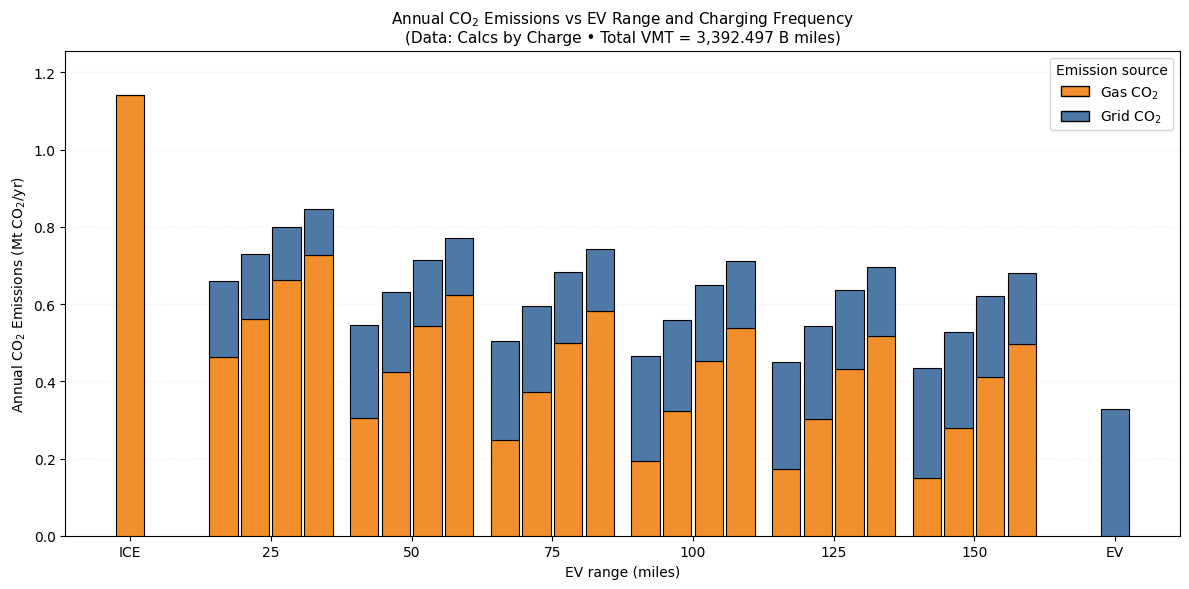

In [14]:
# ===== Figure 7 — Annual CO2 vs EV range & charging frequency (from Excel) =====
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.ticker import ScalarFormatter

# ---------- file + sheet ----------
xls_path  = "Calculations Check_final.xlsx"      # <- change if your filename is different
sheetname = "Calcs by Charge"

# ---------- constants (Average case) ----------
MPG_AVG        = 26.4          # gasoline mpg
MI_PER_KWH     = 3.6           # EV efficiency (mi/kWh)
GRID_g_per_kWh = 348.0         # grid CO2 intensity, g CO2/kWh
KG_PER_GAL     = 8.887         # fallback if sheet column is missing

RANGES = [25, 50, 75, 100, 125, 150]
CPW    = [7, 5, 3, 2]

# ---------- read & normalize (robust) ----------
df = pd.read_excel(xls_path, sheet_name=sheetname)
df.columns = df.columns.str.strip()

# Locate columns by fuzzy match
def _pick(name_opts):
    low = [c for c in df.columns if any(tok in c.lower() for tok in name_opts)]
    if not low:
        raise KeyError(f"Could not find column with tokens {name_opts} in {list(df.columns)}")
    return low[0]

col_charge = _pick(["charge"])                     # "Charge Freq"
col_vtype  = _pick(["vehicle"])                    # "Vehicle Type"
col_totvmt = _pick(["vmt"])                        # "VMT"
col_gasvmt = _pick(["gas vmt"])
col_elcvmt = next((c for c in df.columns if "electric vmt" in c.lower()), None)
col_galB   = next((c for c in df.columns if "gallons" in c.lower()), None)
col_ci_kg  = next((c for c in df.columns if "carbon intensity" in c.lower()), None)

# Parse EV range like "LDV (150-mile EV range)"
import re
def parse_range(text):
    m = re.search(r"(\d+)\s*-\s*mile", str(text))
    return float(m.group(1)) if m else np.nan

tmp = pd.DataFrame({
    "range": df[col_vtype].apply(parse_range),
    "charges_per_week": pd.to_numeric(df[col_charge], errors="coerce"),
    "total_vmt_b": pd.to_numeric(df[col_totvmt], errors="coerce"),
    "gas_vmt_b": pd.to_numeric(df[col_gasvmt], errors="coerce"),
})

# optional columns
if col_elcvmt is not None:
    tmp["ev_vmt_b"] = pd.to_numeric(df[col_elcvmt], errors="coerce")
else:
    tmp["ev_vmt_b"] = np.nan

if col_galB is not None:
    tmp["gallons_b"] = pd.to_numeric(df[col_galB], errors="coerce")
else:
    tmp["gallons_b"] = np.nan

if col_ci_kg is not None:
    tmp["kg_per_gal"] = pd.to_numeric(df[col_ci_kg], errors="coerce")
else:
    tmp["kg_per_gal"] = np.nan

# Drop rows that don't specify a valid range or charge freq
tmp = tmp.dropna(subset=["range","charges_per_week"]).copy()

# Cast to pandas nullable integer for safety (allows NA)
tmp["range"] = tmp["range"].round().astype("Int64")
tmp["charges_per_week"] = tmp["charges_per_week"].round().astype("Int64")

# Keep only the charging scenarios we plot
tmp = tmp[tmp["charges_per_week"].isin(CPW)].copy()

# If Electric VMT wasn't present, compute it from total - gas
mask_missing_e = tmp["ev_vmt_b"].isna()
tmp.loc[mask_missing_e, "ev_vmt_b"] = tmp.loc[mask_missing_e, "total_vmt_b"] - tmp.loc[mask_missing_e, "gas_vmt_b"]

# Fill missing gallons using MPG if needed
mask_missing_g = tmp["gallons_b"].isna()
tmp.loc[mask_missing_g, "gallons_b"] = tmp.loc[mask_missing_g, "gas_vmt_b"] / MPG_AVG

# Fill missing carbon intensity with fallback
tmp["kg_per_gal"] = tmp["kg_per_gal"].fillna(KG_PER_GAL)

# If there are duplicates per (range, cpw), take the first (or mean)
tmp = (tmp
       .sort_values([ "range","charges_per_week"])
       .drop_duplicates(["range","charges_per_week"])
       .reset_index(drop=True))

# Quick sanity check: do we have all 6×4 rows?
missing = {(r,c) for r in RANGES for c in CPW} - set(map(tuple, tmp[["range","charges_per_week"]].to_numpy()))
if missing:
    print("Warning: missing rows (range, cpw):", sorted(missing))

tidy = tmp.copy()

# ---------- emissions (Mt CO2) ----------
# Gas: B gallons * kg/gal = Mt  (1 B kg = 1 Mt)
tidy["gas_Mt"] = tidy["gallons_b"] * tidy["kg_per_gal"]

# EV (grid): per-mile kg = (GRID_g_per_kWh/1000)/MI_PER_KWH; B miles → Mt
kg_per_mile = (GRID_g_per_kWh / 1000.0) / MI_PER_KWH
tidy["ev_Mt"] = tidy["ev_vmt_b"] * kg_per_mile

# ---------- synthetic ICE/EV bars ----------
total_b = float(tidy["total_vmt_b"].dropna().iloc[0])
ice_gal_b = total_b / MPG_AVG
ice_row = {"range": pd.NA, "charges_per_week": 0, "total_vmt_b": total_b,
           "gas_vmt_b": total_b, "ev_vmt_b": 0.0,
           "gallons_b": ice_gal_b, "kg_per_gal": tidy["kg_per_gal"].iloc[0],
           "gas_Mt": ice_gal_b * tidy["kg_per_gal"].iloc[0], "ev_Mt": 0.0}
ev_row  = {"range": pd.NA, "charges_per_week": 999, "total_vmt_b": total_b,
           "gas_vmt_b": 0.0, "ev_vmt_b": total_b,
           "gallons_b": 0.0, "kg_per_gal": tidy["kg_per_gal"].iloc[0],
           "gas_Mt": 0.0, "ev_Mt": total_b * kg_per_mile}

tidy_all = pd.concat([pd.DataFrame([ice_row]), tidy, pd.DataFrame([ev_row])], ignore_index=True)
# ---------- build clustered bars ----------
clusters = []
labels   = []

clusters.append([("ICE", None)])            # cluster 0
labels.append("ICE")

for r in RANGES:
    rows = tidy_all[(tidy_all["range"] == r) & (tidy_all["charges_per_week"].isin(CPW))]
    rows = rows.set_index("charges_per_week").loc[CPW]   # ensure 7,5,3,2 order
    # store (caption, (gas_Mt, ev_Mt))
    clusters.append([(f"{cpw}/wk", (rows.loc[cpw, "gas_Mt"], rows.loc[cpw, "ev_Mt"])) for cpw in CPW])
    labels.append(str(r))

clusters.append([("EV", None)])             # last cluster
labels.append("EV")

# plotting geometry
cluster_width = 0.90
max_bars      = max(len(c) for c in clusters)  # = 4 for range clusters, 1 for ICE/EV
bar_w         = cluster_width / max_bars
x_center      = np.arange(len(clusters), dtype=float)

# precompute heights for simple ICE/EV clusters from synthetic rows
def heights_for(name):
    if name == "ICE":
        r = tidy_all.loc[tidy_all["charges_per_week"]==0].iloc[0]
        return r["gas_Mt"], r["ev_Mt"]
    if name == "EV":
        r = tidy_all.loc[tidy_all["charges_per_week"]==999].iloc[0]
        return r["gas_Mt"], r["ev_Mt"]
    return None

# ---------- plot ----------
plt.close('all')
fig, ax = plt.subplots(figsize=(12, 6))
COLOR_GAS = "#f28e2b"
COLOR_EV  = "#4e79a7"

for i, cluster in enumerate(clusters):
    k = len(cluster)
    left = x_center[i] - (k * bar_w)/2.0
    for j, (cap, pair) in enumerate(cluster):
        x = left + j*bar_w + bar_w/2.0
        if pair is None:  # ICE / EV single
            gas_mt, ev_mt = heights_for(cap)
        else:
            gas_mt, ev_mt = pair

        ax.bar(x, gas_mt, width=bar_w*0.9, color=COLOR_GAS, edgecolor="black", linewidth=0.8, zorder=3)
        ax.bar(x, ev_mt,  width=bar_w*0.9, bottom=gas_mt, color=COLOR_EV, edgecolor="black", linewidth=0.8, zorder=3)

# axes + cosmetics
ax.set_xticks(x_center)
ax.set_xticklabels(labels)
ax.set_xlabel("EV range (miles)")
ax.set_ylabel("Annual CO$_2$ Emissions (Mt CO$_2$/yr)")

ax.set_axisbelow(True)
ax.grid(axis="y", alpha=0.25, linestyle=":", linewidth=0.8)

ax.ticklabel_format(axis='y', style='plain', useOffset=False)
fmt = ScalarFormatter(useMathText=False); fmt.set_powerlimits((0,0)); fmt.set_useOffset(False)
ax.yaxis.set_major_formatter(fmt)
ax.get_yaxis().get_offset_text().set_visible(False)

ymax = (tidy_all["gas_Mt"] + tidy_all["ev_Mt"]).max()
ax.set_ylim(0, ymax * 1.10)

legend = ax.legend(
    handles=[Patch(facecolor=COLOR_GAS, edgecolor="black", label="Gas CO$_2$"),
             Patch(facecolor=COLOR_EV,  edgecolor="black", label="Grid CO$_2$")],
    loc="upper right", frameon=True, title="Emission source"
)

ax.set_title(
    "Annual CO$_2$ Emissions vs EV Range and Charging Frequency\n"
    f"(Data: {sheetname} • Total VMT = {total_b:,.3f} B miles)",
    fontsize=11
)

plt.tight_layout()
plt.show()


## Updated FIGURE 7

/tmp/ipython-input-2055194113.py:107: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  tidy_all = pd.concat([pd.DataFrame([ice_row]), tidy, pd.DataFrame([ev_row])], ignore_index=True)


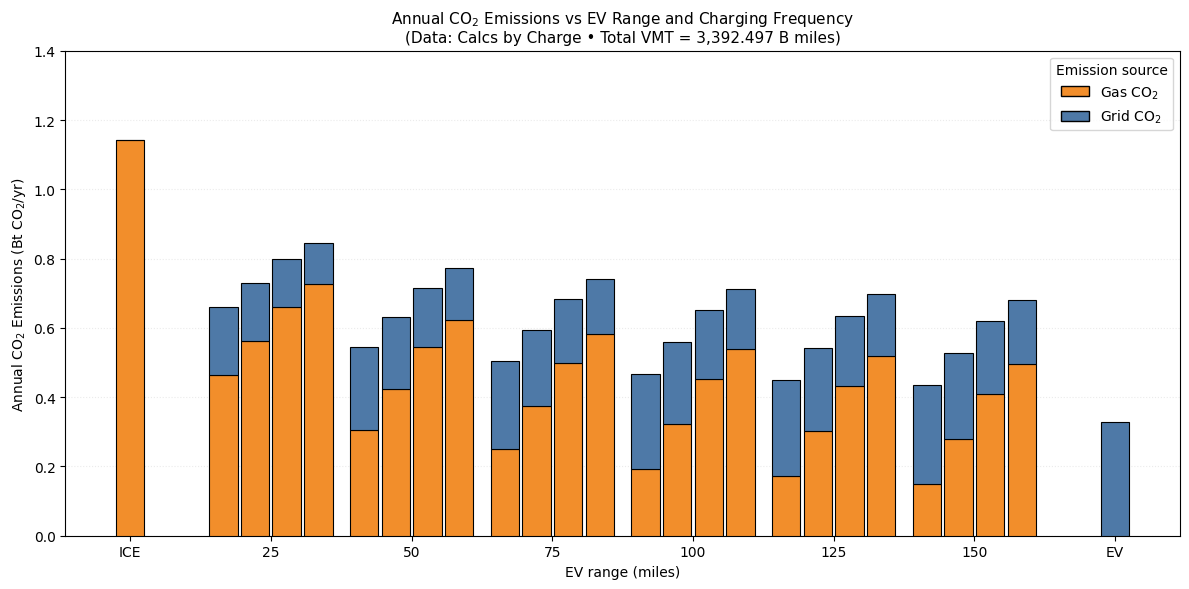

In [15]:
# ===== Figure 7 — Annual CO2 vs EV range & charging frequency (Bt, 0–1.4) =====
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.ticker import ScalarFormatter

# ---------- file + sheet ----------
xls_path  = "Calculations Check_final.xlsx"      # <- change if your filename is different
sheetname = "Calcs by Charge"

# ---------- constants (Average case) ----------
MPG_AVG        = 26.4          # gasoline mpg
MI_PER_KWH     = 3.6           # EV efficiency (mi/kWh)
GRID_g_per_kWh = 348.0         # grid CO2 intensity, g CO2/kWh
KG_PER_GAL     = 8.887         # fallback if sheet column is missing

RANGES = [25, 50, 75, 100, 125, 150]
CPW    = [7, 5, 3, 2]

# ---------- read & normalize (robust) ----------
df = pd.read_excel(xls_path, sheet_name=sheetname)
df.columns = df.columns.str.strip()

def _pick(name_opts):
    low = [c for c in df.columns if any(tok in c.lower() for tok in name_opts)]
    if not low:
        raise KeyError(f"Could not find column with tokens {name_opts} in {list(df.columns)}")
    return low[0]

col_charge = _pick(["charge"])
col_vtype  = _pick(["vehicle"])
col_totvmt = _pick(["vmt"])
col_gasvmt = _pick(["gas vmt"])
col_elcvmt = next((c for c in df.columns if "electric vmt" in c.lower()), None)
col_galB   = next((c for c in df.columns if "gallons" in c.lower()), None)
col_ci_kg  = next((c for c in df.columns if "carbon intensity" in c.lower()), None)

def parse_range(text):
    m = re.search(r"(\d+)\s*-\s*mile", str(text))
    return float(m.group(1)) if m else np.nan

tmp = pd.DataFrame({
    "range": df[col_vtype].apply(parse_range),
    "charges_per_week": pd.to_numeric(df[col_charge], errors="coerce"),
    "total_vmt_b": pd.to_numeric(df[col_totvmt], errors="coerce"),
    "gas_vmt_b": pd.to_numeric(df[col_gasvmt], errors="coerce"),
})

if col_elcvmt is not None:
    tmp["ev_vmt_b"] = pd.to_numeric(df[col_elcvmt], errors="coerce")
else:
    tmp["ev_vmt_b"] = np.nan

if col_galB is not None:
    tmp["gallons_b"] = pd.to_numeric(df[col_galB], errors="coerce")
else:
    tmp["gallons_b"] = np.nan

if col_ci_kg is not None:
    tmp["kg_per_gal"] = pd.to_numeric(df[col_ci_kg], errors="coerce")
else:
    tmp["kg_per_gal"] = np.nan

tmp = tmp.dropna(subset=["range","charges_per_week"]).copy()
tmp["range"] = tmp["range"].round().astype("Int64")
tmp["charges_per_week"] = tmp["charges_per_week"].round().astype("Int64")
tmp = tmp[tmp["charges_per_week"].isin(CPW)].copy()

mask_missing_e = tmp["ev_vmt_b"].isna()
tmp.loc[mask_missing_e, "ev_vmt_b"] = tmp.loc[mask_missing_e, "total_vmt_b"] - tmp.loc[mask_missing_e, "gas_vmt_b"]

mask_missing_g = tmp["gallons_b"].isna()
tmp.loc[mask_missing_g, "gallons_b"] = tmp.loc[mask_missing_g, "gas_vmt_b"] / MPG_AVG

tmp["kg_per_gal"] = tmp["kg_per_gal"].fillna(KG_PER_GAL)

tmp = (tmp
       .sort_values([ "range","charges_per_week"])
       .drop_duplicates(["range","charges_per_week"])
       .reset_index(drop=True))

missing = {(r,c) for r in RANGES for c in CPW} - set(map(tuple, tmp[["range","charges_per_week"]].to_numpy()))
if missing:
    print("Warning: missing rows (range, cpw):", sorted(missing))

tidy = tmp.copy()

# ---------- emissions (Mt CO2) ----------
tidy["gas_Mt"] = tidy["gallons_b"] * tidy["kg_per_gal"]
kg_per_mile = (GRID_g_per_kWh / 1000.0) / MI_PER_KWH
tidy["ev_Mt"] = tidy["ev_vmt_b"] * kg_per_mile

# ---------- synthetic ICE/EV bars (Mt) ----------
total_b = float(tidy["total_vmt_b"].dropna().iloc[0])
ice_gal_b = total_b / MPG_AVG
ice_row = {"range": pd.NA, "charges_per_week": 0, "total_vmt_b": total_b,
           "gas_vmt_b": total_b, "ev_vmt_b": 0.0,
           "gallons_b": ice_gal_b, "kg_per_gal": tidy["kg_per_gal"].iloc[0],
           "gas_Mt": ice_gal_b * tidy["kg_per_gal"].iloc[0], "ev_Mt": 0.0}
ev_row  = {"range": pd.NA, "charges_per_week": 999, "total_vmt_b": total_b,
           "gas_vmt_b": 0.0, "ev_vmt_b": total_b,
           "gallons_b": 0.0, "kg_per_gal": tidy["kg_per_gal"].iloc[0],
           "gas_Mt": 0.0, "ev_Mt": total_b * kg_per_mile}

tidy_all = pd.concat([pd.DataFrame([ice_row]), tidy, pd.DataFrame([ev_row])], ignore_index=True)

# >>> CONVERT to Billion metric tons (Bt) so 0–1.4 axis makes sense
tidy_all["gas_Bt"] = tidy_all["gas_Mt"] / 1000.0
tidy_all["ev_Bt"]  = tidy_all["ev_Mt"]  / 1000.0

# ---------- build clustered bars (use Bt) ----------
clusters = []
labels   = []

clusters.append([("ICE", None)])
labels.append("ICE")

for r in RANGES:
    rows = tidy_all[(tidy_all["range"] == r) & (tidy_all["charges_per_week"].isin(CPW))]
    rows = rows.set_index("charges_per_week").loc[CPW]   # ensure 7,5,3,2 order
    clusters.append([(f"{cpw}/wk", (rows.loc[cpw, "gas_Bt"], rows.loc[cpw, "ev_Bt"])) for cpw in CPW])
    labels.append(str(r))

clusters.append([("EV", None)])
labels.append("EV")

cluster_width = 0.90
max_bars      = max(len(c) for c in clusters)
bar_w         = cluster_width / max_bars
x_center      = np.arange(len(clusters), dtype=float)

def heights_for(name):
    if name == "ICE":
        r = tidy_all.loc[tidy_all["charges_per_week"]==0].iloc[0]
        return r["gas_Bt"], r["ev_Bt"]
    if name == "EV":
        r = tidy_all.loc[tidy_all["charges_per_week"]==999].iloc[0]
        return r["gas_Bt"], r["ev_Bt"]
    return None

# ---------- plot ----------
plt.close('all')
fig, ax = plt.subplots(figsize=(12, 6))
COLOR_GAS = "#f28e2b"
COLOR_EV  = "#4e79a7"

for i, cluster in enumerate(clusters):
    k = len(cluster)
    left = x_center[i] - (k * bar_w)/2.0
    for j, (cap, pair) in enumerate(cluster):
        x = left + j*bar_w + bar_w/2.0
        if pair is None:
            gas_bt, ev_bt = heights_for(cap)
        else:
            gas_bt, ev_bt = pair

        ax.bar(x, gas_bt, width=bar_w*0.9, color=COLOR_GAS, edgecolor="black", linewidth=0.8, zorder=3)
        ax.bar(x, ev_bt,  width=bar_w*0.9, bottom=gas_bt, color=COLOR_EV, edgecolor="black", linewidth=0.8, zorder=3)

ax.set_xticks(x_center)
ax.set_xticklabels(labels)
ax.set_xlabel("EV range (miles)")
ax.set_ylabel("Annual CO$_2$ Emissions (Bt CO$_2$/yr)")  # <<< Bt, not Mt

ax.set_axisbelow(True)
ax.grid(axis="y", alpha=0.25, linestyle=":", linewidth=0.8)

# Formatter is fine with Bt (values ~0–1.2)
fmt = ScalarFormatter(useMathText=False); fmt.set_powerlimits((0,0)); fmt.set_useOffset(False)
ax.yaxis.set_major_formatter(fmt)
ax.get_yaxis().get_offset_text().set_visible(False)

# >>> Fixed axis as requested
ax.set_ylim(0, 1.4)

legend = ax.legend(
    handles=[Patch(facecolor=COLOR_GAS, edgecolor="black", label="Gas CO$_2$"),
             Patch(facecolor=COLOR_EV,  edgecolor="black", label="Grid CO$_2$")],
    loc="upper right", frameon=True, title="Emission source"
)

ax.set_title(
    "Annual CO$_2$ Emissions vs EV Range and Charging Frequency\n"
    f"(Data: {sheetname} • Total VMT = {total_b:,.3f} B miles)",
    fontsize=11
)

plt.tight_layout()
plt.show()


# FIGURE 8

Detected sheets: ['Calcs by Scenario', 'Calcs by Charge', 'Trip Bin Distance', 'Table 4', 'Table  5', 'Table 6']
Using CAPEX sheet: Table  5
Using Saved/VMT sheet: Table  5


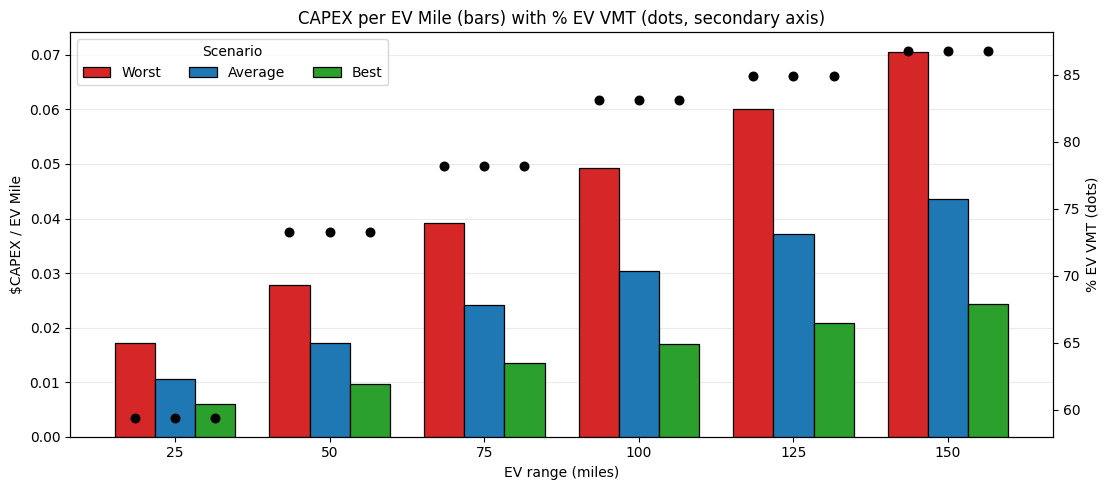

In [16]:
import numpy as np
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.ticker import MultipleLocator, FormatStrFormatter

EXCEL_PATH = "/content/Calculations Check_final.xlsx"   # set as needed

# -------------------- helpers --------------------
def normalize_headers_inplace(df: pd.DataFrame) -> None:
    df.columns = (
        df.columns.astype(str)
        .str.strip()
        .str.replace(r"\s+", " ", regex=True)  # collapse repeats
    )

def pick_col(df, *need):
    """Pick a column whose lowercase header contains all tokens in *need."""
    need = tuple(k.lower() for k in need)
    for c in df.columns:
        s = str(c).lower()
        if all(k in s for k in need):
            return c
    raise KeyError(f"Need columns containing: {need}\nAvailable: {list(df.columns)}")

def try_pick(df, *need):
    try:
        return pick_col(df, *need)
    except KeyError:
        return None

def pick_capex_evmi(df):
    # Accept either "... EV Mile" or "... Electric Mile"
    c = try_pick(df, "capex", "ev", "mile")
    if c is None:
        c = pick_col(df, "capex", "electric", "mile")
    return c

def pick_capex_perkg(df):
    return pick_col(df, "capex", "kg", "co2")

def extract_range_mi(txt):
    m = re.search(r"(\d+)\s*(?:-?\s*mile|mi)\b", str(txt), flags=re.I)
    return int(m.group(1)) if m else np.nan

# -------------------- constants (Average case) --------------------
TOTAL_VMT_B = 3262.8
TOTAL_MILES = TOTAL_VMT_B * 1e9
PARAMS = {
    "Worst":   {"mpg": 18.0, "mi_per_kwh": 2.9, "grid_gpkwh": 714.0, "gas_$": 2.00, "elec_$": 0.15},
    "Average": {"mpg": 26.4, "mi_per_kwh": 3.6, "grid_gpkwh": 348.0, "gas_$": 3.00, "elec_$": 0.25},
    "Best":    {"mpg": 36.0, "mi_per_kwh": 4.2, "grid_gpkwh": 125.0, "gas_$": 5.00, "elec_$": 0.40},
}
AVG = PARAMS["Average"]
RANGES = [25, 50, 75, 100, 125, 150]
CHARGE_SCENS = [7, 5, 3, 2]  # charges/week
DAILY = np.array([35, 40, 30, 45, 25, 70, 55], float)
WEEKLY_TOTAL = float(DAILY.sum())

def schedule_charges_by_day(cpw:int):
    if cpw <= 0:  return []
    if cpw >= 7:  return list(range(7))
    idx = np.round(np.linspace(0, 6, num=cpw)).astype(int)
    out, seen = [], set()
    for i in idx:
        i = int(np.clip(i, 0, 6))
        if i not in seen:
            out.append(i); seen.add(i)
    return sorted(out)

def simulate_week(R: float, cpw: int, day_miles: np.ndarray):
    soc = float(R); ev = gas = 0.0
    charges = set(schedule_charges_by_day(cpw))
    for d in range(7):
        need = float(day_miles[d])
        ev_d  = min(soc, need)
        gas_d = need - ev_d
        ev  += ev_d; gas += gas_d
        soc = max(0.0, soc - ev_d)
        if d in charges:
            soc = float(R)
    return ev, gas

# -------------------- load workbook & normalize --------------------
xls = pd.ExcelFile(EXCEL_PATH)
sheet_names = xls.sheet_names
print("Detected sheets:", sheet_names)

sheets = {name: xls.parse(name) for name in sheet_names}
for name, df in sheets.items():
    normalize_headers_inplace(df)

# ---- robust sheet detection (do not assume "Table 4") ----
def looks_like_capex(df):
    cols = [c.lower() for c in df.columns]
    has_evmi = any(("capex" in c and "ev" in c and "mile" in c) or ("capex" in c and "electric" in c and "mile" in c) for c in cols)
    has_kg   = any(("capex" in c and "kg" in c and "co2" in c) for c in cols)
    has_vtype = any(("vehicle" in c and "type" in c) or "ldv" in c for c in cols)
    has_scn   = any("scenario" in c for c in cols)
    return has_evmi and has_kg and has_vtype and has_scn

def looks_like_saved_or_vmt(df):
    cols = [c.lower() for c in df.columns]
    has_saved = any(("co2" in c and "saved" in c) for c in cols)
    has_vmt   = any("gas vmt" in c for c in cols) and any(("electric" in c and "vmt" in c) for c in cols)
    has_vtype = any(("vehicle" in c and "type" in c) or "ldv" in c for c in cols)
    has_scn   = any("scenario" in c for c in cols)
    return (has_saved or has_vmt) and has_vtype and has_scn

# pick capex sheet
capex_candidates = [n for n, df in sheets.items() if looks_like_capex(df)]
if not capex_candidates:
    raise RuntimeError("Could not find a sheet with CAPEX / EV mile and CAPEX / kg CO2 saved.")
CAPEX_SHEET = capex_candidates[0]

# pick saved/vmt sheet
saved_candidates = [n for n, df in sheets.items() if looks_like_saved_or_vmt(df)]
if not saved_candidates:
    raise RuntimeError("Could not find a sheet with CO2 Saved or EV/Gas VMT.")
SAVED_VMT_SHEET = saved_candidates[0]

print("Using CAPEX sheet:", CAPEX_SHEET)
print("Using Saved/VMT sheet:", SAVED_VMT_SHEET)

df4 = sheets[CAPEX_SHEET].copy()
df3 = sheets[SAVED_VMT_SHEET].copy()

# -------------------- tidy CAPEX pivots --------------------
c_scn4         = pick_col(df4, "scenario")
c_vtype4       = pick_col(df4, "vehicle", "type")
c_capex_evmi   = pick_capex_evmi(df4)
c_capex_kg     = pick_capex_perkg(df4)

# ensure numerics
for c in (c_capex_evmi, c_capex_kg):
    df4[c] = pd.to_numeric(df4[c], errors="coerce")

df4c = df4[[c_scn4, c_vtype4, c_capex_evmi, c_capex_kg]].copy()
df4c["Scenario"] = (
    df4c[c_scn4].astype(str).str.strip().str.title().str.replace("Mid", "Average", regex=False)
)
df4c["Range_mi"] = df4c[c_vtype4].apply(extract_range_mi)

capex_evmi = (
    df4c.pivot_table(index="Range_mi", columns="Scenario", values=c_capex_evmi, aggfunc="first")
    .reindex(RANGES)
)
capex_perkg = (
    df4c.pivot_table(index="Range_mi", columns="Scenario", values=c_capex_kg, aggfunc="first")
    .reindex(RANGES)
)

# optional %EV column
pct_ev = None
c_pct_ev_try = try_pick(df4, "%", "ev")
if c_pct_ev_try:
    tmp = df4[[c_scn4, c_vtype4, c_pct_ev_try]].copy()
    tmp["Scenario"] = tmp[c_scn4].astype(str).str.strip().str.title().str.replace("Mid", "Average", regex=False)
    tmp["Range_mi"] = tmp[c_vtype4].apply(extract_range_mi)
    pct_ev = (
        tmp.pivot_table(index="Range_mi", columns="Scenario", values=c_pct_ev_try, aggfunc="first")
        .reindex(RANGES)
    )

# -------------------- tidy Saved (Mt) and/or VMT --------------------
c_scn3   = pick_col(df3, "scenario")
c_vtype3 = pick_col(df3, "vehicle", "type")

# Try Saved (Mt) first
saved_Mt = None
c_saved3_try = try_pick(df3, "co2", "saved")
if c_saved3_try:
    df3s = df3[[c_scn3, c_vtype3, c_saved3_try]].copy()
    df3s["Scenario"] = df3s[c_scn3].astype(str).str.strip().str.title().str.replace("Mid", "Average", regex=False)
    df3s["Range_mi"] = df3s[c_vtype3].apply(extract_range_mi)
    saved_Mt = (
        df3s.pivot_table(index="Range_mi", columns="Scenario", values=c_saved3_try, aggfunc="sum")
        .reindex(RANGES)
    )

# Derive %EV from VMT if needed
pct_ev_from_vmt = None
c_evB  = try_pick(df3, "electric", "vmt")
c_gasB = try_pick(df3, "gas", "vmt")
if c_evB and c_gasB:
    t = df3[[c_scn3, c_vtype3, c_evB, c_gasB]].copy()
    t["Scenario"] = t[c_scn3].astype(str).str.strip().str.title().str.replace("Mid", "Average", regex=False)
    t["Range_mi"] = t[c_vtype3].apply(extract_range_mi)
    pv = (
        t.pivot_table(index="Range_mi", columns="Scenario", values=[c_evB, c_gasB], aggfunc="sum")
        .reindex(RANGES)
    )
    if "Average" in pv[c_evB].columns and "Average" in pv[c_gasB].columns:
        pct_ev_from_vmt = (pv[c_evB]["Average"] / (pv[c_evB]["Average"] + pv[c_gasB]["Average"]) * 100.0).to_numpy()
plt.close('all')
fig, ax1 = plt.subplots(figsize=(11.2, 5.0))

scenarios = ["Worst","Average","Best"]
colors    = {"Worst":"#d62728","Average":"#1f77b4","Best":"#2ca02c"}
W         = 0.26
xg        = np.arange(len(RANGES))
offsets   = {s: (i-1)*W for i, s in enumerate(scenarios)}  # bar centers for each scenario

# --- Bars ---
for s in scenarios:
    y = capex_evmi[s].to_numpy(float)
    ax1.bar(xg + offsets[s], y, width=W, color=colors[s],
            edgecolor="black", linewidth=0.9, label=s, zorder=3)

ax1.set_xticks(xg); ax1.set_xticklabels([str(r) for r in RANGES])
ax1.set_xlabel("EV range (miles)")
ax1.set_ylabel("$CAPEX / EV Mile")
ax1.grid(axis="y", alpha=0.25)
ax1.legend(title="Scenario", ncols=3, loc="upper left")
ax1.set_title("CAPEX per EV Mile (bars) with % EV VMT (dots, secondary axis)")

# --- Dots (one per bar) ---
ax2 = ax1.twinx()

def _as_array(x):
    return None if x is None else np.asarray(x, dtype=float)

dots_by_scenario = {}

if pct_ev is not None:
    # If pct_ev has scenario columns, use them; otherwise reuse the series for all.
    try:
        cols = set(getattr(pct_ev, "columns", []))
    except Exception:
        cols = set()
    for s in scenarios:
        if s in cols:
            dots_by_scenario[s] = pct_ev[s].reindex(RANGES).to_numpy(float)
        else:
            # pct_ev is a 1D series/array -> use for all scenarios
            dots_by_scenario[s] = _as_array(getattr(pct_ev, "values", pct_ev))
elif pct_ev_from_vmt is not None:
    # Accept dict of arrays or single array
    if isinstance(pct_ev_from_vmt, dict):
        base = _as_array(pct_ev_from_vmt.get("Average"))
        for s in scenarios:
            arr = _as_array(pct_ev_from_vmt.get(s, base))
            dots_by_scenario[s] = arr
    else:
        arr = _as_array(pct_ev_from_vmt)
        for s in scenarios:
            dots_by_scenario[s] = arr
else:
    # Fallback smooth ramp
    arr = np.linspace(60, 87, len(RANGES))
    for s in scenarios:
        dots_by_scenario[s] = arr

# Plot one dot per bar (aligned to each bar’s x position)
for s in scenarios:
    arr = dots_by_scenario[s]
    # ensure correct length
    if arr is None or len(arr) != len(RANGES):
        arr = np.interp(np.arange(len(RANGES)), np.arange(len(arr)), arr) if arr is not None else np.zeros(len(RANGES))
    ax2.scatter(xg + offsets[s], arr, s=38, color="black", zorder=4)

ax2.set_ylabel("% EV VMT (dots)", color="black")
ax2.tick_params(axis='y', colors="black")

plt.tight_layout()
plt.savefig("fig3_capex_per_ev_mile_with_pct_ev.png", dpi=200)
plt.show()


## Updated FIGURE 8

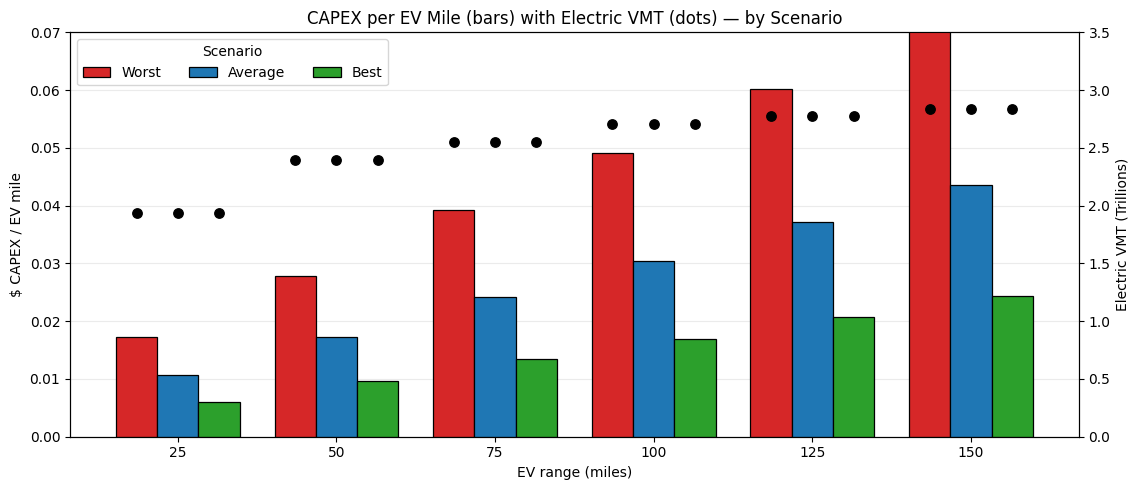

In [17]:
# ==== FIGURE 8 — CAPEX per EV Mile (bars by Scenario) + Electric VMT dots (secondary) ====
# Primary Y: 0–0.07   Secondary Y: Electric VMT 0–3.5 Trillion
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

EXCEL_PATH = "Calculations Check_final.xlsx"     # adjust if needed
SHEET_SCEN = "Calcs by Scenario"
RANGES = [25, 50, 75, 100, 125, 150]
SCENARIO_ORDER = ["Worst", "Average", "Best"]
BAR_COLORS = {"Worst": "#d62728", "Average": "#1f77b4", "Best": "#2ca02c"}

# ---------- helpers ----------
def _norm(df: pd.DataFrame):
    df.columns = (df.columns.astype(str)
                  .str.replace("\n", " ", regex=False)
                  .str.strip()
                  .str.replace(r"\s+", " ", regex=True)
                  .str.lower())

def _find_header_row(path, sheet, max_scan=200):
    raw = pd.read_excel(path, sheet_name=sheet, header=None, nrows=max_scan)
    for i in range(len(raw)):
        row = " ".join(map(str, raw.iloc[i].fillna(""))).lower()
        if ("scenario" in row and "vehicle" in row) or ("capex" in row and "mile" in row):
            return i
    return 0

def _pick(df, *need, allow_any=False):
    need = [n.lower() for n in need]
    for c in df.columns:
        ok = all(n in c for n in need) if not allow_any else any(n in c for n in need)
        if ok: return c
    return None

def _title_scen(s: str) -> str:
    s = str(s).strip().title()
    if s.startswith("Mid"): return "Average"
    if s.startswith("Aver"): return "Average"
    if s.startswith("Wor"): return "Worst"
    if s.startswith("Bes"): return "Best"
    return s

def _range_mi(txt):
    m = re.search(r"(\d+)\s*(?:-?\s*mile|mi)\b", str(txt), flags=re.I)
    return int(m.group(1)) if m else np.nan

# ---------- read “Calcs by Scenario” ----------
hdr = _find_header_row(EXCEL_PATH, SHEET_SCEN)
dfs = pd.read_excel(EXCEL_PATH, sheet_name=SHEET_SCEN, header=hdr)
_norm(dfs)

c_vtype = _pick(dfs, "vehicle", "type")
c_scen  = _pick(dfs, "scen") or _pick(dfs, "scenario")
c_capex = _pick(dfs, "capex", "ev", "mile") or _pick(dfs, "capex", "electric", "mile")
c_evB   = _pick(dfs, "electric", "vmt")      # billions

if not all([c_vtype, c_scen, c_capex, c_evB]):
    raise RuntimeError(f"Could not find required columns in '{SHEET_SCEN}'. "
                       f"Got: {list(dfs.columns)}")

df = dfs.copy()
df = df[df[c_vtype].astype(str).str.contains("ldv", case=False, na=False)]
df = df[df[c_vtype].astype(str).str.contains("ev range", case=False, na=False)]

df["range_mi"] = df[c_vtype].apply(_range_mi)
df["Scenario"] = df[c_scen].map(_title_scen)
df[c_capex] = pd.to_numeric(df[c_capex], errors="coerce")
df[c_evB]   = pd.to_numeric(df[c_evB],   errors="coerce")  # billions

# pivot: bars (CAPEX/EV mile) and dots (Electric VMT in Trillions)
pivot_capex = (df.pivot_table(index="range_mi", columns="Scenario", values=c_capex, aggfunc="first")
                 .reindex(index=RANGES))
pivot_evB   = (df.pivot_table(index="range_mi", columns="Scenario", values=c_evB,   aggfunc="first")
                 .reindex(index=RANGES))

present_scens = [s for s in SCENARIO_ORDER if s in pivot_capex.columns] or list(pivot_capex.columns)

# convert billions → trillions for plotting on secondary axis
ev_T = pivot_evB[present_scens].to_numpy(dtype=float) / 1000.0   # shape: len(RANGES) × nscen

# ---------- plot ----------
plt.close('all')
fig, ax1 = plt.subplots(figsize=(11.5, 5.0))

x = np.arange(len(RANGES))
W = 0.26
offsets = {s: (i-(len(present_scens)-1)/2)*W for i, s in enumerate(present_scens)}

# bars
for s in present_scens:
    y = pivot_capex[s].to_numpy(float)
    ax1.bar(x + offsets[s], y, width=W, color=BAR_COLORS.get(s, "#777"),
            edgecolor="black", linewidth=0.9, label=s, zorder=3)

ax1.set_xticks(x)
ax1.set_xticklabels([str(r) for r in RANGES])
ax1.set_xlabel("EV range (miles)")
ax1.set_ylabel("$ CAPEX / EV mile")
ax1.set_ylim(0, 0.07)                 # required primary axis
ax1.grid(axis="y", alpha=0.25, zorder=0)
ax1.legend(title="Scenario", ncols=min(3, len(present_scens)), loc="upper left")

# dots for Electric VMT (Trillions) — one dot per bar (aligned with that bar)
ax2 = ax1.twinx()
for j, s in enumerate(present_scens):
    ax2.scatter(x + offsets[s], ev_T[:, j], s=46, color="black", zorder=5)
ax2.set_ylabel("Electric VMT (Trillions)", color="black")
ax2.set_ylim(0, 3.5)                   # required secondary axis
ax2.tick_params(axis='y', colors="black")

ax1.set_title("CAPEX per EV Mile (bars) with Electric VMT (dots) — by Scenario")

plt.tight_layout()
plt.show()


# FIGURE 9

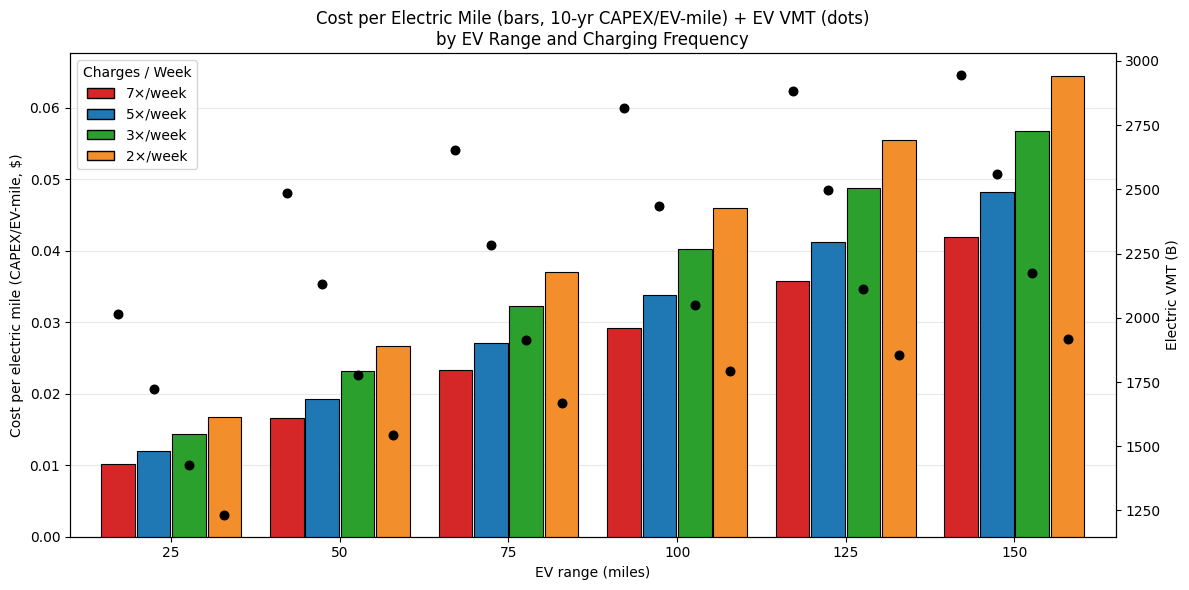

Scenario sheet used: Table  5
CPW sheet used: Calcs by Charge

CAPEX map ($, by range):
25 2.058e+11
50 4.117e+11
75 6.175e+11
100 8.233e+11
125 1.029e+12
150 1.235e+12

Preview (range, cpw, EV_VMT_B, $/EV_mile):
 range_mi  cpw    EV_VMT_B  $/EV_mile
     25.0    2 1233.457284   0.016688
     25.0    2         NaN        NaN
     25.0    3 1428.527213   0.014409
     25.0    3         NaN        NaN
     25.0    5 1721.132107   0.011959
     25.0    5         NaN        NaN
     25.0    7 2013.737001   0.010222
     25.0    7         NaN        NaN
     50.0    2 1542.101561   0.026695
     50.0    2         NaN        NaN
     50.0    3 1778.105919   0.023152
     50.0    3         NaN        NaN
     50.0    5 2132.112454   0.019308
     50.0    5         NaN        NaN
     50.0    7 2486.118990   0.016559
     50.0    7         NaN        NaN
     75.0    2 1667.094586   0.037041
     75.0    2         NaN        NaN
     75.0    3 1913.424830   0.032272
     75.0    3         NaN 

In [18]:
#figure 9
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

EXCEL_PATH = "/content/Calculations Check_final.xlsx"

# Desired orders & colors
RANGE_ORDER = [25, 50, 75, 100, 125, 150]
CPW_ORDER   = [7, 5, 3, 2]
SCEN_BASE   = "Average"          # numerator scenario for CAPEX
YEARS       = 10                 # 10-year lifespan for CAPEX amortization
COLORS = {7: "#d62728", 5: "#1f77b4", 3: "#2ca02c", 2: "#f28e2b"}

# ---------------- helpers ----------------
def normalize_headers_inplace(df: pd.DataFrame) -> None:
    df.columns = (df.columns.astype(str)
                  .str.strip()
                  .str.replace(r"\s+", " ", regex=True))

def find_header_row(path: str, sheet: str, max_scan: int = 250) -> int:
    """Scan for a row that looks like the header."""
    raw = pd.read_excel(path, sheet_name=sheet, header=None, nrows=max_scan)
    for i in range(min(max_scan, len(raw))):
        row = " ".join(map(str, raw.iloc[i].fillna("").tolist())).lower()
        if any(k in row for k in ["scenario", "scen"]) or \
           any(k in row for k in ["vehicle", "ldv", "type", "ev range"]) or \
           any(k in row for k in ["charge", "freq", "cpw"]) or \
           any(k in row for k in ["oc", "elc", "electric", "vmt"]) or \
           any(k in row for k in ["installed battery", "twh"]) or \
           any(k in row for k in ["$ / kwh", "$/kwh", "cost / kwh"]):
            return i
    return 0

def pick_col(df: pd.DataFrame, token_sets):
    """
    Return first column whose lowercase header contains ALL tokens in any of the given token tuples.
    token_sets: list[tuple[str,...]] — ordered by preference.
    """
    cols  = list(df.columns)
    lower = [str(c).lower() for c in cols]
    for tokens in token_sets:
        toks = [t.lower() for t in tokens]
        for c, s in zip(cols, lower):
            if all(t in s for t in toks):
                return c
    return None

def must_pick(df: pd.DataFrame, token_sets, context: str):
    c = pick_col(df, token_sets)
    if c is None:
        raise KeyError(f"Could not find a column for {context}. Headers present: {list(df.columns)}")
    return c

def extract_range_mi(text: str):
    m = re.search(r'(\d+)\s*[- ]?\s*(?:mi|mile)\b', str(text), flags=re.I)
    return float(m.group(1)) if m else np.nan

def parse_cpw(val):
    # Accept numeric or text like "7x/week", "5 per week", etc.
    if isinstance(val, (int, float, np.integer, np.floating)):
        v = float(val);  return int(v) if v.is_integer() else None
    s = str(val).lower()
    if "before every trip" in s:  # we exclude that row (not 7/5/3/2)
        return None
    m = re.search(r'(\d+)', s)
    return int(m.group(1)) if m else None

def choose_sheet_by_content(xls: pd.ExcelFile, want="capex"):
    """
    Pick the best sheet heuristically.
    want="capex": look for scenario + capex/installed battery
    want="cpw":   look for charge frequency + EV VMT or % electric + OC ELC / TWh
    """
    for name in xls.sheet_names:
        try:
            hdr = find_header_row(EXCEL_PATH, name)
            df  = pd.read_excel(EXCEL_PATH, sheet_name=name, header=hdr)
            normalize_headers_inplace(df)
            row = " ".join(df.columns.astype(str).str.lower().tolist())
            if want == "capex":
                if ("scenario" in row or "scen" in row) and \
                   (("installed" in row and "battery" in row) or
                    ("capex" in row) or
                    ("$t" in row and "installed" in row)):
                    return name
            else:  # cpw
                if (("charge" in row and "freq" in row) or "cpw" in row or "charges/week" in row) and \
                   (("electric" in row and "vmt" in row) or ("% electric" in row) or ("oc" in row and "elc" in row) or ("twh" in row)):
                    return name
        except Exception:
            continue
    # fallback to common names
    return "Calcs by Scenario" if want == "capex" else "Calcs by Charge"

# ---------------- locate & load sheets ----------------
xls = pd.ExcelFile(EXCEL_PATH)

SCEN_SHEET = choose_sheet_by_content(xls, want="capex")
CPW_SHEET  = choose_sheet_by_content(xls, want="cpw")

hdr_s = find_header_row(EXCEL_PATH, SCEN_SHEET)
hdr_c = find_header_row(EXCEL_PATH, CPW_SHEET)

df_scen = pd.read_excel(EXCEL_PATH, sheet_name=SCEN_SHEET, header=hdr_s)
df_cpw  = pd.read_excel(EXCEL_PATH, sheet_name=CPW_SHEET,  header=hdr_c)

normalize_headers_inplace(df_scen)
normalize_headers_inplace(df_cpw)

# ---------------- build CAPEX per range (Scenario = Average) ----------------
col_scen_vehicle = must_pick(df_scen, [
    ("vehicle", "type"),
    ("ldv", "ev range"),
    ("ldv",),
], "Vehicle/Type (scenario sheet)")

col_scen_scen = must_pick(df_scen, [
    ("scenario",),
    ("scen",),
], "Scenario (scenario sheet)")

# Preferred direct CAPEX total in $T (trillion)
col_capex_T = pick_col(df_scen, [
    ("$t", "installed", "battery"),
    ("$ t", "installed", "battery"),
    ("capex", "total"),
])

# Fallback: Installed Battery (TWh) and Cost / kWh
col_inst_TWh = None
col_cost_kwh = None
if col_capex_T is None:
    col_inst_TWh = must_pick(df_scen, [
        ("installed", "battery", "(twh"),
        ("installed", "battery", "twh"),
        ("battery", "twh"),
    ], "Installed Battery (TWh) (scenario sheet)")
    col_cost_kwh = must_pick(df_scen, [
        ("$ / kwh",),
        ("$/kwh",),
        ("cost", "/", "kwh"),
    ], "$/kWh (scenario sheet)")

# filter LDV EV range rows and the baseline scenario (Average)
sc = df_scen.copy()
mask_ldv = sc[col_scen_vehicle].astype(str).str.contains("ldv", case=False, na=False) & \
           sc[col_scen_vehicle].astype(str).str.contains("ev range", case=False, na=False)
sc = sc[mask_ldv].copy()
sc["range_mi"] = sc[col_scen_vehicle].map(extract_range_mi := extract_range_mi)

# unify scenario text
sc["Scenario"] = sc[col_scen_scen].astype(str).str.strip().str.title().str.replace("Mid", "Average", regex=False)
sc = sc[sc["Scenario"].str.lower() == SCEN_BASE.lower()].copy()

# numeric CAPEX_$ per range
if col_capex_T is not None:
    sc["CAPEX_$"] = pd.to_numeric(sc[col_capex_T], errors="coerce") * 1e12
else:
    sc["CAPEX_$"] = pd.to_numeric(sc[col_inst_TWh], errors="coerce") * 1e9 * pd.to_numeric(sc[col_cost_kwh], errors="coerce")

capex_map = dict(zip(sc["range_mi"], sc["CAPEX_$"]))

# ---------------- build EV-VMT by (range, cpw) ----------------
col_cpw_vehicle = must_pick(df_cpw, [
    ("vehicle", "type"),
    ("ldv", "ev range"),
    ("ldv",),
], "Vehicle/Type (cpw sheet)")

col_cpw_freq = must_pick(df_cpw, [
    ("charge", "freq"),
    ("charges", "week"),
    ("charges/week",),
    ("cpw",),
    ("charge", "per", "week"),
], "Charge frequency / CPW (cpw sheet)")

# EV VMT (B) can have variants
col_elc_vmtB = pick_col(df_cpw, [
    ("electric", "vmt"),
    ("ev", "vmt"),
    ("electric vmt (b)",),
    ("ev vmt (b)",),
])

# If EV VMT (B) missing, derive from % Electric * TotalVMT (but we only need relative by cpw; we’ll still use it directly)
TOTAL_VMT_B = 3262.8
col_pct_elec = None
if col_elc_vmtB is None:
    col_pct_elec = must_pick(df_cpw, [
        ("%", "electric"),
        ("percent", "electric"),
        ("pct", "electric"),
        ("% electric",),
    ], "% Electric (cpw sheet)")

cp = df_cpw.copy()
mask_ldv_c = cp[col_cpw_vehicle].astype(str).str.contains("ldv", case=False, na=False) & \
             cp[col_cpw_vehicle].astype(str).str.contains("ev range", case=False, na=False)
cp = cp[mask_ldv_c].copy()

cp["range_mi"] = cp[col_cpw_vehicle].map(extract_range_mi)

cp["cpw"] = cp[col_cpw_freq].map(parse_cpw)
cp = cp.dropna(subset=["cpw", "range_mi"]).copy()
cp["cpw"] = cp["cpw"].astype(int)

if col_elc_vmtB is not None:
    cp["EV_VMT_B"] = pd.to_numeric(cp[col_elc_vmtB], errors="coerce")
else:
    pct = pd.to_numeric(cp[col_pct_elec], errors="coerce")
    cp["EV_VMT_B"] = pct * (TOTAL_VMT_B / 100.0)

# ---------------- compute $/EV-mile (10-year CAPEX / EV miles) ----------------
# EV miles = EV_VMT_B * 1e9
def per_mile_cost(row):
    cap = capex_map.get(float(row["range_mi"]), np.nan)
    miles_yr = float(row["EV_VMT_B"]) * 1e9
    miles_10y = YEARS * miles_yr
    return (cap / miles_10y) if (np.isfinite(cap) and miles_10y > 0) else np.nan

cp["$/EV_mile"] = cp.apply(per_mile_cost, axis=1)

# ---------------- pivot for plotting ----------------
pivot_cost = cp.pivot_table(index="cpw", columns="range_mi", values="$/EV_mile", aggfunc="first")
pivot_vmtB = cp.pivot_table(index="cpw", columns="range_mi", values="EV_VMT_B", aggfunc="first")

pivot_cost = pivot_cost.reindex(index=[c for c in CPW_ORDER if c in pivot_cost.index],
                                columns=[r for r in RANGE_ORDER if r in pivot_cost.columns])
pivot_vmtB = pivot_vmtB.reindex_like(pivot_cost)

cpw_list = list(pivot_cost.index)
ranges   = list(pivot_cost.columns)

# ---------------- plot ----------------
fig, ax1 = plt.subplots(figsize=(12, 6))
x = np.arange(len(ranges))

group_w = 0.84
bar_w = group_w / max(1, len(cpw_list))
offsets = (np.arange(len(cpw_list)) - (len(cpw_list)-1)/2.0) * bar_w

# Bars: $/EV-mile (10-year CAPEX / EV miles)
for k, cpw in enumerate(cpw_list):
    y = pivot_cost.loc[cpw].to_numpy(float)
    pos = x + offsets[k]
    ax1.bar(pos, y, width=bar_w*0.95,
            color=COLORS.get(cpw, "gray"),
            edgecolor="black", lw=0.8, zorder=3,
            label=f"{cpw}×/week")

ax1.set_xticks(x)
ax1.set_xticklabels([f"{int(r)}" for r in ranges])
ax1.set_xlim(-0.6, len(ranges)-0.4)
ax1.set_ylabel("Cost per electric mile (CAPEX/EV-mile, $)")
ax1.set_xlabel("EV range (miles)")
ax1.grid(True, axis="y", alpha=0.28, zorder=0)
ax1.set_title("Cost per Electric Mile (bars, 10-yr CAPEX/EV-mile) + EV VMT (dots)\nby EV Range and Charging Frequency")

# Dots: EV VMT (B)
ax2 = ax1.twinx()
for k, cpw in enumerate(cpw_list):
    ydot = pivot_vmtB.loc[cpw].to_numpy(float)
    pos  = x + offsets[k]
    ax2.scatter(pos, ydot, s=38, color="black", zorder=4)

ax2.set_ylabel("Electric VMT (B)", color="black")
ax2.tick_params(axis='y', colors="black")

# Legend
handles = [Patch(facecolor=COLORS[c], edgecolor="black", label=f"{c}×/week") for c in cpw_list]
ax1.legend(handles=handles, loc="upper left", frameon=True, title="Charges / Week")

plt.tight_layout()
plt.show()

# ---- quick check (top rows)
print("Scenario sheet used:", SCEN_SHEET)
print("CPW sheet used:", CPW_SHEET)
print("\nCAPEX map ($, by range):")
for r in sorted(capex_map):
    print(int(r), f"{capex_map[r]:.4g}")

print("\nPreview (range, cpw, EV_VMT_B, $/EV_mile):")
preview = (cp[["range_mi","cpw","EV_VMT_B","$/EV_mile"]]
           .sort_values(["range_mi","cpw"])
           .head(24))
print(preview.to_string(index=False))

## Updated FIGURE 9

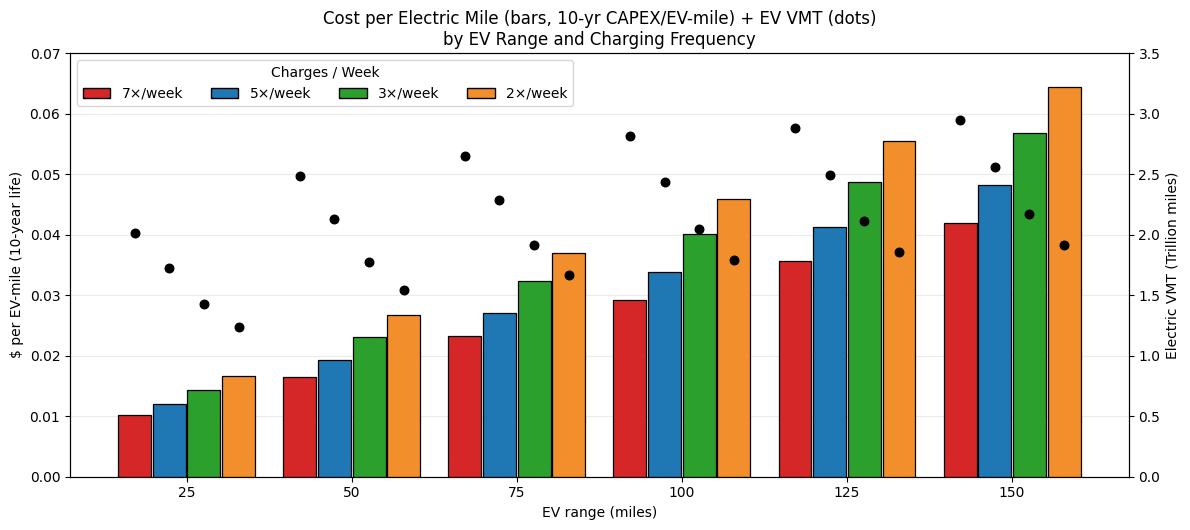

In [19]:
# ==== FIGURE 9 — CAPEX per EV-mile over 10 years (bars by charges/week) + Electric VMT dots ====
# Primary Y: 0–0.07 ; Secondary Y: 0–3.5 Trillion

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

EXCEL_PATH = "Calculations Check_final.xlsx"
SHEET_CHG  = "Calcs by Charge"

RANGES = [25, 50, 75, 100, 125, 150]
CPW    = [7, 5, 3, 2]

# requested bar colors per charges/week
COLORS = {7: "#d62728", 5: "#1f77b4", 3: "#2ca02c", 2: "#f28e2b"}
BAR_FALLBACK = "#8c8c8c"

# ---------- helpers ----------
def _norm(df):
    df.columns = (df.columns.astype(str)
        .str.replace("\n"," ",regex=False).str.strip()
        .str.replace(r"\s+"," ",regex=True).str.lower())

def _find_header_row(path, sheet, max_scan=250):
    raw = pd.read_excel(path, sheet_name=sheet, header=None, nrows=max_scan)
    for i in range(len(raw)):
        row = " ".join(map(str, raw.iloc[i].fillna(""))).lower()
        if ("vehicle" in row and "type" in row) or ("charge" in row) or ("vmt" in row):
            return i
    return 0

def _pick_first(df, *tokens):
    toks = [t.lower() for t in tokens]
    hits = [c for c in df.columns if all(t in c for t in toks)]
    return hits[0] if hits else None

def _range_mi(s):
    m = re.search(r"(\d+)\s*(?:-?\s*mile|mi)\b", str(s), flags=re.I)
    return int(m.group(1)) if m else np.nan

def _cpw_parse(s):
    s = str(s).lower()
    if "before every trip" in s:
        return None
    m = re.search(r"\d+", s)
    return int(m.group(0)) if m else None

# ---------- load "Calcs by Charge" ----------
hdr = _find_header_row(EXCEL_PATH, SHEET_CHG)
df = pd.read_excel(EXCEL_PATH, sheet_name=SHEET_CHG, header=hdr)
_norm(df)

c_vtype = _pick_first(df, "vehicle", "type")
c_chg   = _pick_first(df, "charge", "freq") or _pick_first(df, "charges", "week")

# If there are duplicate Electric VMT (B) columns, just use the first match.
ev_cols = [c for c in df.columns if ("electric" in c and "vmt" in c)]
if not ev_cols:
    raise RuntimeError("Electric VMT column not found.")
c_evB = ev_cols[0]  # <- use one

# CAPEX sources in the same sheet
c_cap_T   = _pick_first(df, "$t", "installed", "battery") or _pick_first(df, "trillion", "installed", "battery")
c_instTWh = _pick_first(df, "installed", "battery", "twh")
c_costkwh = _pick_first(df, "cost", "/", "kwh") or _pick_first(df, "cost", "kwh")

if c_vtype is None or c_chg is None:
    raise RuntimeError("Missing Vehicle Type or Charge Freq columns.")

# keep LDV EV-range rows & parse fields
df = df[df[c_vtype].astype(str).str.contains("ldv", case=False, na=False)]
df = df[df[c_vtype].astype(str).str.contains("ev range", case=False, na=False)].copy()

df["range"] = df[c_vtype].apply(_range_mi)
df["cpw"]   = df[c_chg].map(_cpw_parse)
df[c_evB]   = pd.to_numeric(df[c_evB], errors="coerce")  # Billions
df = df.dropna(subset=["range","cpw"]).copy()

# ---------- CAPEX total $ per range ----------
if c_cap_T is not None:
    df["capex_total_$"] = pd.to_numeric(df[c_cap_T], errors="coerce") * 1e12
elif c_instTWh is not None and c_costkwh is not None:
    inst_kwh = pd.to_numeric(df[c_instTWh], errors="coerce") * 1e9  # TWh → kWh
    cost     = pd.to_numeric(df[c_costkwh], errors="coerce")
    df["capex_total_$"] = inst_kwh * cost
else:
    raise RuntimeError("CAPEX inputs not found in Calcs by Charge (need $T Installed Battery OR Installed Battery (TWh)+Cost/kWh).")

capex_by_range = df.groupby("range", as_index=True)["capex_total_$"].median().reindex(RANGES)

# ---------- EV VMT (handle duplicate (range,cpw) rows by grouping) ----------
evT_by_cpw = {}
ev10y_miles_by_cpw = {}
for cp in CPW:
    sub = df[df["cpw"] == cp][["range", c_evB]].copy()
    serB = sub.groupby("range", as_index=True)[c_evB].median().reindex(RANGES)  # Billions
    evT_by_cpw[cp]         = (serB / 1000.0).to_numpy(float)         # Trillion (dots)
    ev10y_miles_by_cpw[cp] = (serB * 1e9 * 10.0).to_numpy(float)     # 10-year miles

# ---------- $ per EV-mile (10-year) ----------
bars = np.full((len(CPW), len(RANGES)), np.nan)
num = capex_by_range.to_numpy(float)
for i, cp in enumerate(CPW):
    denom = ev10y_miles_by_cpw[cp]
    with np.errstate(divide="ignore", invalid="ignore"):
        bars[i] = np.where(np.isfinite(denom) & (denom > 0), num / denom, np.nan)

# ---------- plot ----------
plt.close("all")
fig, ax1 = plt.subplots(figsize=(12, 5.4))

x = np.arange(len(RANGES))
group_w = 0.84
W = group_w / len(CPW)
offsets = (np.arange(len(CPW)) - (len(CPW)-1)/2.0) * W

for i, cp in enumerate(CPW):
    ax1.bar(
        x + offsets[i], bars[i], width=W*0.95,
        color=COLORS.get(cp, BAR_FALLBACK), edgecolor="black",
        linewidth=0.9, zorder=3, label=f"{cp}×/week"
    )

ax1.set_ylim(0, 0.07)
ax1.set_ylabel("$ per EV-mile (10-year life)")
ax1.set_xlabel("EV range (miles)")
ax1.set_xticks(x)
ax1.set_xticklabels([str(r) for r in RANGES])
ax1.grid(axis="y", alpha=0.25, zorder=0)
# Legend in the requested color order
handles = [Patch(facecolor=COLORS.get(cp, BAR_FALLBACK), edgecolor="black", label=f"{cp}×/week") for cp in CPW]
ax1.legend(handles=handles, title="Charges / Week", ncols=4, loc="upper left")
ax1.set_title("Cost per Electric Mile (bars, 10-yr CAPEX/EV-mile) + EV VMT (dots)\nby EV Range and Charging Frequency")

# secondary axis: Electric VMT (Trillions) dots
ax2 = ax1.twinx()
for i, cp in enumerate(CPW):
    ax2.scatter(x + offsets[i], evT_by_cpw[cp], s=38, color="black", zorder=5)
ax2.set_ylim(0, 3.5)
ax2.set_ylabel("Electric VMT (Trillion miles)", color="black")
ax2.tick_params(axis="y", colors="black")

plt.tight_layout()
plt.show()


# FIGURE 10

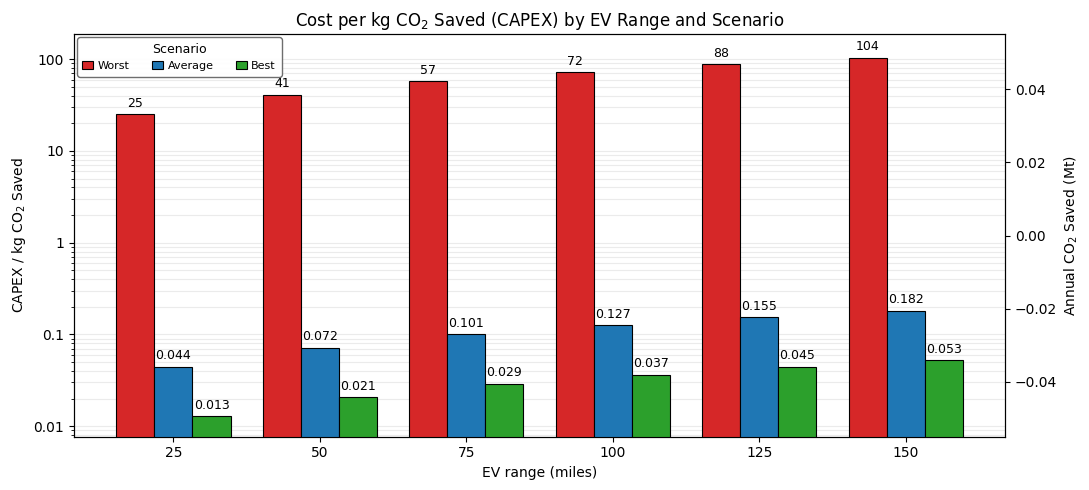


[CHECK] CAPEX/kg CO2 pivot:
Scenario       Worst  Average    Best
Range (mi)                           
25           25.2327   0.0443  0.0128
50           40.8767   0.0717  0.0207
75           57.4708   0.1009  0.0292
100          72.1069   0.1265  0.0366
125          88.1619   0.1547  0.0447
150         103.5296   0.1817  0.0525

[CHECK] CO2 Saved (Mt) pivot:
Scenario    Worst  Average  Best
Range (mi)                      
25            NaN      NaN   NaN
50            NaN      NaN   NaN
75            NaN      NaN   NaN
100           NaN      NaN   NaN
125           NaN      NaN   NaN
150           NaN      NaN   NaN


In [20]:
# ==== FIGURE 10 — CAPEX / kg CO2 Saved (bars, log-y) + CO2 Saved dots (secondary) ====
# Works with the latest workbook and auto-detects the right sheets/headers/columns.

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# ---------------- CONFIG ----------------
EXCEL_PATH = "Calculations Check_final - Copy.xlsx"   # update if your path differs
SCENARIO_ORDER = ["Worst", "Average", "Best"]
RANGE_ORDER    = [25, 50, 75, 100, 125, 150]

# ---------------- helpers ----------------
def normalize_headers_inplace(df: pd.DataFrame) -> None:
    df.columns = (
        df.columns.astype(str)
        .str.replace("\n", " ", regex=False)
        .str.strip()
        .str.replace(r"\s+", " ", regex=True)
        .str.replace("co₂", "co2", case=False)
        .str.replace("$", "", regex=False)
    )

def find_header_row(path: str, sheet: str, max_scan: int = 250) -> int:
    raw = pd.read_excel(path, sheet_name=sheet, header=None, nrows=max_scan)
    patterns = [
        ("scenario",),
        ("vehicle", "type"),
        ("capex", "kg", "co2"),
        ("co2", "saved"),
    ]
    for i in range(min(max_scan, len(raw))):
        row = " ".join(map(str, raw.iloc[i].fillna("").tolist())).lower()
        score = sum(all(tok in row for tok in pats) for pats in patterns)
        if score >= 2:
            return i
    return 0

def pick_col(df: pd.DataFrame, *need_tokens, allow_any=False):
    toks = [t.lower() for t in need_tokens]
    for c in df.columns:
        s = str(c).lower()
        ok = all(t in s for t in toks) if not allow_any else any(t in s for t in toks)
        if ok:
            return c
    raise KeyError(f"Need column with tokens {need_tokens}. Available: {list(df.columns)}")

def try_pick(df: pd.DataFrame, *need_tokens, allow_any=False):
    try:
        return pick_col(df, *need_tokens, allow_any=allow_any)
    except KeyError:
        return None

def extract_range(s):
    m = re.search(r"(\d+)\s*(?:-?\s*mile|mi)\b", str(s), flags=re.IGNORECASE)
    return int(m.group(1)) if m else np.nan

def norm_scenario(s):
    s = str(s).strip().title()
    if s.startswith("Wor"):  return "Worst"
    if s.startswith("Mid") or s.startswith("Aver"): return "Average"
    if s.startswith("Bes"):  return "Best"
    return s

def looks_like_sheet4(df: pd.DataFrame) -> bool:
    cols = [c.lower() for c in df.columns]
    return (
        any("scenario" in c for c in cols) and
        any(("vehicle" in c and "type" in c) for c in cols) and
        any(("capex" in c and "kg" in c and "co2" in c) for c in cols)
    )

def looks_like_sheet3(df: pd.DataFrame) -> bool:
    cols = [c.lower() for c in df.columns]
    has_saved = any(("co2" in c and "saved" in c) for c in cols)
    return (
        has_saved and
        any("scenario" in c for c in cols) and
        any(("vehicle" in c and "type" in c) for c in cols)
    )

# ---------------- load workbook & pick sheets ----------------
xls = pd.ExcelFile(EXCEL_PATH)

sheet4_df = None
sheet3_df = None

# Prefer any sheet name hinting “Calcs by Scenario” for sheet4_df; else autodetect
preferred4 = None
for n in xls.sheet_names:
    if "scenario" in n.lower():
        preferred4 = n
        break

if preferred4:
    hdr = find_header_row(EXCEL_PATH, preferred4)
    df_try = pd.read_excel(EXCEL_PATH, sheet_name=preferred4, header=hdr)
    normalize_headers_inplace(df_try)
    if looks_like_sheet4(df_try):
        sheet4_df = df_try

if sheet4_df is None:
    for n in xls.sheet_names:
        hdr = find_header_row(EXCEL_PATH, n)
        df_try = pd.read_excel(EXCEL_PATH, sheet_name=n, header=hdr)
        normalize_headers_inplace(df_try)
        if looks_like_sheet4(df_try):
            sheet4_df = df_try
            break

# Prefer any sheet name hinting “Calcs by Charge” for sheet3_df; else autodetect
preferred3 = None
for n in xls.sheet_names:
    if "charge" in n.lower():
        preferred3 = n
        break

if preferred3:
    hdr = find_header_row(EXCEL_PATH, preferred3)
    df_try = pd.read_excel(EXCEL_PATH, sheet_name=preferred3, header=hdr)
    normalize_headers_inplace(df_try)
    if looks_like_sheet3(df_try):
        sheet3_df = df_try

if sheet3_df is None:
    for n in xls.sheet_names:
        hdr = find_header_row(EXCEL_PATH, n)
        df_try = pd.read_excel(EXCEL_PATH, sheet_name=n, header=hdr)
        normalize_headers_inplace(df_try)
        if looks_like_sheet3(df_try):
            sheet3_df = df_try
            break

if sheet4_df is None or sheet3_df is None:
    raise RuntimeError("Could not locate required sheets with CAPEX/kg CO2 and CO2 Saved.")

# ---------------- bars: CAPEX / kg CO2 (sheet4_df) ----------------
c_scen4   = pick_col(sheet4_df, "scenario")
c_vtype4  = pick_col(sheet4_df, "vehicle", "type")
# Handle "$ CAPEX / kg CO2" or similar variants
c_capexkg = try_pick(sheet4_df, "capex", "kg", "co2")
if c_capexkg is None:
    raise KeyError(f"Missing CAPEX/kg CO2 column in sheet4_df. Columns={list(sheet4_df.columns)}")

df4 = sheet4_df[[c_scen4, c_vtype4, c_capexkg]].dropna(subset=[c_vtype4]).copy()
df4["Scenario"]  = df4[c_scen4].map(norm_scenario)
df4["Range (mi)"] = df4[c_vtype4].map(extract_range).astype(float)

mask_ldv = sheet4_df[c_vtype4].astype(str).str.contains("LDV", case=False, na=False) & \
           sheet4_df[c_vtype4].astype(str).str.contains("EV range", case=False, na=False)
df4 = df4[mask_ldv.reindex(df4.index, fill_value=False)].copy()

pivot = (
    df4.pivot_table(index="Range (mi)", columns="Scenario", values=c_capexkg, aggfunc="first")
       .reindex(index=RANGE_ORDER, columns=SCENARIO_ORDER)
)

# ---------------- dots: Annual CO2 saved (Mt) (sheet3_df) ----------------
def pick_col_saved(df_like):
    # prioritize explicit saved column
    c = try_pick(df_like, "co2", "saved")
    if c: return c
    # fallback: sometimes split columns exist; we expect one “CO2 Saved (Mt)”
    # If not present, we can't draw dots.
    return None

c_scen3  = pick_col(sheet3_df, "scen")  # matches "Scenario", "Scen", etc.
c_vtype3 = pick_col(sheet3_df, "vehicle", "type")
c_saved3 = pick_col_saved(sheet3_df)

piv_saved = None
if c_saved3 is not None:
    df3 = sheet3_df[[c_scen3, c_vtype3, c_saved3]].dropna(subset=[c_vtype3]).copy()
    df3["Scenario"]   = df3[c_scen3].map(norm_scenario)
    df3["Range (mi)"] = df3[c_vtype3].map(extract_range).astype(float)
    mask_ldv3 = sheet3_df[c_vtype3].astype(str).str.contains("LDV", case=False, na=False) & \
                sheet3_df[c_vtype3].astype(str).str.contains("EV range", case=False, na=False)
    df3 = df3[mask_ldv3.reindex(df3.index, fill_value=False)].copy()
    piv_saved = (
        df3.pivot_table(index="Range (mi)", columns="Scenario", values=c_saved3, aggfunc="sum")
           .reindex(index=RANGE_ORDER, columns=SCENARIO_ORDER)
    )

# ---------------- plot ----------------
x = np.arange(len(RANGE_ORDER))
W = 0.26
offsets = [-W, 0, W]
colors = {"Worst": "#d62728", "Average": "#1f77b4", "Best": "#2ca02c"}

fig, ax = plt.subplots(figsize=(11, 5))
containers = []
for i, scen in enumerate(SCENARIO_ORDER):
    y = pivot[scen].to_numpy(float)
    cont = ax.bar(x + offsets[i], y, width=W, color=colors[scen],
                  edgecolor="black", linewidth=0.8, label=scen, zorder=3)
    containers.append((cont, y))

# log-y so small bars remain visible
# guard for all-nan
if np.all(~np.isfinite(pivot.to_numpy(dtype=float))):
    ax.set_ylim(1e-3, 1)
else:
    ymin = np.nanmin(pivot.to_numpy(dtype=float))
    ymin = 1e-3 if not np.isfinite(ymin) or ymin <= 0 else max(1e-3, ymin*0.6)
    ymax = np.nanmax(pivot.to_numpy(dtype=float))
    ymax = 1 if not np.isfinite(ymax) or ymax <= 0 else ymax*1.8
    ax.set_ylim(ymin, ymax)

ax.set_yscale("log")
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:g}"))

# compact value labels (respect log scale limits)
upper = ax.get_ylim()[1]
fmt = lambda v: (f"{v:.3f}" if v < 1 else (f"{v:.2f}" if v < 10 else f"{v:.0f}"))
pos = lambda v: min(v * 1.12, upper * 0.95)

for cont, y in containers:
    for rect, val in zip(cont, y):
        if np.isfinite(val) and val > 0:
            ax.annotate(fmt(val),
                        xy=(rect.get_x() + rect.get_width()/2, pos(val)),
                        xytext=(0, 0), textcoords="offset points",
                        ha="center", va="bottom", fontsize=9, clip_on=False)

# secondary dots: CO2 Saved (Mt), if available
if piv_saved is not None:
    ax2 = ax.twinx()
    for i, scen in enumerate(SCENARIO_ORDER):
        ydot = piv_saved[scen].to_numpy(float)
        ax2.scatter(x + offsets[i], ydot, s=34, color="black", zorder=4)
    ax2.set_ylabel("Annual CO$_2$ Saved (Mt)", color="black")
    ax2.tick_params(axis='y', colors="black")

# axes & legend
ax.set_xticks(x)
ax.set_xticklabels([str(r) for r in RANGE_ORDER])
ax.set_xlabel("EV range (miles)")
ax.set_ylabel("CAPEX / kg CO$_2$ Saved")
ax.set_title("Cost per kg CO$_2$ Saved (CAPEX) by EV Range and Scenario")
ax.grid(True, axis="y", which="both", alpha=0.25, zorder=0)

leg = ax.legend(
    title="Scenario",
    ncols=3,
    loc="upper left",
    frameon=True,
    fontsize=8,
    title_fontsize=9,
    handlelength=1.0,
    handletextpad=0.4,
    borderpad=0.25
)
frame = leg.get_frame()
frame.set_linewidth(1.0)
frame.set_edgecolor("#666")
frame.set_alpha(0.95)
try:
    frame.set_boxstyle("round,pad=0.25")
except Exception:
    pass

plt.tight_layout()
plt.show()

# quick checks
print("\n[CHECK] CAPEX/kg CO2 pivot:")
print(pivot.round(4))
if piv_saved is not None:
    print("\n[CHECK] CO2 Saved (Mt) pivot:")
    print(piv_saved.round(1))
else:
    print("\n[CHECK] CO2 Saved (Mt): not found in workbook; dots suppressed.")


## Updated FIGURE 10

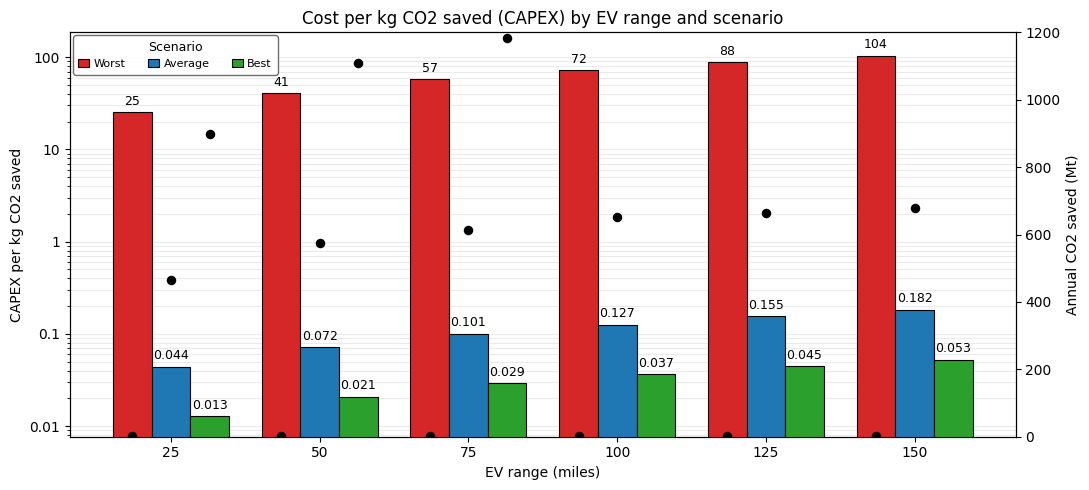

In [21]:
# ==== FIGURE 10 — CAPEX / kg CO2 Saved (bars, log-y) + CO2 Saved dots (secondary) ====

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

EXCEL_PATH = "Calculations Check_final.xlsx"   # update if needed
SCENARIO_ORDER = ["Worst", "Average", "Best"]
RANGE_ORDER    = [25, 50, 75, 100, 125, 150]

# ---------------- helpers ----------------
def normalize_headers_inplace(df: pd.DataFrame) -> None:
    df.columns = (
        df.columns.astype(str)
        .str.replace("\n", " ", regex=False)
        .str.strip()
        .str.replace(r"\s+", " ", regex=True)
        .str.replace("co₂", "co2", case=False)
        .str.replace("$", "", regex=False)
    )

def find_header_row(path: str, sheet: str, max_scan: int = 250) -> int:
    raw = pd.read_excel(path, sheet_name=sheet, header=None, nrows=max_scan)
    patterns = [
        ("scenario",),
        ("vehicle", "type"),
        ("capex", "kg", "co2"),
        ("co2", "saved"),
    ]
    for i in range(min(max_scan, len(raw))):
        row = " ".join(map(str, raw.iloc[i].fillna("").tolist())).lower()
        score = sum(all(tok in row for tok in pats) for pats in patterns)
        if score >= 2:
            return i
    return 0

def pick_col(df: pd.DataFrame, *need_tokens, allow_any=False):
    toks = [t.lower() for t in need_tokens]
    for c in df.columns:
        s = str(c).lower()
        ok = all(t in s for t in toks) if not allow_any else any(t in s for t in toks)
        if ok:
            return c
    raise KeyError(f"Need column with tokens {need_tokens}. Available: {list(df.columns)}")

def try_pick(df: pd.DataFrame, *need_tokens, allow_any=False):
    try:
        return pick_col(df, *need_tokens, allow_any=allow_any)
    except KeyError:
        return None

def extract_range(s):
    m = re.search(r"(\d+)\s*(?:-?\s*mile|mi)\b", str(s), flags=re.IGNORECASE)
    return int(m.group(1)) if m else np.nan

def norm_scenario(s):
    s = str(s).strip().title()
    if s.startswith("Wor"):  return "Worst"
    if s.startswith("Mid") or s.startswith("Aver"): return "Average"
    if s.startswith("Bes"):  return "Best"
    return s

def looks_like_sheet4(df: pd.DataFrame) -> bool:
    cols = [c.lower() for c in df.columns]
    return (
        any("scenario" in c for c in cols) and
        any(("vehicle" in c and "type" in c) for c in cols) and
        any(("capex" in c and "kg" in c and "co2" in c) for c in cols)
    )

def looks_like_sheet3(df: pd.DataFrame) -> bool:
    cols = [c.lower() for c in df.columns]
    has_saved = any(("co2" in c and "saved" in c) for c in cols)
    return (
        has_saved and
        any("scenario" in c for c in cols) and
        any(("vehicle" in c and "type" in c) for c in cols)
    )

# ---------------- load workbook & pick sheets ----------------
xls = pd.ExcelFile(EXCEL_PATH)
sheet4_df = None
sheet3_df = None

# prefer "scenario" sheet for sheet4_df
preferred4 = next((n for n in xls.sheet_names if "scenario" in n.lower()), None)
if preferred4:
    hdr = find_header_row(EXCEL_PATH, preferred4)
    df_try = pd.read_excel(EXCEL_PATH, sheet_name=preferred4, header=hdr)
    normalize_headers_inplace(df_try)
    if looks_like_sheet4(df_try):
        sheet4_df = df_try

if sheet4_df is None:
    for n in xls.sheet_names:
        hdr = find_header_row(EXCEL_PATH, n)
        df_try = pd.read_excel(EXCEL_PATH, sheet_name=n, header=hdr)
        normalize_headers_inplace(df_try)
        if looks_like_sheet4(df_try):
            sheet4_df = df_try
            break

# prefer "charge" sheet for sheet3_df
preferred3 = next((n for n in xls.sheet_names if "charge" in n.lower()), None)
if preferred3:
    hdr = find_header_row(EXCEL_PATH, preferred3)
    df_try = pd.read_excel(EXCEL_PATH, sheet_name=preferred3, header=hdr)
    normalize_headers_inplace(df_try)
    if looks_like_sheet3(df_try):
        sheet3_df = df_try

if sheet3_df is None:
    for n in xls.sheet_names:
        hdr = find_header_row(EXCEL_PATH, n)
        df_try = pd.read_excel(EXCEL_PATH, sheet_name=n, header=hdr)
        normalize_headers_inplace(df_try)
        if looks_like_sheet3(df_try):
            sheet3_df = df_try
            break

if sheet4_df is None or sheet3_df is None:
    raise RuntimeError("Could not locate required sheets with CAPEX/kg CO2 and CO2 Saved.")

# ---------------- bars: CAPEX / kg CO2 ----------------
c_scen4   = pick_col(sheet4_df, "scenario")
c_vtype4  = pick_col(sheet4_df, "vehicle", "type")
c_capexkg = try_pick(sheet4_df, "capex", "kg", "co2")
if c_capexkg is None:
    raise KeyError("Missing CAPEX/kg CO2 column in sheet4_df")

df4 = sheet4_df[[c_scen4, c_vtype4, c_capexkg]].dropna(subset=[c_vtype4]).copy()
df4["Scenario"]   = df4[c_scen4].map(norm_scenario)
df4["Range (mi)"] = df4[c_vtype4].map(extract_range).astype(float)

mask_ldv = sheet4_df[c_vtype4].astype(str).str.contains("LDV", case=False, na=False) & \
           sheet4_df[c_vtype4].astype(str).str.contains("EV range", case=False, na=False)
df4 = df4[mask_ldv.reindex(df4.index, fill_value=False)].copy()

pivot = (
    df4.pivot_table(index="Range (mi)", columns="Scenario", values=c_capexkg, aggfunc="first")
       .reindex(index=RANGE_ORDER, columns=SCENARIO_ORDER)
)

# ---------------- dots: Annual CO2 saved (Mt) ----------------
def pick_col_saved(df_like):
    c = try_pick(df_like, "co2", "saved")
    return c

c_scen3  = pick_col(sheet3_df, "scen")
c_vtype3 = pick_col(sheet3_df, "vehicle", "type")
c_saved3 = pick_col_saved(sheet3_df)

piv_saved = None
if c_saved3 is not None:
    df3 = sheet3_df[[c_scen3, c_vtype3, c_saved3]].dropna(subset=[c_vtype3]).copy()
    df3["Scenario"]   = df3[c_scen3].map(norm_scenario)
    df3["Range (mi)"] = df3[c_vtype3].map(extract_range).astype(float)
    mask_ldv3 = sheet3_df[c_vtype3].astype(str).str.contains("LDV", case=False, na=False) & \
                sheet3_df[c_vtype3].astype(str).str.contains("EV range", case=False, na=False)
    df3 = df3[mask_ldv3.reindex(df3.index, fill_value=False)].copy()
    # convert to Mt
    df3[c_saved3] = pd.to_numeric(df3[c_saved3], errors="coerce")
    piv_saved = (
        df3.pivot_table(index="Range (mi)", columns="Scenario", values=c_saved3, aggfunc="sum")
           .reindex(index=RANGE_ORDER, columns=SCENARIO_ORDER)
    )

# ---------------- plot ----------------
x = np.arange(len(RANGE_ORDER))
W = 0.26
offsets = [-W, 0, W]
colors = {"Worst": "#d62728", "Average": "#1f77b4", "Best": "#2ca02c"}

fig, ax = plt.subplots(figsize=(11, 5))
containers = []
for i, scen in enumerate(SCENARIO_ORDER):
    y = pivot[scen].to_numpy(float)
    cont = ax.bar(x + offsets[i], y, width=W, color=colors[scen],
                  edgecolor="black", linewidth=0.8, label=scen, zorder=3)
    containers.append((cont, y))

# log-y for visibility
if np.all(~np.isfinite(pivot.to_numpy(dtype=float))):
    ax.set_ylim(1e-3, 1)
else:
    ymin = np.nanmin(pivot.to_numpy(dtype=float))
    ymin = 1e-3 if not np.isfinite(ymin) or ymin <= 0 else max(1e-3, ymin*0.6)
    ymax = np.nanmax(pivot.to_numpy(dtype=float))
    ymax = 1 if not np.isfinite(ymax) or ymax <= 0 else ymax*1.8
    ax.set_ylim(ymin, ymax)

ax.set_yscale("log")
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:g}"))

upper = ax.get_ylim()[1]
fmt = lambda v: (f"{v:.3f}" if v < 1 else (f"{v:.2f}" if v < 10 else f"{v:.0f}"))
pos = lambda v: min(v * 1.12, upper * 0.95)

for cont, y in containers:
    for rect, val in zip(cont, y):
        if np.isfinite(val) and val > 0:
            ax.annotate(fmt(val),
                        xy=(rect.get_x() + rect.get_width()/2, pos(val)),
                        xytext=(0, 0), textcoords="offset points",
                        ha="center", va="bottom", fontsize=9, clip_on=False)

# secondary dots for CO2 saved (Mt), same 0–1200 range you want
if piv_saved is not None:
    ax2 = ax.twinx()
    for i, scen in enumerate(SCENARIO_ORDER):
        ydot = piv_saved[scen].to_numpy(float)
        ax2.scatter(x + offsets[i], ydot, s=34, color="black", zorder=4)
    ax2.set_ylabel("Annual CO2 saved (Mt)", color="black")
    ax2.tick_params(axis='y', colors="black")
    ax2.set_ylim(0, 1200)   # <-- fixed range

# axes & legend text without extra $
ax.set_xticks(x)
ax.set_xticklabels([str(r) for r in RANGE_ORDER])
ax.set_xlabel("EV range (miles)")
ax.set_ylabel("CAPEX per kg CO2 saved")
ax.set_title("Cost per kg CO2 saved (CAPEX) by EV range and scenario")
ax.grid(True, axis="y", which="both", alpha=0.25, zorder=0)

leg = ax.legend(
    title="Scenario",
    ncols=3,
    loc="upper left",
    frameon=True,
    fontsize=8,
    title_fontsize=9,
    handlelength=1.0,
    handletextpad=0.4,
    borderpad=0.25
)
frame = leg.get_frame()
frame.set_linewidth(1.0)
frame.set_edgecolor("#666")
frame.set_alpha(0.95)
try:
    frame.set_boxstyle("round,pad=0.25")
except Exception:
    pass

plt.tight_layout()
plt.show()



## Updated Figure 10 - Part 2

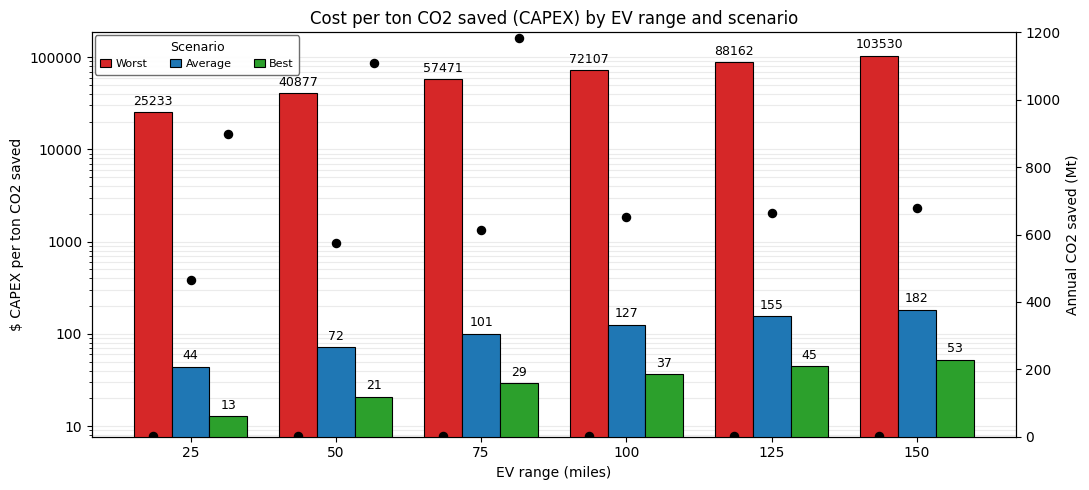

In [22]:
# ==== FIGURE 10 — CAPEX / ton CO2 Saved (bars, log-y) + CO2 Saved dots (secondary) ====
# Change from prior version: multiply CAPEX/kg by 1000 to plot CAPEX/ton.

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

EXCEL_PATH = "Calculations Check_final.xlsx"   # update if needed
SCENARIO_ORDER = ["Worst", "Average", "Best"]
RANGE_ORDER    = [25, 50, 75, 100, 125, 150]

# ---------------- helpers ----------------
def normalize_headers_inplace(df: pd.DataFrame) -> None:
    df.columns = (
        df.columns.astype(str)
        .str.replace("\n", " ", regex=False)
        .str.strip()
        .str.replace(r"\s+", " ", regex=True)
        .str.replace("co₂", "co2", case=False)
        .str.replace("$", "", regex=False)
    )

def find_header_row(path: str, sheet: str, max_scan: int = 250) -> int:
    raw = pd.read_excel(path, sheet_name=sheet, header=None, nrows=max_scan)
    patterns = [
        ("scenario",),
        ("vehicle", "type"),
        ("capex", "kg", "co2"),
        ("co2", "saved"),
    ]
    for i in range(min(max_scan, len(raw))):
        row = " ".join(map(str, raw.iloc[i].fillna("").tolist())).lower()
        score = sum(all(tok in row for tok in pats) for pats in patterns)
        if score >= 2:
            return i
    return 0

def pick_col(df: pd.DataFrame, *need_tokens, allow_any=False):
    toks = [t.lower() for t in need_tokens]
    for c in df.columns:
        s = str(c).lower()
        ok = all(t in s for t in toks) if not allow_any else any(t in s for t in toks)
        if ok:
            return c
    raise KeyError(f"Need column with tokens {need_tokens}. Available: {list(df.columns)}")

def try_pick(df: pd.DataFrame, *need_tokens, allow_any=False):
    try:
        return pick_col(df, *need_tokens, allow_any=allow_any)
    except KeyError:
        return None

def extract_range(s):
    m = re.search(r"(\d+)\s*(?:-?\s*mile|mi)\b", str(s), flags=re.IGNORECASE)
    return int(m.group(1)) if m else np.nan

def norm_scenario(s):
    s = str(s).strip().title()
    if s.startswith("Wor"):  return "Worst"
    if s.startswith("Mid") or s.startswith("Aver"): return "Average"
    if s.startswith("Bes"):  return "Best"
    return s

def looks_like_sheet4(df: pd.DataFrame) -> bool:
    cols = [c.lower() for c in df.columns]
    return (
        any("scenario" in c for c in cols) and
        any(("vehicle" in c and "type" in c) for c in cols) and
        any(("capex" in c and "kg" in c and "co2" in c) for c in cols)
    )

def looks_like_sheet3(df: pd.DataFrame) -> bool:
    cols = [c.lower() for c in df.columns]
    has_saved = any(("co2" in c and "saved" in c) for c in cols)
    return (
        has_saved and
        any("scenario" in c for c in cols) and
        any(("vehicle" in c and "type" in c) for c in cols)
    )

# ---------------- load workbook & pick sheets ----------------
xls = pd.ExcelFile(EXCEL_PATH)
sheet4_df = None
sheet3_df = None

preferred4 = next((n for n in xls.sheet_names if "scenario" in n.lower()), None)
if preferred4:
    hdr = find_header_row(EXCEL_PATH, preferred4)
    df_try = pd.read_excel(EXCEL_PATH, sheet_name=preferred4, header=hdr)
    normalize_headers_inplace(df_try)
    if looks_like_sheet4(df_try):
        sheet4_df = df_try

if sheet4_df is None:
    for n in xls.sheet_names:
        hdr = find_header_row(EXCEL_PATH, n)
        df_try = pd.read_excel(EXCEL_PATH, sheet_name=n, header=hdr)
        normalize_headers_inplace(df_try)
        if looks_like_sheet4(df_try):
            sheet4_df = df_try
            break

preferred3 = next((n for n in xls.sheet_names if "charge" in n.lower()), None)
if preferred3:
    hdr = find_header_row(EXCEL_PATH, preferred3)
    df_try = pd.read_excel(EXCEL_PATH, sheet_name=preferred3, header=hdr)
    normalize_headers_inplace(df_try)
    if looks_like_sheet3(df_try):
        sheet3_df = df_try

if sheet3_df is None:
    for n in xls.sheet_names:
        hdr = find_header_row(EXCEL_PATH, n)
        df_try = pd.read_excel(EXCEL_PATH, sheet_name=n, header=hdr)
        normalize_headers_inplace(df_try)
        if looks_like_sheet3(df_try):
            sheet3_df = df_try
            break

if sheet4_df is None or sheet3_df is None:
    raise RuntimeError("Could not locate required sheets with CAPEX/kg CO2 and CO2 Saved.")

# ---------------- bars: CAPEX / ton CO2 (converted from $/kg by ×1000) ----------------
c_scen4   = pick_col(sheet4_df, "scenario")
c_vtype4  = pick_col(sheet4_df, "vehicle", "type")
c_capexkg = try_pick(sheet4_df, "capex", "kg", "co2")
if c_capexkg is None:
    raise KeyError("Missing CAPEX/kg CO2 column in sheet4_df")

df4 = sheet4_df[[c_scen4, c_vtype4, c_capexkg]].dropna(subset=[c_vtype4]).copy()
df4["Scenario"]   = df4[c_scen4].map(norm_scenario)
df4["Range (mi)"] = df4[c_vtype4].map(extract_range).astype(float)

mask_ldv = sheet4_df[c_vtype4].astype(str).str.contains("LDV", case=False, na=False) & \
           sheet4_df[c_vtype4].astype(str).str.contains("EV range", case=False, na=False)
df4 = df4[mask_ldv.reindex(df4.index, fill_value=False)].copy()

# Pivot in $/kg, then convert to $/ton by ×1000
pivot_kg = (
    df4.pivot_table(index="Range (mi)", columns="Scenario", values=c_capexkg, aggfunc="first")
       .reindex(index=RANGE_ORDER, columns=SCENARIO_ORDER)
)
pivot_ton = pivot_kg.astype(float) * 1000.0  # <-- conversion

# ---------------- dots: Annual CO2 saved (Mt) ----------------
def pick_col_saved(df_like):
    return try_pick(df_like, "co2", "saved")

c_scen3  = pick_col(sheet3_df, "scen")
c_vtype3 = pick_col(sheet3_df, "vehicle", "type")
c_saved3 = pick_col_saved(sheet3_df)

piv_saved = None
if c_saved3 is not None:
    df3 = sheet3_df[[c_scen3, c_vtype3, c_saved3]].dropna(subset=[c_vtype3]).copy()
    df3["Scenario"]   = df3[c_scen3].map(norm_scenario)
    df3["Range (mi)"] = df3[c_vtype3].map(extract_range).astype(float)
    mask_ldv3 = sheet3_df[c_vtype3].astype(str).str.contains("LDV", case=False, na=False) & \
                sheet3_df[c_vtype3].astype(str).str.contains("EV range", case=False, na=False)
    df3 = df3[mask_ldv3.reindex(df3.index, fill_value=False)].copy()
    df3[c_saved3] = pd.to_numeric(df3[c_saved3], errors="coerce")
    piv_saved = (
        df3.pivot_table(index="Range (mi)", columns="Scenario", values=c_saved3, aggfunc="sum")
           .reindex(index=RANGE_ORDER, columns=SCENARIO_ORDER)
    )

# ---------------- plot ----------------
x = np.arange(len(RANGE_ORDER))
W = 0.26
offsets = [-W, 0, W]
colors = {"Worst": "#d62728", "Average": "#1f77b4", "Best": "#2ca02c"}

fig, ax = plt.subplots(figsize=(11, 5))
containers = []
for i, scen in enumerate(SCENARIO_ORDER):
    y = pivot_ton[scen].to_numpy(float)  # use $/ton values
    cont = ax.bar(x + offsets[i], y, width=W, color=colors[scen],
                  edgecolor="black", linewidth=0.8, label=scen, zorder=3)
    containers.append((cont, y))

# log-y for visibility
vals = pivot_ton.to_numpy(dtype=float)
if np.all(~np.isfinite(vals)):
    ax.set_ylim(1e-3, 1)
else:
    ymin = np.nanmin(vals)
    ymin = 1e-3 if not np.isfinite(ymin) or ymin <= 0 else max(1e-3, ymin*0.6)
    ymax = np.nanmax(vals)
    ymax = 1 if not np.isfinite(ymax) or ymax <= 0 else ymax*1.8
    ax.set_ylim(ymin, ymax)

ax.set_yscale("log")
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:g}"))

upper = ax.get_ylim()[1]
fmt = lambda v: (f"{v:.3f}" if v < 1 else (f"{v:.2f}" if v < 10 else f"{v:.0f}"))
pos = lambda v: min(v * 1.12, upper * 0.95)

for cont, y in containers:
    for rect, val in zip(cont, y):
        if np.isfinite(val) and val > 0:
            ax.annotate(fmt(val),
                        xy=(rect.get_x() + rect.get_width()/2, pos(val)),
                        xytext=(0, 0), textcoords="offset points",
                        ha="center", va="bottom", fontsize=9, clip_on=False)

# secondary dots (Mt CO2 saved), fixed range 0–1200
if piv_saved is not None:
    ax2 = ax.twinx()
    for i, scen in enumerate(SCENARIO_ORDER):
        ydot = piv_saved[scen].to_numpy(float)
        ax2.scatter(x + offsets[i], ydot, s=34, color="black", zorder=4)
    ax2.set_ylabel("Annual CO2 saved (Mt)", color="black")
    ax2.tick_params(axis='y', colors="black")
    ax2.set_ylim(0, 1200)

# axes & legend
ax.set_xticks(x)
ax.set_xticklabels([str(r) for r in RANGE_ORDER])
ax.set_xlabel("EV range (miles)")
ax.set_ylabel("$ CAPEX per ton CO2 saved")  # <-- updated label
ax.set_title("Cost per ton CO2 saved (CAPEX) by EV range and scenario")
ax.grid(True, axis="y", which="both", alpha=0.25, zorder=0)

leg = ax.legend(
    title="Scenario",
    ncols=3,
    loc="upper left",
    frameon=True,
    fontsize=8,
    title_fontsize=9,
    handlelength=1.0,
    handletextpad=0.4,
    borderpad=0.25
)
frame = leg.get_frame()
frame.set_linewidth(1.0)
frame.set_edgecolor("#666")
frame.set_alpha(0.95)
try:
    frame.set_boxstyle("round,pad=0.25")
except Exception:
    pass

plt.tight_layout()
plt.show()


## FIGURE 10 Final Update

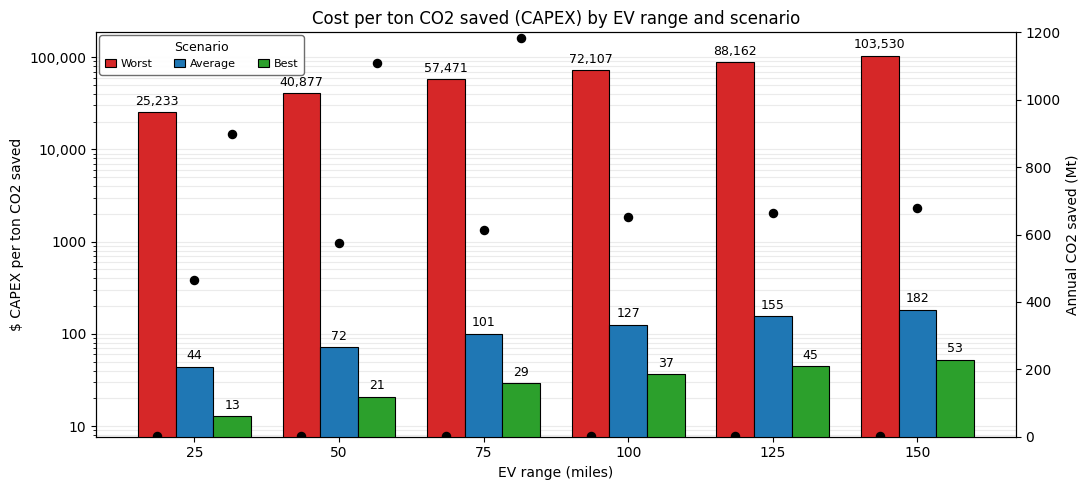

In [31]:
# ==== FIGURE 10 — CAPEX / ton CO2 Saved (bars, log-y) + CO2 Saved dots (secondary) ====
# Change from prior version: multiply CAPEX/kg by 1000 to plot CAPEX/ton.

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

EXCEL_PATH = "Calculations Check_final.xlsx"   # update if needed
SCENARIO_ORDER = ["Worst", "Average", "Best"]
RANGE_ORDER    = [25, 50, 75, 100, 125, 150]

# ---------------- helpers ----------------
def normalize_headers_inplace(df: pd.DataFrame) -> None:
    df.columns = (
        df.columns.astype(str)
        .str.replace("\n", " ", regex=False)
        .str.strip()
        .str.replace(r"\s+", " ", regex=True)
        .str.replace("co₂", "co2", case=False)
        .str.replace("$", "", regex=False)
    )

def find_header_row(path: str, sheet: str, max_scan: int = 250) -> int:
    raw = pd.read_excel(path, sheet_name=sheet, header=None, nrows=max_scan)
    patterns = [
        ("scenario",),
        ("vehicle", "type"),
        ("capex", "kg", "co2"),
        ("co2", "saved"),
    ]
    for i in range(min(max_scan, len(raw))):
        row = " ".join(map(str, raw.iloc[i].fillna("").tolist())).lower()
        score = sum(all(tok in row for tok in pats) for pats in patterns)
        if score >= 2:
            return i
    return 0

def pick_col(df: pd.DataFrame, *need_tokens, allow_any=False):
    toks = [t.lower() for t in need_tokens]
    for c in df.columns:
        s = str(c).lower()
        ok = all(t in s for t in toks) if not allow_any else any(t in s for t in toks)
        if ok:
            return c
    raise KeyError(f"Need column with tokens {need_tokens}. Available: {list(df.columns)}")

def try_pick(df: pd.DataFrame, *need_tokens, allow_any=False):
    try:
        return pick_col(df, *need_tokens, allow_any=allow_any)
    except KeyError:
        return None

def extract_range(s):
    m = re.search(r"(\d+)\s*(?:-?\s*mile|mi)\b", str(s), flags=re.IGNORECASE)
    return int(m.group(1)) if m else np.nan

def norm_scenario(s):
    s = str(s).strip().title()
    if s.startswith("Wor"):  return "Worst"
    if s.startswith("Mid") or s.startswith("Aver"): return "Average"
    if s.startswith("Bes"):  return "Best"
    return s

def looks_like_sheet4(df: pd.DataFrame) -> bool:
    cols = [c.lower() for c in df.columns]
    return (
        any("scenario" in c for c in cols) and
        any(("vehicle" in c and "type" in c) for c in cols) and
        any(("capex" in c and "kg" in c and "co2" in c) for c in cols)
    )

def looks_like_sheet3(df: pd.DataFrame) -> bool:
    cols = [c.lower() for c in df.columns]
    has_saved = any(("co2" in c and "saved" in c) for c in cols)
    return (
        has_saved and
        any("scenario" in c for c in cols) and
        any(("vehicle" in c and "type" in c) for c in cols)
    )

# ---------------- load workbook & pick sheets ----------------
xls = pd.ExcelFile(EXCEL_PATH)
sheet4_df = None
sheet3_df = None

preferred4 = next((n for n in xls.sheet_names if "scenario" in n.lower()), None)
if preferred4:
    hdr = find_header_row(EXCEL_PATH, preferred4)
    df_try = pd.read_excel(EXCEL_PATH, sheet_name=preferred4, header=hdr)
    normalize_headers_inplace(df_try)
    if looks_like_sheet4(df_try):
        sheet4_df = df_try

if sheet4_df is None:
    for n in xls.sheet_names:
        hdr = find_header_row(EXCEL_PATH, n)
        df_try = pd.read_excel(EXCEL_PATH, sheet_name=n, header=hdr)
        normalize_headers_inplace(df_try)
        if looks_like_sheet4(df_try):
            sheet4_df = df_try
            break

preferred3 = next((n for n in xls.sheet_names if "charge" in n.lower()), None)
if preferred3:
    hdr = find_header_row(EXCEL_PATH, preferred3)
    df_try = pd.read_excel(EXCEL_PATH, sheet_name=preferred3, header=hdr)
    normalize_headers_inplace(df_try)
    if looks_like_sheet3(df_try):
        sheet3_df = df_try

if sheet3_df is None:
    for n in xls.sheet_names:
        hdr = find_header_row(EXCEL_PATH, n)
        df_try = pd.read_excel(EXCEL_PATH, sheet_name=n, header=hdr)
        normalize_headers_inplace(df_try)
        if looks_like_sheet3(df_try):
            sheet3_df = df_try
            break

if sheet4_df is None or sheet3_df is None:
    raise RuntimeError("Could not locate required sheets with CAPEX/kg CO2 and CO2 Saved.")

# ---------------- bars: CAPEX / ton CO2 (converted from $/kg by ×1000) ----------------
c_scen4   = pick_col(sheet4_df, "scenario")
c_vtype4  = pick_col(sheet4_df, "vehicle", "type")
c_capexkg = try_pick(sheet4_df, "capex", "kg", "co2")
if c_capexkg is None:
    raise KeyError("Missing CAPEX/kg CO2 column in sheet4_df")

df4 = sheet4_df[[c_scen4, c_vtype4, c_capexkg]].dropna(subset=[c_vtype4]).copy()
df4["Scenario"]   = df4[c_scen4].map(norm_scenario)
df4["Range (mi)"] = df4[c_vtype4].map(extract_range).astype(float)

mask_ldv = sheet4_df[c_vtype4].astype(str).str.contains("LDV", case=False, na=False) & \
           sheet4_df[c_vtype4].astype(str).str.contains("EV range", case=False, na=False)
df4 = df4[mask_ldv.reindex(df4.index, fill_value=False)].copy()

# Pivot in $/kg, then convert to $/ton by ×1000
pivot_kg = (
    df4.pivot_table(index="Range (mi)", columns="Scenario", values=c_capexkg, aggfunc="first")
       .reindex(index=RANGE_ORDER, columns=SCENARIO_ORDER)
)
pivot_ton = pivot_kg.astype(float) * 1000.0  # <-- conversion

# ---------------- dots: Annual CO2 saved (Mt) ----------------
def pick_col_saved(df_like):
    return try_pick(df_like, "co2", "saved")

c_scen3  = pick_col(sheet3_df, "scen")
c_vtype3 = pick_col(sheet3_df, "vehicle", "type")
c_saved3 = pick_col_saved(sheet3_df)

piv_saved = None
if c_saved3 is not None:
    df3 = sheet3_df[[c_scen3, c_vtype3, c_saved3]].dropna(subset=[c_vtype3]).copy()
    df3["Scenario"]   = df3[c_scen3].map(norm_scenario)
    df3["Range (mi)"] = df3[c_vtype3].map(extract_range).astype(float)
    mask_ldv3 = sheet3_df[c_vtype3].astype(str).str.contains("LDV", case=False, na=False) & \
                sheet3_df[c_vtype3].astype(str).str.contains("EV range", case=False, na=False)
    df3 = df3[mask_ldv3.reindex(df3.index, fill_value=False)].copy()
    df3[c_saved3] = pd.to_numeric(df3[c_saved3], errors="coerce")
    piv_saved = (
        df3.pivot_table(index="Range (mi)", columns="Scenario", values=c_saved3, aggfunc="sum")
           .reindex(index=RANGE_ORDER, columns=SCENARIO_ORDER)
    )

# ---------------- plot ----------------
x = np.arange(len(RANGE_ORDER))
W = 0.26
offsets = [-W, 0, W]
colors = {"Worst": "#d62728", "Average": "#1f77b4", "Best": "#2ca02c"}

fig, ax = plt.subplots(figsize=(11, 5))
containers = []
for i, scen in enumerate(SCENARIO_ORDER):
    y = pivot_ton[scen].to_numpy(float)  # use $/ton values
    cont = ax.bar(x + offsets[i], y, width=W, color=colors[scen],
                  edgecolor="black", linewidth=0.8, label=scen, zorder=3)
    containers.append((cont, y))

# log-y for visibility
vals = pivot_ton.to_numpy(dtype=float)
if np.all(~np.isfinite(vals)):
    ax.set_ylim(1e-3, 1)
else:
    ymin = np.nanmin(vals)
    ymin = 1e-3 if not np.isfinite(ymin) or ymin <= 0 else max(1e-3, ymin*0.6)
    ymax = np.nanmax(vals)
    ymax = 1 if not np.isfinite(ymax) or ymax <= 0 else ymax*1.8
    ax.set_ylim(ymin, ymax)

ax.set_yscale("log")
# ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:g}"))
def _tick_fmt(v, _):
    if np.isfinite(v) and float(v).is_integer() and int(v) >= 10_000:
        return f"{int(v):,}"
    return f"{v:g}"

ax.yaxis.set_major_formatter(FuncFormatter(_tick_fmt))

upper = ax.get_ylim()[1]
# fmt = lambda v: (f"{v:.3f}" if v < 1 else (f"{v:.2f}" if v < 10 else f"{v:.0f}"))
def _fmt_barlabel(v: float) -> str:
    if not np.isfinite(v) or v <= 0:
        return ""
    if v < 1:
        return f"{v:.3f}"
    if v < 10:
        return f"{v:.2f}"
    iv = int(round(v))
    return f"{iv:,}" if iv >= 10_000 else f"{iv:d}"
pos = lambda v: min(v * 1.12, upper * 0.95)

for cont, y in containers:
    for rect, val in zip(cont, y):
        if np.isfinite(val) and val > 0:
            ax.annotate(
                _fmt_barlabel(val),
                xy=(rect.get_x() + rect.get_width()/2, pos(val)),
                xytext=(0, 0), textcoords="offset points",
                ha="center", va="bottom", fontsize=9, clip_on=False
            )

# secondary dots (Mt CO2 saved), fixed range 0–1200
if piv_saved is not None:
    ax2 = ax.twinx()
    for i, scen in enumerate(SCENARIO_ORDER):
        ydot = piv_saved[scen].to_numpy(float)
        ax2.scatter(x + offsets[i], ydot, s=34, color="black", zorder=4)
    ax2.set_ylabel("Annual CO2 saved (Mt)", color="black")
    ax2.tick_params(axis='y', colors="black")
    ax2.set_ylim(0, 1200)

# axes & legend
ax.set_xticks(x)
ax.set_xticklabels([str(r) for r in RANGE_ORDER])
ax.set_xlabel("EV range (miles)")
ax.set_ylabel("$ CAPEX per ton CO2 saved")  # <-- updated label
ax.set_title("Cost per ton CO2 saved (CAPEX) by EV range and scenario")
ax.grid(True, axis="y", which="both", alpha=0.25, zorder=0)

leg = ax.legend(
    title="Scenario",
    ncols=3,
    loc="upper left",
    frameon=True,
    fontsize=8,
    title_fontsize=9,
    handlelength=1.0,
    handletextpad=0.4,
    borderpad=0.25
)
frame = leg.get_frame()
frame.set_linewidth(1.0)
frame.set_edgecolor("#666")
frame.set_alpha(0.95)
try:
    frame.set_boxstyle("round,pad=0.25")
except Exception:
    pass

plt.tight_layout()
plt.show()


# FIGURE 11

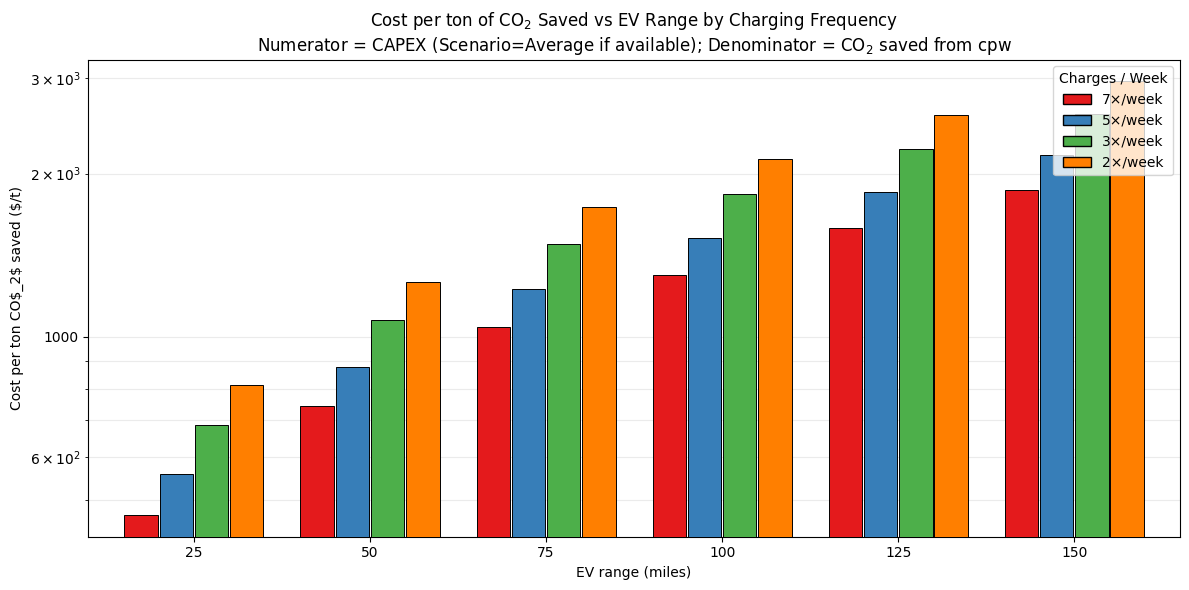


[CHECK] CAPEX map (range → $):
   25 mi → $2.058e+11
   50 mi → $4.117e+11
   75 mi → $6.175e+11
  100 mi → $8.233e+11
  125 mi → $1.029e+12
  150 mi → $1.235e+12

[CHECK] $/ton CO2 pivot (rows=cpw, cols=range):
range_mi     25       50       75       100      125      150
cpw                                                          
7         468.20   744.43  1041.47  1301.05  1588.34  1862.52
5         557.20   879.56  1224.63  1523.49  1852.50  2164.07
3         687.99  1074.63  1485.97  1837.67  2222.06  2582.13
2         815.62  1261.09  1732.43  2130.60  2562.91  2963.83

[CHECK] First rows of tidy table:
 cpw  range_mi  CO2_saved_ton   $/ton_CO2
   2      25.0   2.523651e+08  815.623898
   2      25.0            NaN         NaN
   3      25.0   2.991819e+08  687.992881
   3      25.0            NaN         NaN
   5      25.0   3.694070e+08  557.203768
   5      25.0            NaN         NaN
   7      25.0   4.396322e+08  468.198163
   7      25.0            NaN         NaN
  

In [23]:
# Cost per ton of CO2 saved vs EV range by charging frequency (from Excel)
# Numerator (CAPEX) is fixed w.r.t. cpw for each range (Scenario="Average" if available).
# Denominator is CO2 saved from the charge-frequency sheet (varies by cpw).

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.ticker import FuncFormatter

# ---------------- CONFIG ----------------
EXCEL_PATH = "Calculations Check_final.xlsx"
SHEET_SCEN = "Calcs by Scenario"   # optional; script will fall back if missing
SHEET_CPW  = "Calcs by Charge"     # required

RANGE_ORDER = [25, 50, 75, 100, 125, 150]
CPW_ORDER   = [7, 5, 3, 2]
SCEN_BASE   = "Average"

SAVE_PNG    = True
OUTFILE     = "cost_per_ton_vs_range_by_cpw.png"
LOG_Y       = True

# --- Palette (edit if you want different colors)
COLORS = {
    7: "#e41a1c",   # 7×/week – red
    5: "#377eb8",   # 5×/week – blue
    3: "#4daf4a",   # 3×/week – green
    2: "#ff7f00",   # 2×/week – orange
}

# ---------------- helpers ----------------
def normalize_headers_inplace(df: pd.DataFrame) -> None:
    df.columns = (df.columns.astype(str)
                  .str.replace("\n", " ")
                  .str.strip()
                  .str.replace(r"\s+", " ", regex=True))

def pick_col(df: pd.DataFrame, *need_tokens):
    """Pick first column whose lowercase header contains ALL tokens."""
    toks = [t.lower() for t in need_tokens]
    for c in df.columns:
        s = str(c).lower()
        if all(t in s for t in toks):
            return c
    raise KeyError(f"Need column with tokens {need_tokens}. Available: {list(df.columns)}")

def extract_range_mi(s: str) -> float:
    m = re.search(r'(\d+)\s*[- ]?\s*(?:mi|mile)', str(s), flags=re.IGNORECASE)
    return float(m.group(1)) if m else np.nan

def find_header_row(path: str, sheet: str, max_scan: int = 250) -> int:
    """Guess header row by scanning for likely token patterns."""
    raw = pd.read_excel(path, sheet_name=sheet, header=None, nrows=max_scan)
    patterns = [
        ("vehicle", "type"),
        ("charge", "freq"),
        ("co2", "saved"),
        ("scenario",),
    ]
    for i in range(min(max_scan, len(raw))):
        row = " ".join(map(str, raw.iloc[i].fillna("").tolist())).lower()
        if all(any(tok in row for tok in pats) for pats in [("vehicle", "type"),]):
            return i
        if any(all(tok in row for tok in pats) for pats in patterns):
            return i
    return 0

# ---------------- read CPW sheet (required) ----------------
hdr_cpw = find_header_row(EXCEL_PATH, SHEET_CPW)
df_cpw = pd.read_excel(EXCEL_PATH, sheet_name=SHEET_CPW, header=hdr_cpw)
normalize_headers_inplace(df_cpw)

col_cpw_vehicle = pick_col(df_cpw, "vehicle", "type")          # "Vehicle Type"
col_cpw_freq    = pick_col(df_cpw, "charge", "freq")           # "Charge Freq"
col_cpw_saved   = pick_col(df_cpw, "co2", "saved")             # "CO2 Saved (M t CO2)"

# Filter LDV EV-range rows and parse range & cpw
mask_ldv_cpw = df_cpw[col_cpw_vehicle].astype(str).str.contains("LDV", case=False, na=False) & \
               df_cpw[col_cpw_vehicle].astype(str).str.contains("EV range", case=False, na=False)
cpw_sub = df_cpw[mask_ldv_cpw].copy()
cpw_sub["range_mi"] = cpw_sub[col_cpw_vehicle].astype(str).map(extract_range_mi)

def parse_cpw(val):
    s = str(val).lower()
    if "before every trip" in s:   # ignore that row for this chart
        return None
    m = re.search(r'\d+', s)
    return int(m.group(0)) if m else None

cpw_sub["cpw"] = cpw_sub[col_cpw_freq].map(parse_cpw)
cpw_sub = cpw_sub.dropna(subset=["range_mi", "cpw"]).copy()
cpw_sub["cpw"] = cpw_sub["cpw"].astype(int)

# Convert CO2 saved to metric tons
cpw_sub["CO2_saved_ton"] = pd.to_numeric(cpw_sub[col_cpw_saved], errors="coerce") * 1e6

# ---------------- build numerator (CAPEX total $ per range) ----------------
capex_map = {}

# Try from Scenario sheet first
try:
    hdr_scen = find_header_row(EXCEL_PATH, SHEET_SCEN)
    df_scen = pd.read_excel(EXCEL_PATH, sheet_name=SHEET_SCEN, header=hdr_scen)
    normalize_headers_inplace(df_scen)

    col_scen_vehicle = pick_col(df_scen, "vehicle", "type")
    col_scen_scen    = pick_col(df_scen, "scenario")

    # prefer "$T Installed Battery" else Installed Battery (TWh)*Cost/kWh
    try:
        col_capex_T = pick_col(df_scen, "$t", "installed", "battery")
        col_inst_TWh = None
        col_cost_kwh = None
    except KeyError:
        col_capex_T = None
        col_inst_TWh = pick_col(df_scen, "installed", "battery", "twh")
        col_cost_kwh = pick_col(df_scen, "cost", "/", "kwh")

    mask_ldv_scen = df_scen[col_scen_vehicle].astype(str).str.contains("LDV", case=False, na=False) & \
                    df_scen[col_scen_vehicle].astype(str).str.contains("EV range", case=False, na=False)
    scen_sub = df_scen[mask_ldv_scen].copy()
    scen_sub["range_mi"] = scen_sub[col_scen_vehicle].astype(str).map(extract_range_mi)
    scen_sub["Scenario"] = (df_scen[col_scen_scen]
                            .astype(str).str.strip().str.title().str.replace("Mid", "Average", regex=False))

    scen_base = scen_sub[scen_sub["Scenario"].str.lower() == SCEN_BASE.lower()].copy()

    if col_capex_T is not None:
        scen_base["CAPEX_total_$"] = pd.to_numeric(scen_base[col_capex_T], errors="coerce") * 1e12
    else:
        inst = pd.to_numeric(scen_base[col_inst_TWh], errors="coerce")
        cost = pd.to_numeric(scen_base[col_cost_kwh], errors="coerce")
        scen_base["CAPEX_total_$"] = inst * 1e9 * cost

    capex_map = dict(zip(scen_base["range_mi"].astype(float), scen_base["CAPEX_total_$"].astype(float)))

except Exception:
    # Fallback: compute from cpw sheet (Installed Battery (TWh) & Cost/kWh),
    # then take median across cpw for each range (should be constant).
    col_inst_TWh_cpw = pick_col(df_cpw, "installed", "battery", "twh")
    col_cost_kwh_cpw = pick_col(df_cpw, "cost", "/", "kwh")

    tmp = df_cpw[mask_ldv_cpw].copy()
    tmp["range_mi"] = tmp[col_cpw_vehicle].astype(str).map(extract_range_mi)
    tmp["CAPEX_total_$"] = (
        pd.to_numeric(tmp[col_inst_TWh_cpw], errors="coerce") * 1e9 *
        pd.to_numeric(tmp[col_cost_kwh_cpw], errors="coerce")
    )
    capex_map = tmp.groupby("range_mi")["CAPEX_total_$"].median().to_dict()

# ---------------- compute $/ton ----------------
def cost_per_ton(row):
    capex = capex_map.get(float(row["range_mi"]), np.nan)
    saved = float(row["CO2_saved_ton"])
    return (capex / saved) if (np.isfinite(capex) and saved > 0) else np.nan

cpw_sub["$/ton_CO2"] = cpw_sub.apply(cost_per_ton, axis=1)

# Pivot to cpw × range
pivot = cpw_sub.pivot_table(index="cpw", columns="range_mi", values="$/ton_CO2", aggfunc="first")
pivot = pivot.reindex(index=[c for c in CPW_ORDER if c in pivot.index])
pivot = pivot.reindex(columns=[r for r in RANGE_ORDER if r in pivot.columns])

cpw_list = list(pivot.index)
ranges   = list(pivot.columns)

# ---------------- plot ----------------
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(ranges))

group_width = 0.8
bar_w = group_width / max(1, len(cpw_list))
offsets = (np.arange(len(cpw_list)) - (len(cpw_list)-1)/2.0) * bar_w

for k, cpw in enumerate(cpw_list):
    y = pivot.loc[cpw].to_numpy(float)
    pos = x + offsets[k]
    ax.bar(pos, y, width=bar_w*0.95,
           color=COLORS.get(cpw, "gray"),
           edgecolor="black", lw=0.7, zorder=3, label=f"{cpw}×/week")

if LOG_Y:
    ax.set_yscale("log")
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:g}"))

ax.set_xticks(x)
ax.set_xticklabels([f"{int(r)}" for r in ranges])
ax.set_xlim(-0.6, len(ranges)-0.4)
ax.set_xlabel("EV range (miles)")
ax.set_ylabel("Cost per ton CO$_2$ saved ($/t)")
ax.set_title("Cost per ton of CO$_2$ Saved vs EV Range by Charging Frequency\n"
             f"Numerator = CAPEX (Scenario={SCEN_BASE} if available); Denominator = CO$_2$ saved from cpw")
ax.grid(True, axis="y", which="both", alpha=0.25, zorder=0)

handles = [Patch(facecolor=COLORS.get(c, "gray"), edgecolor="black", label=f"{c}×/week")
           for c in CPW_ORDER if c in cpw_list]
ax.legend(handles=handles, loc="upper right", frameon=True, title="Charges / Week")

plt.tight_layout()
if SAVE_PNG:
    plt.savefig(OUTFILE, dpi=300)
plt.show()

# ---------------- checks ----------------
print("\n[CHECK] CAPEX map (range → $):")
for r in RANGE_ORDER:
    v = capex_map.get(float(r), np.nan)
    print(f"  {r:>3} mi → {('MISSING' if not np.isfinite(v) else f'${v:.3e}')}")

print("\n[CHECK] $/ton CO2 pivot (rows=cpw, cols=range):")
print(pivot.round(2))

tidy = (cpw_sub[["cpw", "range_mi", "CO2_saved_ton", "$/ton_CO2"]]
        .query("cpw in @cpw_list and range_mi in @ranges")
        .sort_values(["range_mi", "cpw"])
        .reset_index(drop=True))
print("\n[CHECK] First rows of tidy table:")
print(tidy.head(16).to_string(index=False))



## Updated FIGURE 11

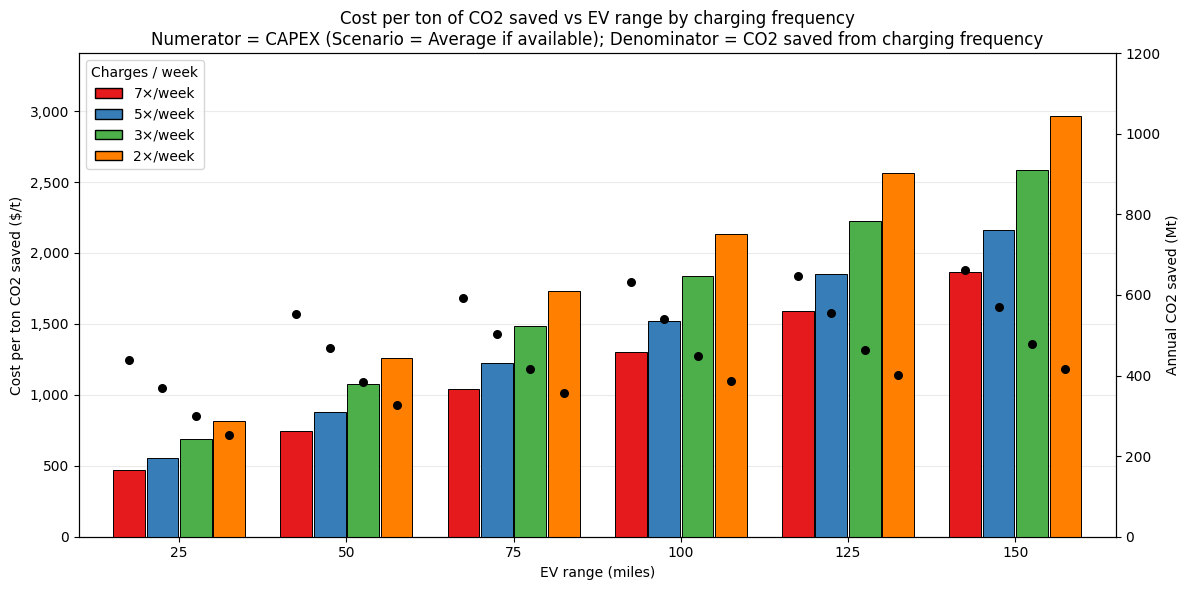

In [24]:
# ==== FIGURE 11 — Cost per ton of CO2 saved vs EV range by charging frequency ====
# Numerator = CAPEX (Scenario="Average" if available).
# Denominator = CO2 saved from "Calcs by Charge".
# Primary axis: $/ton CO2 saved (linear, raw numbers).
# Secondary axis: Annual CO2 saved (Mt) as dots, 0–1200 Mt.

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.ticker import FuncFormatter

EXCEL_PATH = "Calculations Check_final.xlsx"
SHEET_SCEN = "Calcs by Scenario"
SHEET_CPW  = "Calcs by Charge"

RANGE_ORDER = [25, 50, 75, 100, 125, 150]
CPW_ORDER   = [7, 5, 3, 2]
SCEN_BASE   = "Average"

SAVE_PNG    = True
OUTFILE     = "cost_per_ton_vs_range_by_cpw.png"

COLORS = {
    7: "#e41a1c",
    5: "#377eb8",
    3: "#4daf4a",
    2: "#ff7f00",
}

# ---------------- helpers ----------------
def normalize_headers_inplace(df: pd.DataFrame) -> None:
    df.columns = (df.columns.astype(str)
                  .str.replace("\n", " ")
                  .str.strip()
                  .str.replace(r"\s+", " ", regex=True))

def pick_col(df: pd.DataFrame, *need_tokens):
    toks = [t.lower() for t in need_tokens]
    for c in df.columns:
        s = str(c).lower()
        if all(t in s for t in toks):
            return c
    raise KeyError(f"Need column with tokens {need_tokens}. Available: {list(df.columns)}")

def extract_range_mi(s: str) -> float:
    m = re.search(r'(\d+)\s*[- ]?\s*(?:mi|mile)', str(s), flags=re.IGNORECASE)
    return float(m.group(1)) if m else np.nan

def find_header_row(path: str, sheet: str, max_scan: int = 250) -> int:
    raw = pd.read_excel(path, sheet_name=sheet, header=None, nrows=max_scan)
    for i in range(min(max_scan, len(raw))):
        row = " ".join(map(str, raw.iloc[i].fillna("").tolist())).lower()
        if "vehicle" in row and "type" in row:
            return i
    return 0

# ---------------- read CPW sheet (required) ----------------
hdr_cpw = find_header_row(EXCEL_PATH, SHEET_CPW)
df_cpw = pd.read_excel(EXCEL_PATH, sheet_name=SHEET_CPW, header=hdr_cpw)
normalize_headers_inplace(df_cpw)

col_cpw_vehicle = pick_col(df_cpw, "vehicle", "type")
col_cpw_freq    = pick_col(df_cpw, "charge", "freq")
col_cpw_saved   = pick_col(df_cpw, "co2", "saved")

mask_ldv_cpw = df_cpw[col_cpw_vehicle].astype(str).str.contains("LDV", case=False, na=False) & \
               df_cpw[col_cpw_vehicle].astype(str).str.contains("EV range", case=False, na=False)
cpw_sub = df_cpw[mask_ldv_cpw].copy()
cpw_sub["range_mi"] = cpw_sub[col_cpw_vehicle].astype(str).map(extract_range_mi)

def parse_cpw(val):
    s = str(val).lower()
    if "before every trip" in s:
        return None
    m = re.search(r'\d+', s)
    return int(m.group(0)) if m else None

cpw_sub["cpw"] = cpw_sub[col_cpw_freq].map(parse_cpw)
cpw_sub = cpw_sub.dropna(subset=["range_mi", "cpw"]).copy()
cpw_sub["cpw"] = cpw_sub["cpw"].astype(int)

# CO2 saved: convert to metric tons, also keep Mt for secondary axis
cpw_sub["CO2_saved_ton"] = pd.to_numeric(cpw_sub[col_cpw_saved], errors="coerce") * 1e6
cpw_sub["CO2_saved_Mt"]  = cpw_sub["CO2_saved_ton"] / 1e6

# ---------------- CAPEX total $ per range (numerator) ----------------
capex_map = {}

try:
    hdr_scen = find_header_row(EXCEL_PATH, SHEET_SCEN)
    df_scen = pd.read_excel(EXCEL_PATH, sheet_name=SHEET_SCEN, header=hdr_scen)
    normalize_headers_inplace(df_scen)

    col_scen_vehicle = pick_col(df_scen, "vehicle", "type")
    col_scen_scen    = pick_col(df_scen, "scenario")

    try:
        col_capex_T = pick_col(df_scen, "$t", "installed", "battery")
        col_inst_TWh = None
        col_cost_kwh = None
    except KeyError:
        col_capex_T = None
        col_inst_TWh = pick_col(df_scen, "installed", "battery", "twh")
        col_cost_kwh = pick_col(df_scen, "cost", "/", "kwh")

    mask_ldv_scen = df_scen[col_scen_vehicle].astype(str).str.contains("LDV", case=False, na=False) & \
                    df_scen[col_scen_vehicle].astype(str).str.contains("EV range", case=False, na=False)
    scen_sub = df_scen[mask_ldv_scen].copy()
    scen_sub["range_mi"] = scen_sub[col_scen_vehicle].astype(str).map(extract_range_mi)
    scen_sub["Scenario"] = (df_scen[col_scen_scen]
                            .astype(str).str.strip().str.title().str.replace("Mid", "Average", regex=False))

    scen_base = scen_sub[scen_sub["Scenario"].str.lower() == SCEN_BASE.lower()].copy()

    if col_capex_T is not None:
        scen_base["CAPEX_total_$"] = pd.to_numeric(scen_base[col_capex_T], errors="coerce") * 1e12
    else:
        inst = pd.to_numeric(scen_base[col_inst_TWh], errors="coerce")
        cost = pd.to_numeric(scen_base[col_cost_kwh], errors="coerce")
        scen_base["CAPEX_total_$"] = inst * 1e9 * cost

    capex_map = dict(zip(scen_base["range_mi"].astype(float), scen_base["CAPEX_total_$"].astype(float)))

except Exception:
    # fallback from CPW sheet
    col_inst_TWh_cpw = pick_col(df_cpw, "installed", "battery", "twh")
    col_cost_kwh_cpw = pick_col(df_cpw, "cost", "/", "kwh")

    tmp = df_cpw[mask_ldv_cpw].copy()
    tmp["range_mi"] = tmp[col_cpw_vehicle].astype(str).map(extract_range_mi)
    tmp["CAPEX_total_$"] = (
        pd.to_numeric(tmp[col_inst_TWh_cpw], errors="coerce") * 1e9 *
        pd.to_numeric(tmp[col_cost_kwh_cpw], errors="coerce")
    )
    capex_map = tmp.groupby("range_mi")["CAPEX_total_$"].median().to_dict()

# ---------------- $/ton CO2 ----------------
def cost_per_ton(row):
    capex = capex_map.get(float(row["range_mi"]), np.nan)
    saved = float(row["CO2_saved_ton"])
    return (capex / saved) if (np.isfinite(capex) and saved > 0) else np.nan

cpw_sub["$/ton_CO2"] = cpw_sub.apply(cost_per_ton, axis=1)

pivot_cost = cpw_sub.pivot_table(index="cpw", columns="range_mi", values="$/ton_CO2", aggfunc="first")
pivot_cost = pivot_cost.reindex(index=[c for c in CPW_ORDER if c in pivot_cost.index])
pivot_cost = pivot_cost.reindex(columns=[r for r in RANGE_ORDER if r in pivot_cost.columns])

pivot_saved_Mt = cpw_sub.pivot_table(index="cpw", columns="range_mi", values="CO2_saved_Mt", aggfunc="first")
pivot_saved_Mt = pivot_saved_Mt.reindex_like(pivot_cost)

cpw_list = list(pivot_cost.index)
ranges   = list(pivot_cost.columns)

# ---------------- plot ----------------
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(ranges))

group_width = 0.8
bar_w = group_width / max(1, len(cpw_list))
offsets = (np.arange(len(cpw_list)) - (len(cpw_list)-1)/2.0) * bar_w

for k, cpw in enumerate(cpw_list):
    y = pivot_cost.loc[cpw].to_numpy(float)
    pos = x + offsets[k]
    ax.bar(
        pos, y, width=bar_w*0.95,
        color=COLORS.get(cpw, "gray"),
        edgecolor="black", lw=0.7, zorder=3,
        label=f"{cpw}×/week"
    )

# primary y-axis: linear, raw numbers
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:,.0f}"))
ymax = np.nanmax(pivot_cost.to_numpy(dtype=float))
ax.set_ylim(0, ymax * 1.15)

ax.set_xticks(x)
ax.set_xticklabels([f"{int(r)}" for r in ranges])
ax.set_xlim(-0.6, len(ranges)-0.4)
ax.set_xlabel("EV range (miles)")
ax.set_ylabel("Cost per ton CO2 saved ($/t)")
ax.set_title(
    "Cost per ton of CO2 saved vs EV range by charging frequency\n"
    f"Numerator = CAPEX (Scenario = {SCEN_BASE} if available); "
    "Denominator = CO2 saved from charging frequency"
)
ax.grid(True, axis="y", which="both", alpha=0.25, zorder=0)

handles = [Patch(facecolor=COLORS.get(c, "gray"), edgecolor="black", label=f"{c}×/week")
           for c in CPW_ORDER if c in cpw_list]
ax.legend(handles=handles, loc="upper left", frameon=True, title="Charges / week")

# secondary axis: CO2 saved (Mt), dots, 0–1200
ax2 = ax.twinx()
for k, cpw in enumerate(cpw_list):
    ydot = pivot_saved_Mt.loc[cpw].to_numpy(float)
    pos = x + offsets[k]
    ax2.scatter(pos, ydot, s=30, color="black", zorder=4)
ax2.set_ylabel("Annual CO2 saved (Mt)")
ax2.set_ylim(0, 1200)

plt.tight_layout()
if SAVE_PNG:
    plt.savefig(OUTFILE, dpi=300)
plt.show()



## Updated FIGURE 11 - Part 2

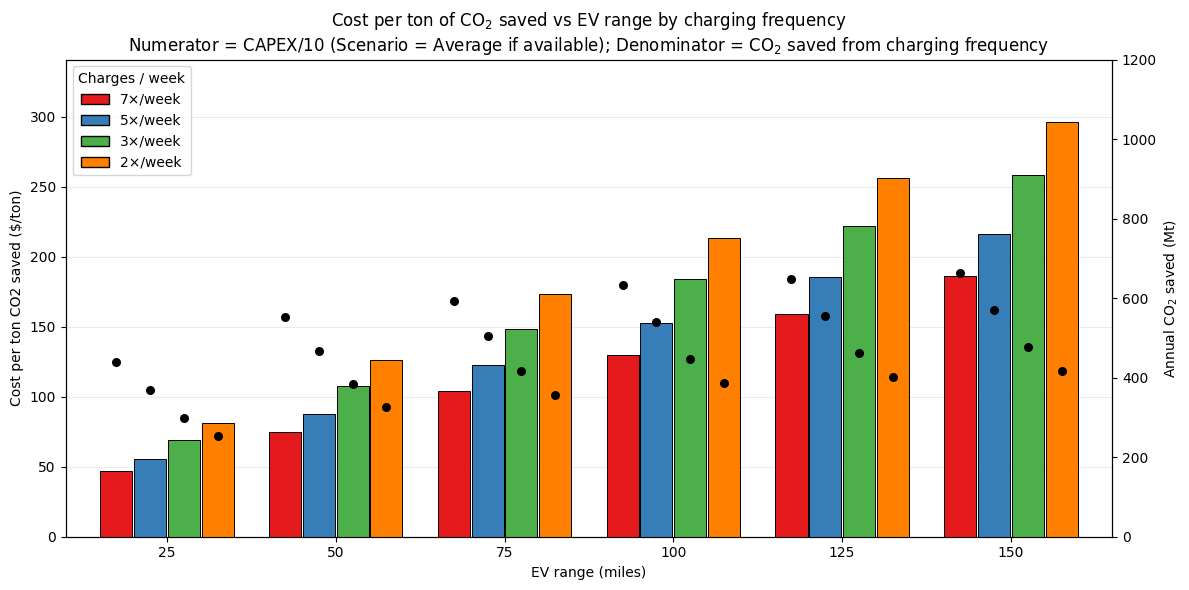

In [25]:
# ==== FIGURE 11 — Cost per ton of CO2 saved vs EV range by charging frequency ====
# Numerator = CAPEX/10 (Scenario="Average" if available).
# Denominator = CO2 saved from "Calcs by Charge".
# Primary axis: $/ton CO2 saved (linear, raw numbers).
# Secondary axis: Annual CO2 saved (Mt) as dots, 0–1200 Mt.

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.ticker import FuncFormatter

EXCEL_PATH = "Calculations Check_final.xlsx"
SHEET_SCEN = "Calcs by Scenario"
SHEET_CPW  = "Calcs by Charge"

RANGE_ORDER = [25, 50, 75, 100, 125, 150]
CPW_ORDER   = [7, 5, 3, 2]
SCEN_BASE   = "Average"

SAVE_PNG    = True
OUTFILE     = "cost_per_ton_vs_range_by_cpw.png"

COLORS = {
    7: "#e41a1c",
    5: "#377eb8",
    3: "#4daf4a",
    2: "#ff7f00",
}

# ---------------- helpers ----------------
def normalize_headers_inplace(df: pd.DataFrame) -> None:
    df.columns = (df.columns.astype(str)
                  .str.replace("\n", " ")
                  .str.strip()
                  .str.replace(r"\s+", " ", regex=True))

def pick_col(df: pd.DataFrame, *need_tokens):
    toks = [t.lower() for t in need_tokens]
    for c in df.columns:
        s = str(c).lower()
        if all(t in s for t in toks):
            return c
    raise KeyError(f"Need column with tokens {need_tokens}. Available: {list(df.columns)}")

def extract_range_mi(s: str) -> float:
    m = re.search(r'(\d+)\s*[- ]?\s*(?:mi|mile)', str(s), flags=re.IGNORECASE)
    return float(m.group(1)) if m else np.nan

def find_header_row(path: str, sheet: str, max_scan: int = 250) -> int:
    raw = pd.read_excel(path, sheet_name=sheet, header=None, nrows=max_scan)
    for i in range(min(max_scan, len(raw))):
        row = " ".join(map(str, raw.iloc[i].fillna("").tolist())).lower()
        if "vehicle" in row and "type" in row:
            return i
    return 0

# ---------------- read CPW sheet (required) ----------------
hdr_cpw = find_header_row(EXCEL_PATH, SHEET_CPW)
df_cpw = pd.read_excel(EXCEL_PATH, sheet_name=SHEET_CPW, header=hdr_cpw)
normalize_headers_inplace(df_cpw)

col_cpw_vehicle = pick_col(df_cpw, "vehicle", "type")
col_cpw_freq    = pick_col(df_cpw, "charge", "freq")
col_cpw_saved   = pick_col(df_cpw, "co2", "saved")

mask_ldv_cpw = df_cpw[col_cpw_vehicle].astype(str).str.contains("LDV", case=False, na=False) & \
               df_cpw[col_cpw_vehicle].astype(str).str.contains("EV range", case=False, na=False)
cpw_sub = df_cpw[mask_ldv_cpw].copy()
cpw_sub["range_mi"] = cpw_sub[col_cpw_vehicle].astype(str).map(extract_range_mi)

def parse_cpw(val):
    s = str(val).lower()
    if "before every trip" in s:
        return None
    m = re.search(r'\d+', s)
    return int(m.group(0)) if m else None

cpw_sub["cpw"] = cpw_sub[col_cpw_freq].map(parse_cpw)
cpw_sub = cpw_sub.dropna(subset=["range_mi", "cpw"]).copy()
cpw_sub["cpw"] = cpw_sub["cpw"].astype(int)

# CO2 saved: convert to metric tons, also keep Mt for secondary axis
cpw_sub["CO2_saved_ton"] = pd.to_numeric(cpw_sub[col_cpw_saved], errors="coerce") * 1e6
cpw_sub["CO2_saved_Mt"]  = cpw_sub["CO2_saved_ton"] / 1e6

# ---------------- CAPEX total $ per range (numerator) ----------------
capex_map = {}

try:
    hdr_scen = find_header_row(EXCEL_PATH, SHEET_SCEN)
    df_scen = pd.read_excel(EXCEL_PATH, sheet_name=SHEET_SCEN, header=hdr_scen)
    normalize_headers_inplace(df_scen)

    col_scen_vehicle = pick_col(df_scen, "vehicle", "type")
    col_scen_scen    = pick_col(df_scen, "scenario")

    try:
        col_capex_T = pick_col(df_scen, "$t", "installed", "battery")
        col_inst_TWh = None
        col_cost_kwh = None
    except KeyError:
        col_capex_T = None
        col_inst_TWh = pick_col(df_scen, "installed", "battery", "twh")
        col_cost_kwh = pick_col(df_scen, "cost", "/", "kwh")

    mask_ldv_scen = df_scen[col_scen_vehicle].astype(str).str.contains("LDV", case=False, na=False) & \
                    df_scen[col_scen_vehicle].astype(str).str.contains("EV range", case=False, na=False)
    scen_sub = df_scen[mask_ldv_scen].copy()
    scen_sub["range_mi"] = scen_sub[col_scen_vehicle].astype(str).map(extract_range_mi)
    scen_sub["Scenario"] = (df_scen[col_scen_scen]
                            .astype(str).str.strip().str.title().str.replace("Mid", "Average", regex=False))

    scen_base = scen_sub[scen_sub["Scenario"].str.lower() == SCEN_BASE.lower()].copy()

    if col_capex_T is not None:
        scen_base["CAPEX_total_$"] = pd.to_numeric(scen_base[col_capex_T], errors="coerce") * 1e12
    else:
        inst = pd.to_numeric(scen_base[col_inst_TWh], errors="coerce")
        cost = pd.to_numeric(scen_base[col_cost_kwh], errors="coerce")
        scen_base["CAPEX_total_$"] = inst * 1e9 * cost

    capex_map = dict(zip(scen_base["range_mi"].astype(float), scen_base["CAPEX_total_$"].astype(float)))

except Exception:
    col_inst_TWh_cpw = pick_col(df_cpw, "installed", "battery", "twh")
    col_cost_kwh_cpw = pick_col(df_cpw, "cost", "/", "kwh")

    tmp = df_cpw[mask_ldv_cpw].copy()
    tmp["range_mi"] = tmp[col_cpw_vehicle].astype(str).map(extract_range_mi)
    tmp["CAPEX_total_$"] = (
        pd.to_numeric(tmp[col_inst_TWh_cpw], errors="coerce") * 1e9 *
        pd.to_numeric(tmp[col_cost_kwh_cpw], errors="coerce")
    )
    capex_map = tmp.groupby("range_mi")["CAPEX_total_$"].median().to_dict()

# ---------------- $/ton CO2 (CAPEX spread over 10 years) ----------------
def cost_per_ton(row):
    capex = capex_map.get(float(row["range_mi"]), np.nan)
    saved = float(row["CO2_saved_ton"])
    # *** CHANGE: annualize CAPEX over 10 years ***
    capex_annualized = capex / 10.0 if np.isfinite(capex) else np.nan
    return (capex_annualized / saved) if (np.isfinite(capex_annualized) and saved > 0) else np.nan

cpw_sub["$/ton_CO2"] = cpw_sub.apply(cost_per_ton, axis=1)

pivot_cost = cpw_sub.pivot_table(index="cpw", columns="range_mi", values="$/ton_CO2", aggfunc="first")
pivot_cost = pivot_cost.reindex(index=[c for c in CPW_ORDER if c in pivot_cost.index])
pivot_cost = pivot_cost.reindex(columns=[r for r in RANGE_ORDER if r in pivot_cost.columns])

pivot_saved_Mt = cpw_sub.pivot_table(index="cpw", columns="range_mi", values="CO2_saved_Mt", aggfunc="first")
pivot_saved_Mt = pivot_saved_Mt.reindex_like(pivot_cost)

cpw_list = list(pivot_cost.index)
ranges   = list(pivot_cost.columns)

# ---------------- plot ----------------
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(ranges))

group_width = 0.8
bar_w = group_width / max(1, len(cpw_list))
offsets = (np.arange(len(cpw_list)) - (len(cpw_list)-1)/2.0) * bar_w

for k, cpw in enumerate(cpw_list):
    y = pivot_cost.loc[cpw].to_numpy(float)
    pos = x + offsets[k]
    ax.bar(
        pos, y, width=bar_w*0.95,
        color=COLORS.get(cpw, "gray"),
        edgecolor="black", lw=0.7, zorder=3,
        label=f"{cpw}×/week"
    )

ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:,.0f}"))
ymax = np.nanmax(pivot_cost.to_numpy(dtype=float))
ax.set_ylim(0, ymax * 1.15)

ax.set_xticks(x)
ax.set_xticklabels([f"{int(r)}" for r in ranges])
ax.set_xlim(-0.6, len(ranges)-0.4)
ax.set_xlabel("EV range (miles)")
ax.set_ylabel("Cost per ton CO2 saved ($/ton)")
ax.set_title(
    "Cost per ton of CO$_2$ saved vs EV range by charging frequency\n"
    f"Numerator = CAPEX/10 (Scenario = {SCEN_BASE} if available); "
    "Denominator = CO$_2$ saved from charging frequency"
)
ax.grid(True, axis="y", which="both", alpha=0.25, zorder=0)

handles = [Patch(facecolor=COLORS.get(c, "gray"), edgecolor="black", label=f"{c}×/week")
           for c in CPW_ORDER if c in cpw_list]
ax.legend(handles=handles, loc="upper left", frameon=True, title="Charges / week")

# secondary axis: CO2 saved (Mt), dots, 0–1200
ax2 = ax.twinx()
for k, cpw in enumerate(cpw_list):
    ydot = pivot_saved_Mt.loc[cpw].to_numpy(float)
    pos = x + offsets[k]
    ax2.scatter(pos, ydot, s=30, color="black", zorder=4)
ax2.set_ylabel("Annual CO$_2$ saved (Mt)")
ax2.set_ylim(0, 1200)

plt.tight_layout()
if SAVE_PNG:
    plt.savefig(OUTFILE, dpi=300)
plt.show()


# FIGURE 12

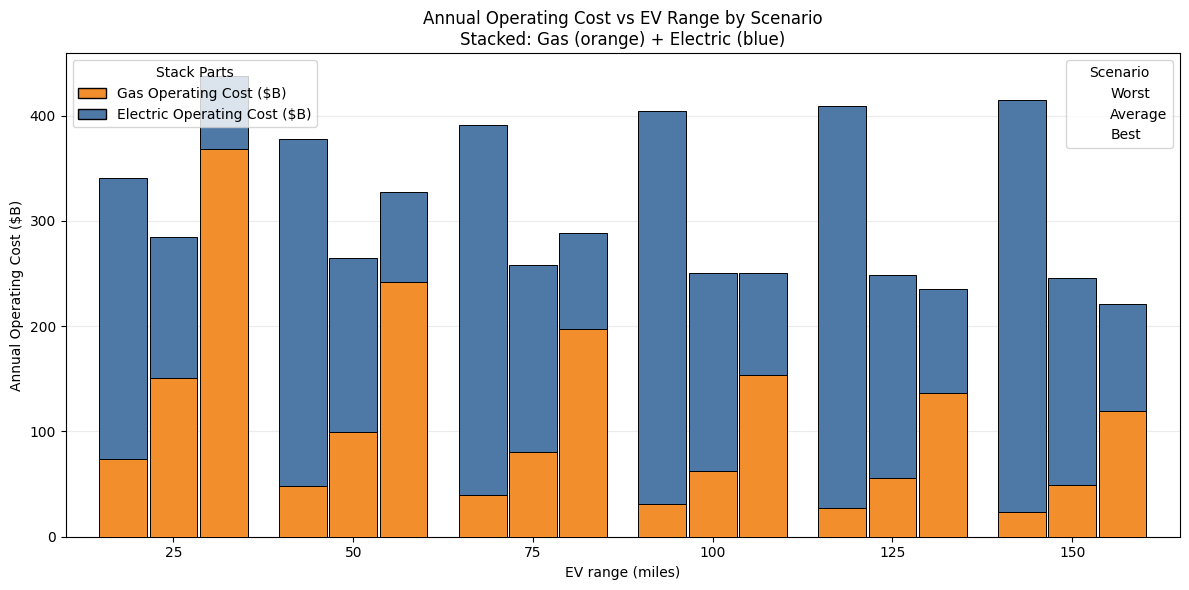


Tidy operating-cost table by Scenario (first 12 rows):
Scenario  Range (mi)   Gas_OC_B  Elec_OC_B
 Average        25.0 150.687584 134.496476
    Best        25.0 368.347428  69.169616
   Worst        25.0  73.669486 267.137829
 Average        50.0  99.060372 166.046440
    Best        50.0 242.147575  85.395312
   Worst        50.0  48.429515 329.802583
 Average        75.0  80.885445 177.153339
    Best        75.0 197.719978  91.107431
   Worst        75.0  39.543996 351.863183
 Average       100.0  62.710519 188.260238
    Best       100.0 153.292380  96.819551
   Worst       100.0  30.658476 373.923784


In [26]:
# Annual Operating Cost vs EV range by Scenario (from Excel)
# - Auto-detects the true header row inside "Calcs by Scenario"
# - Filters LDV (... EV range ...) rows
# - Groups by EV range; one stacked bar per Scenario (Worst, Average, Best)
# - Stacks: Gas OPEX ($ B OC Gas) + Electric OPEX ($B OC ELC)

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# ---------------- CONFIG ----------------
EXCEL_PATH = "Calculations Check_final.xlsx"   # change path if needed
SHEET_NAME = "Calcs by Scenario"
SCEN_ORDER = ["Worst", "Average", "Best"]      # bar order inside each range group
SAVE_PNG   = True
OUTFILE    = "annual_operating_cost_by_range_scenario.png"
SHOW_TOTAL = False                              # put total labels ($B) on bars

# ------------- helpers -------------
def normalize_headers_inplace(df: pd.DataFrame) -> None:
    df.columns = (
        df.columns.astype(str)
        .str.strip()
        .str.replace(r"\s+", " ", regex=True)
    )

def pick_col(df: pd.DataFrame, *need_tokens):
    """Pick first column whose lowercase header contains ALL tokens."""
    tokens = [t.lower() for t in need_tokens]
    for c in df.columns:
        s = str(c).lower()
        if all(tok in s for tok in tokens):
            return c
    raise KeyError(f"Need a column containing tokens {need_tokens}. Available: {list(df.columns)}")

def extract_range_mi(s: str) -> float:
    # Finds '25 mi', '25-mile', '25 mile', etc.
    m = re.search(r'(\d+)\s*[- ]?\s*(?:mi|mile)', str(s), flags=re.IGNORECASE)
    return float(m.group(1)) if m else np.nan

def find_header_row(excel_path: str, sheet: str, max_scan: int = 200) -> int:
    """Scan top rows to find the row that contains the real headers."""
    raw = pd.read_excel(excel_path, sheet_name=sheet, header=None, nrows=max_scan)
    for i in range(min(max_scan, len(raw))):
        row_str = " ".join(map(str, raw.iloc[i].fillna("").tolist())).lower()
        if all(k in row_str for k in ["scenario", "vehicle", "type", "gas vmt"]):
            return i
    # Fallback: first row
    return 0

# ------------- load with auto header -------------
hdr = find_header_row(EXCEL_PATH, SHEET_NAME)
df = pd.read_excel(EXCEL_PATH, sheet_name=SHEET_NAME, header=hdr)
normalize_headers_inplace(df)

# ------------- required columns (robust) -------------
col_vehicle_type = pick_col(df, "vehicle", "type")      # "Vehicle Type"
col_scenario     = pick_col(df, "scenario")             # "Scenario"
col_gas_cost     = pick_col(df, "oc", "gas")            # "$ B OC Gas"
col_elc_cost     = pick_col(df, "oc", "elc")            # "$B OC ELC"

# ------------- filter LDV EV-range rows -------------
mask_ldv = df[col_vehicle_type].astype(str).str.contains("LDV", case=False, na=False) & \
           df[col_vehicle_type].astype(str).str.contains("EV range", case=False, na=False)
sub = df[mask_ldv].copy()

# derive range (mi)
sub["range_mi"] = sub[col_vehicle_type].astype(str).map(extract_range_mi)
sub = sub.dropna(subset=["range_mi"])
sub["range_mi"] = sub["range_mi"].astype(float)

# keep only scenarios we care about (and present in data)
present_scenarios = [s for s in SCEN_ORDER
                     if s.lower() in set(map(str.lower, sub[col_scenario].dropna().unique()))]

# ------------- pivot per scenario -------------
# rows: scenario, cols: range
pivot_gas = sub.pivot_table(index=col_scenario, columns="range_mi", values=col_gas_cost, aggfunc="first")
pivot_elc = sub.pivot_table(index=col_scenario, columns="range_mi", values=col_elc_cost, aggfunc="first")

# sort ranges ascending and align
pivot_gas = pivot_gas.sort_index(axis=1)
pivot_elc = pivot_elc.reindex_like(pivot_gas)

ranges = pivot_gas.columns.to_numpy(float)   # e.g., [25., 50., 75., 100., 125., 150.]

# ------------- plot -------------
GAS_COLOR = "#f28e2b"   # orange
ELC_COLOR = "#4e79a7"   # blue

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(ranges))

group_width = 0.84
bar_w = group_width / max(1, len(present_scenarios))
offsets = (np.arange(len(present_scenarios)) - (len(present_scenarios)-1)/2.0) * bar_w

for k_pos, scen in enumerate(present_scenarios):
    # find exact index label in pivot (case-insensitive)
    match_idx = [idx for idx in pivot_gas.index if str(idx).lower() == scen.lower()]
    if not match_idx:
        continue
    idx = match_idx[0]

    gas_cost = pivot_gas.loc[idx].to_numpy(float)
    elc_cost = pivot_elc.loc[idx].to_numpy(float)
    pos = x + offsets[k_pos]

    bars_g = ax.bar(
        pos, gas_cost,
        width=bar_w*0.95,
        color=GAS_COLOR,
        edgecolor="black", lw=0.7, zorder=3
    )
    bars_e = ax.bar(
        pos, elc_cost,
        width=bar_w*0.95, bottom=gas_cost,
        color=ELC_COLOR,
        edgecolor="black", lw=0.7, zorder=3
    )

    if SHOW_TOTAL:
        totals = gas_cost + elc_cost
        for p, tot in zip(bars_e, totals):
            ax.text(p.get_x() + p.get_width()/2.0,
                    p.get_y() + p.get_height() + 2.0,
                    f"{tot:.0f}", ha="center", va="bottom", fontsize=9)

# axes / labels / grid
ax.set_xticks(x)
ax.set_xticklabels([f"{int(r)}" for r in ranges])
ax.set_xlim(-0.6, len(ranges)-0.4)
ax.set_ylabel("Annual Operating Cost ($B)")
ax.set_xlabel("EV range (miles)")
ax.grid(True, axis="y", alpha=0.25, zorder=0)
ax.set_title("Annual Operating Cost vs EV Range by Scenario\nStacked: Gas (orange) + Electric (blue)")

# legends
stack_leg = ax.legend(
    handles=[
        Patch(facecolor=GAS_COLOR, edgecolor="black", label="Gas Operating Cost ($B)"),
        Patch(facecolor=ELC_COLOR, edgecolor="black", label="Electric Operating Cost ($B)"),
    ],
    loc="upper left", frameon=True, title="Stack Parts"
)
ax.add_artist(stack_leg)

scen_labels = [f"{s}" for s in present_scenarios]
ax.legend([Line2D([0],[0], lw=0)] * len(scen_labels),
          scen_labels, loc="upper right", frameon=True, title="Scenario")

plt.tight_layout()
if SAVE_PNG:
    plt.savefig(OUTFILE, dpi=300)
plt.show()

# ---- optional: tidy table print
tidy = (
    sub[[col_scenario, "range_mi", col_gas_cost, col_elc_cost]]
    .rename(columns={col_scenario:"Scenario", "range_mi":"Range (mi)",
                     col_gas_cost:"Gas_OC_B", col_elc_cost:"Elec_OC_B"})
    .sort_values(["Range (mi)", "Scenario"])
    .reset_index(drop=True)
)
print("\nTidy operating-cost table by Scenario (first 12 rows):")
print(tidy.head(12).to_string(index=False))



## Updated FIGURE 12

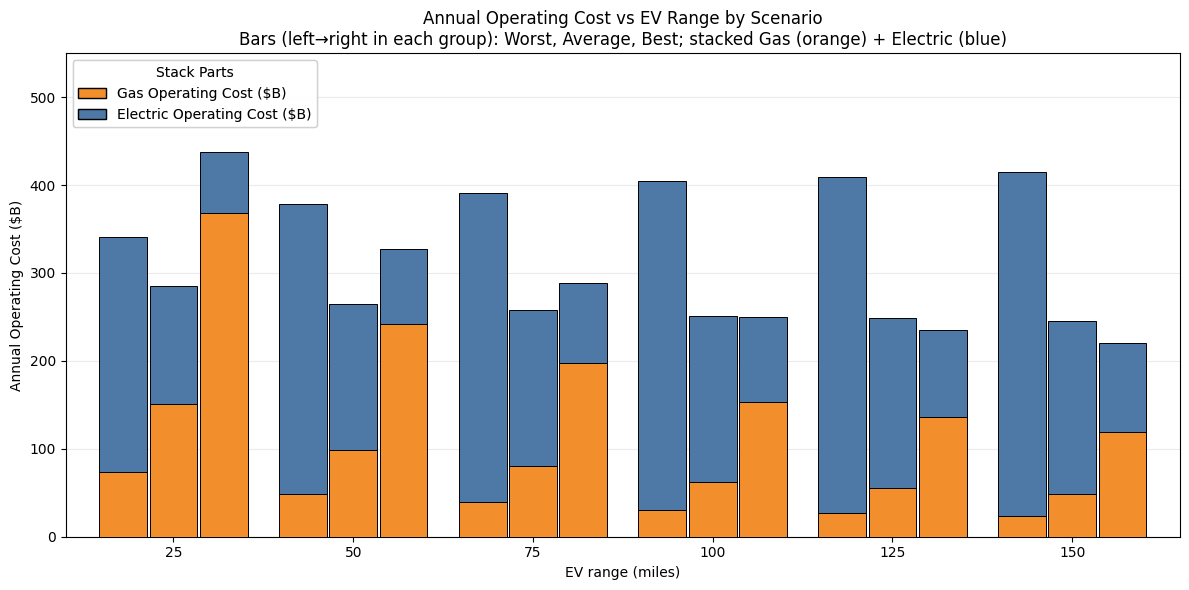

In [27]:
# ====================== FIGURE 12 ======================
# Annual Operating Cost vs EV range by Scenario
# Bars (left→right in each group): Worst, Average, Best;
# stacked Gas (orange) + Electric (blue)

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# ---------------- CONFIG ----------------
EXCEL_PATH = "Calculations Check_final.xlsx"   # change path if needed
SHEET_NAME = "Calcs by Scenario"
SCEN_ORDER = ["Worst", "Average", "Best"]      # bar order inside each range group
SAVE_PNG   = True
OUTFILE    = "annual_operating_cost_by_range_scenario.png"
SHOW_TOTAL = False                              # put total labels ($B) on bars

# ------------- helpers -------------
def normalize_headers_inplace(df: pd.DataFrame) -> None:
    df.columns = (
        df.columns.astype(str)
        .str.strip()
        .str.replace(r"\s+", " ", regex=True)
    )

def pick_col(df: pd.DataFrame, *need_tokens):
    tokens = [t.lower() for t in need_tokens]
    for c in df.columns:
        s = str(c).lower()
        if all(tok in s for tok in tokens):
            return c
    raise KeyError(f"Need a column containing tokens {need_tokens}. Available: {list(df.columns)}")

def extract_range_mi(s: str) -> float:
    m = re.search(r'(\d+)\s*[- ]?\s*(?:mi|mile)', str(s), flags=re.IGNORECASE)
    return float(m.group(1)) if m else np.nan

def find_header_row(excel_path: str, sheet: str, max_scan: int = 200) -> int:
    raw = pd.read_excel(excel_path, sheet_name=sheet, header=None, nrows=max_scan)
    for i in range(min(max_scan, len(raw))):
        row_str = " ".join(map(str, raw.iloc[i].fillna("").tolist())).lower()
        if all(k in row_str for k in ["scenario", "vehicle", "type", "gas vmt"]):
            return i
    return 0

# ------------- load with auto header -------------
hdr = find_header_row(EXCEL_PATH, SHEET_NAME)
df = pd.read_excel(EXCEL_PATH, sheet_name=SHEET_NAME, header=hdr)
normalize_headers_inplace(df)

# ------------- required columns (robust) -------------
col_vehicle_type = pick_col(df, "vehicle", "type")      # "Vehicle Type"
col_scenario     = pick_col(df, "scenario")             # "Scenario"
col_gas_cost     = pick_col(df, "oc", "gas")            # "$ B OC Gas"
col_elc_cost     = pick_col(df, "oc", "elc")            # "$B OC ELC"

# ------------- filter LDV EV-range rows -------------
mask_ldv = df[col_vehicle_type].astype(str).str.contains("LDV", case=False, na=False) & \
           df[col_vehicle_type].astype(str).str.contains("EV range", case=False, na=False)
sub = df[mask_ldv].copy()

sub["range_mi"] = sub[col_vehicle_type].astype(str).map(extract_range_mi)
sub = sub.dropna(subset=["range_mi"])
sub["range_mi"] = sub["range_mi"].astype(float)

present_scenarios = [s for s in SCEN_ORDER
                     if s.lower() in set(map(str.lower, sub[col_scenario].dropna().unique()))]

# ------------- pivot per scenario -------------
pivot_gas = sub.pivot_table(index=col_scenario, columns="range_mi", values=col_gas_cost, aggfunc="first")
pivot_elc = sub.pivot_table(index=col_scenario, columns="range_mi", values=col_elc_cost, aggfunc="first")

pivot_gas = pivot_gas.sort_index(axis=1)
pivot_elc = pivot_elc.reindex_like(pivot_gas)

ranges = pivot_gas.columns.to_numpy(float)

# ------------- plot -------------
GAS_COLOR = "#f28e2b"
ELC_COLOR = "#4e79a7"

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(ranges))

group_width = 0.84
bar_w = group_width / max(1, len(present_scenarios))
offsets = (np.arange(len(present_scenarios)) - (len(present_scenarios)-1)/2.0) * bar_w

for k_pos, scen in enumerate(present_scenarios):
    match_idx = [idx for idx in pivot_gas.index if str(idx).lower() == scen.lower()]
    if not match_idx:
        continue
    idx = match_idx[0]

    gas_cost = pivot_gas.loc[idx].to_numpy(float)
    elc_cost = pivot_elc.loc[idx].to_numpy(float)
    pos = x + offsets[k_pos]

    bars_g = ax.bar(
        pos, gas_cost,
        width=bar_w * 0.95,
        color=GAS_COLOR,
        edgecolor="black", lw=0.7, zorder=3
    )
    bars_e = ax.bar(
        pos, elc_cost,
        width=bar_w * 0.95, bottom=gas_cost,
        color=ELC_COLOR,
        edgecolor="black", lw=0.7, zorder=3
    )

    if SHOW_TOTAL:
        totals = gas_cost + elc_cost
        for p, tot in zip(bars_e, totals):
            ax.text(p.get_x() + p.get_width()/2.0,
                    p.get_y() + p.get_height() + 2.0,
                    f"{tot:.0f}", ha="center", va="bottom", fontsize=9)

# axes / labels / grid / y-limit
ax.set_xticks(x)
ax.set_xticklabels([f"{int(r)}" for r in ranges])
ax.set_xlim(-0.6, len(ranges) - 0.4)
ax.set_ylabel("Annual Operating Cost ($B)")
ax.set_xlabel("EV range (miles)")
ax.grid(True, axis="y", alpha=0.25, zorder=0)
ax.set_ylim(0, 550)   # <<< fixed y-axis 0–400 for Figure 12

ax.set_title(
    "Annual Operating Cost vs EV Range by Scenario\n"
    "Bars (left→right in each group): Worst, Average, Best; "
    "stacked Gas (orange) + Electric (blue)"
)

# Only legend for stack parts (no scenario legend)
stack_leg = ax.legend(
    handles=[
        Patch(facecolor=GAS_COLOR, edgecolor="black", label="Gas Operating Cost ($B)"),
        Patch(facecolor=ELC_COLOR, edgecolor="black", label="Electric Operating Cost ($B)"),
    ],
    loc="upper left", frameon=True, title="Stack Parts"
)
ax.add_artist(stack_leg)

plt.tight_layout()
if SAVE_PNG:
    plt.savefig(OUTFILE, dpi=300)
plt.show()



# FIGURE 13

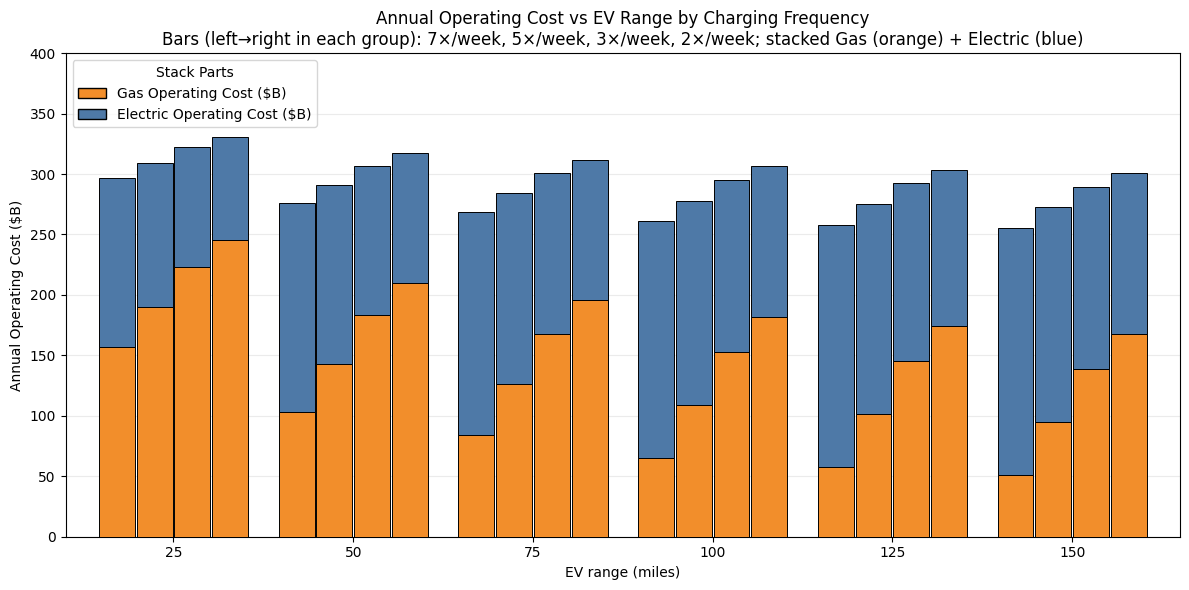

In [28]:
# === FIGURE 13: Annual Operating Cost vs EV range by Charging Frequency ===
# (Bars left→right: 7×/week, 5×/week, 3×/week, 2×/week; stacked Gas + Electric)

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

EXCEL_PATH = "Calculations Check_final.xlsx"   # adjust if needed
SHEET_NAME = "Calcs by Charge"
DESIRED_CPW = [7, 5, 3, 2]
SAVE_PNG = True
OUTFILE = "annual_operating_cost_by_range_cpw.png"
SHOW_TOTAL_LABELS = False

def normalize_headers_inplace(df: pd.DataFrame) -> None:
    df.columns = (
        df.columns.astype(str)
        .str.strip()
        .str.replace(r"\s+", " ", regex=True)
    )

def pick_col(df: pd.DataFrame, *need_tokens):
    tokens = [t.lower() for t in need_tokens]
    for c in df.columns:
        s = str(c).lower()
        if all(tok in s for tok in tokens):
            return c
    raise KeyError(f"Need a column containing tokens {need_tokens}. Available: {list(df.columns)}")

def extract_range_mi(s: str) -> float:
    m = re.search(r'(\d+)\s*[- ]?\s*(?:mi|mile)', str(s), flags=re.IGNORECASE)
    return float(m.group(1)) if m else np.nan

def parse_cpw(val) -> int | None:
    if isinstance(val, str) and "before every trip" in val.lower():
        return None
    m = re.search(r'\d+', str(val))
    return int(m.group(0)) if m else None

df = pd.read_excel(EXCEL_PATH, sheet_name=SHEET_NAME)
normalize_headers_inplace(df)

col_vehicle_type = pick_col(df, "vehicle", "type")
col_charge_freq  = pick_col(df, "charge", "freq")
col_gas_cost     = pick_col(df, "oc", "gas")
col_elc_cost     = pick_col(df, "oc", "elc")

mask_ldv = df[col_vehicle_type].astype(str).str.contains("LDV", case=False, na=False) & \
           df[col_vehicle_type].astype(str).str.contains("EV range", case=False, na=False)
sub = df[mask_ldv].copy()

sub["range_mi"] = sub[col_vehicle_type].astype(str).map(extract_range_mi)
sub["cpw"]      = sub[col_charge_freq].map(parse_cpw)

sub = sub.dropna(subset=["range_mi"])
sub = sub.dropna(subset=["cpw"])
sub["cpw"] = sub["cpw"].astype(int)
sub = sub[sub["cpw"].isin(DESIRED_CPW)]

pivot_gas = sub.pivot_table(index="cpw", columns="range_mi", values=col_gas_cost, aggfunc="first")
pivot_elc = sub.pivot_table(index="cpw", columns="range_mi", values=col_elc_cost, aggfunc="first")

pivot_gas = pivot_gas.sort_index().sort_index(axis=1)
pivot_elc = pivot_elc.reindex_like(pivot_gas)

cpw_list  = pivot_gas.index.to_numpy(int)
ranges    = pivot_gas.columns.to_numpy(float)
gas_cost  = pivot_gas.to_numpy(float)
elc_cost  = pivot_elc.to_numpy(float)

GAS_COLOR = "#f28e2b"
ELC_COLOR = "#4e79a7"

plt.close("all")
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(ranges))

group_width = 0.84
present_cpw = [cpw for cpw in DESIRED_CPW if cpw in cpw_list]
bar_w = group_width / len(present_cpw)
offsets = (np.arange(len(present_cpw)) - (len(present_cpw)-1)/2.0) * bar_w

for k_pos, cpw in enumerate(present_cpw):
    idx = int(np.where(cpw_list == cpw)[0][0])
    pos = x + offsets[k_pos]

    bars_g = ax.bar(pos, gas_cost[idx],
                    width=bar_w*0.95, color=GAS_COLOR,
                    edgecolor="black", lw=0.7, zorder=3)
    bars_e = ax.bar(pos, elc_cost[idx],
                    width=bar_w*0.95, bottom=gas_cost[idx],
                    color=ELC_COLOR, edgecolor="black",
                    lw=0.7, zorder=3)

    if SHOW_TOTAL_LABELS:
        totals = gas_cost[idx] + elc_cost[idx]
        for p, tot in zip(bars_e, totals):
            ax.text(p.get_x() + p.get_width()/2.0,
                    p.get_y() + p.get_height() + 2.0,
                    f"{tot:.0f}", ha="center", va="bottom", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels([f"{int(r)}" for r in ranges])
ax.set_xlim(-0.6, len(ranges)-0.4)
ax.set_ylabel("Annual Operating Cost ($B)")
ax.set_xlabel("EV range (miles)")
ax.grid(True, axis="y", alpha=0.25, zorder=0)

# same y-axis as Figure 12
ax.set_ylim(0, 400)

# Title with bar order + stack info; no extra subtitle
ax.set_title(
    "Annual Operating Cost vs EV Range by Charging Frequency\n"
    "Bars (left→right in each group): 7×/week, 5×/week, 3×/week, 2×/week; "
    "stacked Gas (orange) + Electric (blue)"
)

# Only legend = stack parts (Gas vs Electric)
stack_leg = ax.legend(
    handles=[
        Patch(facecolor=GAS_COLOR, edgecolor="black", label="Gas Operating Cost ($B)"),
        Patch(facecolor=ELC_COLOR, edgecolor="black", label="Electric Operating Cost ($B)"),
    ],
    loc="upper left", frameon=True, title="Stack Parts"
)

plt.tight_layout()
if SAVE_PNG:
    plt.savefig(OUTFILE, dpi=300)
plt.show()


## Updated FIGURE 13

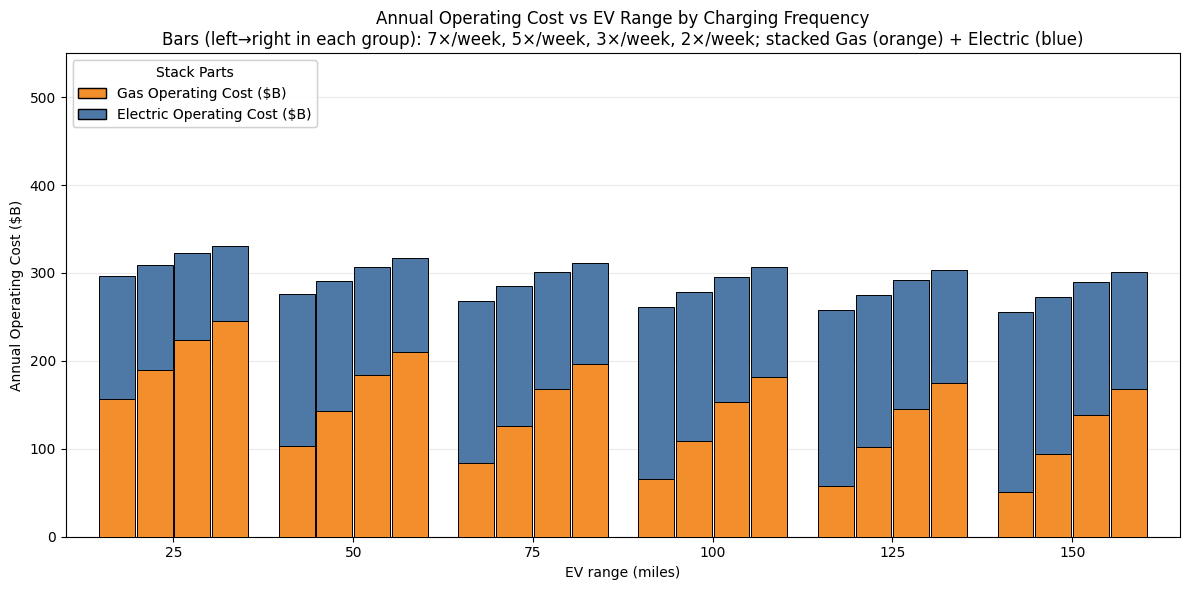

In [29]:
# ====================== FIGURE 13 ======================
# Annual Operating Cost vs EV range by Charging Frequency
# Bars (left→right in each group): 7×/week, 5×/week, 3×/week, 2×/week;
# stacked Gas (orange) + Electric (blue)

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# ------------- CONFIG -------------
EXCEL_PATH = "Calculations Check_final.xlsx"   # adjust if needed
SHEET_NAME = "Calcs by Charge"
DESIRED_CPW = [7, 5, 3, 2]
SAVE_PNG = True
OUTFILE = "annual_operating_cost_by_range_cpw.png"
SHOW_TOTAL_LABELS = False

# ------------- HELPERS -------------
def normalize_headers_inplace(df: pd.DataFrame) -> None:
    df.columns = (
        df.columns.astype(str)
        .str.strip()
        .str.replace(r"\s+", " ", regex=True)
    )

def pick_col(df: pd.DataFrame, *need_tokens):
    tokens = [t.lower() for t in need_tokens]
    for c in df.columns:
        s = str(c).lower()
        if all(tok in s for tok in tokens):
            return c
    raise KeyError(f"Need a column containing tokens {need_tokens}. Available: {list(df.columns)}")

def extract_range_mi(s: str) -> float:
    m = re.search(r'(\d+)\s*[- ]?\s*(?:mi|mile)', str(s), flags=re.IGNORECASE)
    return float(m.group(1)) if m else np.nan

def parse_cpw(val) -> int | None:
    if isinstance(val, str) and "before every trip" in val.lower():
        return None
    m = re.search(r'\d+', str(val))
    return int(m.group(0)) if m else None

# ------------- LOAD -------------
df = pd.read_excel(EXCEL_PATH, sheet_name=SHEET_NAME)
normalize_headers_inplace(df)

col_vehicle_type = pick_col(df, "vehicle", "type")
col_charge_freq  = pick_col(df, "charge", "freq")
col_gas_cost     = pick_col(df, "oc", "gas")
col_elc_cost     = pick_col(df, "oc", "elc")

mask_ldv = df[col_vehicle_type].astype(str).str.contains("LDV", case=False, na=False) & \
           df[col_vehicle_type].astype(str).str.contains("EV range", case=False, na=False)
sub = df[mask_ldv].copy()

sub["range_mi"] = sub[col_vehicle_type].astype(str).map(extract_range_mi)
sub["cpw"]      = sub[col_charge_freq].map(parse_cpw)

sub = sub.dropna(subset=["range_mi", "cpw"])
sub["cpw"] = sub["cpw"].astype(int)
sub = sub[sub["cpw"].isin(DESIRED_CPW)]

pivot_gas = sub.pivot_table(index="cpw", columns="range_mi", values=col_gas_cost, aggfunc="first")
pivot_elc = sub.pivot_table(index="cpw", columns="range_mi", values=col_elc_cost, aggfunc="first")

pivot_gas = pivot_gas.sort_index().sort_index(axis=1)
pivot_elc = pivot_elc.reindex_like(pivot_gas)

cpw_list  = pivot_gas.index.to_numpy(int)
ranges    = pivot_gas.columns.to_numpy(float)
gas_cost  = pivot_gas.to_numpy(float)
elc_cost  = pivot_elc.to_numpy(float)

# ------------- PLOT -------------
GAS_COLOR = "#f28e2b"
ELC_COLOR = "#4e79a7"

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(ranges))

present_cpw = [cpw for cpw in DESIRED_CPW if cpw in cpw_list]
group_width = 0.84
bar_w = group_width / len(present_cpw)
offsets = (np.arange(len(present_cpw)) - (len(present_cpw)-1)/2.0) * bar_w

for k_pos, cpw in enumerate(present_cpw):
    idx = int(np.where(cpw_list == cpw)[0][0])
    pos = x + offsets[k_pos]

    bars_g = ax.bar(
        pos, gas_cost[idx],
        width=bar_w * 0.95,
        color=GAS_COLOR,
        edgecolor="black", lw=0.7, zorder=3
    )

    bars_e = ax.bar(
        pos, elc_cost[idx],
        width=bar_w * 0.95,
        bottom=gas_cost[idx],
        color=ELC_COLOR,
        edgecolor="black", lw=0.7, zorder=3
    )

    if SHOW_TOTAL_LABELS:
        totals = gas_cost[idx] + elc_cost[idx]
        for p, tot in zip(bars_e, totals):
            ax.text(
                p.get_x() + p.get_width()/2.0,
                p.get_y() + p.get_height() + 2.0,
                f"{tot:.0f}", ha="center", va="bottom", fontsize=9
            )

ax.set_xticks(x)
ax.set_xticklabels([f"{int(r)}" for r in ranges])
ax.set_xlim(-0.6, len(ranges) - 0.4)
ax.set_ylabel("Annual Operating Cost ($B)")
ax.set_xlabel("EV range (miles)")
ax.grid(True, axis="y", alpha=0.25, zorder=0)
ax.set_ylim(0, 550)   # <<< SAME y-axis as Figure 12

ax.set_title(
    "Annual Operating Cost vs EV Range by Charging Frequency\n"
    "Bars (left→right in each group): 7×/week, 5×/week, 3×/week, 2×/week; "
    "stacked Gas (orange) + Electric (blue)"
)

# Only legend for stack parts (no separate CPW legend)
stack_leg = ax.legend(
    handles=[
        Patch(facecolor=GAS_COLOR, edgecolor="black", label="Gas Operating Cost ($B)"),
        Patch(facecolor=ELC_COLOR, edgecolor="black", label="Electric Operating Cost ($B)"),
    ],
    loc="upper left", frameon=True, title="Stack Parts"
)
ax.add_artist(stack_leg)

plt.tight_layout()
if SAVE_PNG:
    plt.savefig(OUTFILE, dpi=300)
plt.show()

